# Notebook 06 -- Visualizaciones para la Memoria del TFG


**TFG:** Deteccion de Anomalias de Consumo Electrico y Mitigacion de Ataques FDI en Edge Computing


---


Este notebook genera las **figuras finales** para la memoria:


1. **Timeline plots** con delimitadores train/val/test y predicciones de cada modelo

2. **Grid de episodios** por tipo de ataque (7 tipos x mejor modelo)

3. **Tabla comparativa** consolidada de los 4 modelos


### Requisitos


Ejecutar previamente NB03, NB03b, NB04 y NB05 para que existan los archivos:


| Notebook | Archivo de predicciones | Archivo de metricas |

|---|---|---|

| NB03 | `predictions_isolation_forest.csv` | `metrics_isolation_forest.json` |

| NB03b | `predictions_kmeans_if.csv` | `metrics_kmeans_if.json` |

| NB04 | `predictions_dense_autoencoder.csv` | `metrics_dense_autoencoder.json` |

| NB05 | `predictions_lstm_autoencoder.csv` | `metrics_lstm_autoencoder.json` |

## 0. Setup

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.dates as mdates

import matplotlib.patches as mpatches

from matplotlib.colors import ListedColormap

import seaborn as sns

import json, os, warnings


warnings.filterwarnings('ignore')

np.random.seed(42)


# Estilo coherente para toda la memoria

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({

    'figure.figsize': (16, 5),

    'font.size': 11,

    'axes.titlesize': 13,

    'axes.labelsize': 11,

    'xtick.labelsize': 9,

    'ytick.labelsize': 9,

    'legend.fontsize': 9,

    'figure.dpi': 150,

    'savefig.dpi': 300,

    'savefig.bbox': 'tight',

})


# Paleta de colores para la memoria

COLORS = {

    'train': '#3B82F6',    # azul

    'val':   '#F59E0B',    # amarillo

    'test':  '#10B981',    # verde

    'tp':    '#10B981',    # verde (correcto)

    'tn':    '#10B981',    # verde (correcto)

    'fp':    '#F97316',    # naranja (falso positivo)

    'fn':    '#EF4444',    # rojo (falso negativo)

    'attack':'#EF4444',    # rojo (episodio FDI)

    'score': '#6366F1',    # indigo (scores)

    'thr':   '#111827',    # negro (umbral)

}


# Colores por modelo (para comparativas)

MODEL_COLORS = {

    'IF':          '#F97316',  # naranja

    'K-Means+IF':  '#06B6D4',  # cyan

    'Dense AE':    '#8B5CF6',  # violeta

    'LSTM AE':     '#EC4899',  # rosa

}


FIGURES_DIR = 'figures'

os.makedirs(FIGURES_DIR, exist_ok=True)

print('OK')

OK


## 1. Carga de Datos

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

DATA_DIR = os.path.join(BASE_DIR, 'data')


with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:

    config = json.load(f)


FEATURE_COLS = config['feature_cols']

ATTACK_TYPES = config['attack_types']


# ── Datos base (train / val / test) ──

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),

                        index_col='datetime', parse_dates=True)

df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)

df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)


print('Splits temporales:')

for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:

    print(f'  {nm:6s} {len(d):>10,} filas  {d.index.min().date()} -> {d.index.max().date()}')


# ── Predicciones de cada modelo ──

MODELS = {}


model_files = {

    'IF': {

        'preds': 'predictions_isolation_forest.csv',

        'metrics': 'metrics_isolation_forest.json',

        'score_col': 'if_score',

        'raw_col': 'if_pred_raw',

        'smooth_col': 'if_pred_smooth',

    },

    'K-Means+IF': {

        'preds': 'predictions_kmeans_if.csv',

        'metrics': 'metrics_kmeans_if.json',

        'score_col': 'kmif_score',

        'raw_col': 'kmif_pred_raw',

        'smooth_col': 'kmif_pred_smooth',

    },

    'Dense AE': {

        'preds': 'predictions_dense_autoencoder.csv',

        'metrics': 'metrics_dense_autoencoder.json',

        'score_col': 'dae_score',

        'raw_col': 'dae_pred_raw',

        'smooth_col': 'dae_pred_smooth',

    },

    'LSTM AE': {

        'preds': 'predictions_lstm_autoencoder.csv',

        'metrics': 'metrics_lstm_autoencoder.json',

        'score_col': 'lstm_score',

        'raw_col': 'lstm_pred_raw',

        'smooth_col': 'lstm_pred_smooth',

    },

}


print('\nModelos cargados:')

for name, info in model_files.items():

    preds_path = os.path.join(DATA_DIR, info['preds'])

    metrics_path = os.path.join(DATA_DIR, info['metrics'])

    

    if not os.path.exists(preds_path):

        print(f'  {name:12s}  FALTA {info["preds"]}')

        continue

    

    df_p = pd.read_csv(preds_path, index_col='datetime', parse_dates=True)

    

    with open(metrics_path) as f:

        m = json.load(f)

    

    MODELS[name] = {

        'preds': df_p,

        'metrics': m,

        'score_col': info['score_col'],

        'raw_col': info['raw_col'],

        'smooth_col': info['smooth_col'],

        'threshold': m['threshold'],

    }

    

    print(f'  {name:12s}  F1={m["f1"]:.4f}  P={m["precision"]:.4f}  '

          f'R={m["recall"]:.4f}  AUC-ROC={m["auc_roc"]:.4f}')


print(f'\nTotal modelos: {len(MODELS)}/4')

Splits temporales:
  Train   1,300,061 filas  2006-12-16 -> 2009-06-09
  Val       144,452 filas  2009-06-09 -> 2009-09-20
  Test      604,999 filas  2009-09-20 -> 2010-11-26

Modelos cargados:
  IF            F1=0.7433  P=0.7348  R=0.7520  AUC-ROC=0.9242
  K-Means+IF    F1=0.7684  P=0.7688  R=0.7680  AUC-ROC=0.9270
  Dense AE      F1=0.8157  P=0.8273  R=0.8045  AUC-ROC=0.9317
  LSTM AE       F1=0.6514  P=0.5055  R=0.9155  AUC-ROC=0.9427

Total modelos: 4/4


## 2. Timeline Plot con Delimitadores Train/Val/Test


Funcion reutilizable que genera 3 subplots apilados:


1. **Global_active_power** con bandas de color: azul=train, amarillo=val, verde=test

2. **Anomaly score** en test con linea de umbral

3. **Cinta binaria de aciertos**: verde=TP/TN (correcto), rojo=FN (miss), naranja=FP (falsa alarma)

In [3]:
def plot_timeline(model_name, df_train, df_val, df_test, df_preds,

                  score_col, smooth_col, threshold, metrics,

                  save_path=None, figsize=(18, 10)):

    '''

    Timeline plot completo con 3 paneles apilados.

    

    Panel 1: Global_active_power de todo el dataset con bandas train/val/test

    Panel 2: Anomaly score en test con umbral calibrado

    Panel 3: Cinta binaria TP/TN/FP/FN

    

    Args:

        model_name:  nombre del modelo (para titulo)

        df_train:    DataFrame train (index=datetime, col=Global_active_power)

        df_val:      DataFrame val (idem)

        df_test:     DataFrame test (con label, attack_type, etc.)

        df_preds:    DataFrame predicciones (index=datetime, cols=score, pred)

        score_col:   nombre de la columna de scores

        smooth_col:  nombre de la columna de predicciones smoothed

        threshold:   umbral calibrado

        metrics:     dict con metricas (para subtitulo)

        save_path:   si se da, guarda la figura

    '''

    fig, axes = plt.subplots(3, 1, figsize=figsize,

                              gridspec_kw={'height_ratios': [2, 1.5, 0.5]},

                              sharex=False)

    

    # ═══════════════════════════════════════════════════════

    # PANEL 1: Global_active_power con bandas temporales

    # ═══════════════════════════════════════════════════════

    ax = axes[0]

    

    # Subsample para rendimiento (1 de cada 60 = 1 punto por hora)

    step = max(1, len(df_train) // 5000)

    

    ax.plot(df_train.index[::step], df_train['Global_active_power'].values[::step],

            color=COLORS['train'], lw=0.3, alpha=0.7, rasterized=True)

    ax.plot(df_val.index[::step], df_val['Global_active_power'].values[::step],

            color=COLORS['val'], lw=0.3, alpha=0.7, rasterized=True)

    ax.plot(df_test.index[::step], df_test['Global_active_power'].values[::step],

            color=COLORS['test'], lw=0.3, alpha=0.7, rasterized=True)

    

    # Lineas delimitadoras verticales

    val_start = df_val.index[0]

    test_start = df_test.index[0]

    for boundary, label in [(val_start, 'Val start'), (test_start, 'Test start')]:

        ax.axvline(boundary, color='black', linestyle='--', lw=1.5, alpha=0.8)

    

    # Leyenda con patches

    patches = [

        mpatches.Patch(color=COLORS['train'], alpha=0.7, label=f'Train ({len(df_train):,})'),

        mpatches.Patch(color=COLORS['val'],   alpha=0.7, label=f'Val ({len(df_val):,})'),

        mpatches.Patch(color=COLORS['test'],  alpha=0.7, label=f'Test ({len(df_test):,})'),

    ]

    ax.legend(handles=patches, loc='upper right', fontsize=9, ncol=3)

    ax.set_ylabel('Global Active Power (kW)')

    ax.set_title(f'{model_name} -- Vista completa del dataset',

                 fontweight='bold', fontsize=13)

    ax.set_xlim(df_train.index[0], df_test.index[-1])

    

    # ═══════════════════════════════════════════════════════

    # PANEL 2: Anomaly score en TEST con umbral

    # ═══════════════════════════════════════════════════════

    ax = axes[1]

    

    scores = df_preds[score_col].values

    test_idx = df_preds.index

    y_true = df_preds['label'].values.astype(int)

    

    # Subsample scores

    step_t = max(1, len(scores) // 8000)

    

    ax.plot(test_idx[::step_t], scores[::step_t],

            color=COLORS['score'], lw=0.4, alpha=0.8, rasterized=True)

    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,

               label=f'Umbral = {threshold:.4f}')

    

    # Sombrear episodios de ataque

    episodes = df_preds[df_preds['episode_id'] >= 0]

    if len(episodes) > 0:

        for ep_id in episodes['episode_id'].unique():

            ep_mask = df_preds['episode_id'] == ep_id

            ep_data = df_preds[ep_mask]

            ax.axvspan(ep_data.index[0], ep_data.index[-1],

                       alpha=0.15, color=COLORS['attack'], zorder=0)

    

    ax.set_ylabel('Anomaly Score')

    ax.set_title(f'Scores en Test (episodios FDI sombreados en rojo)',

                 fontsize=11)

    ax.legend(loc='upper right', fontsize=9)

    ax.set_xlim(test_idx[0], test_idx[-1])

    

    # ═══════════════════════════════════════════════════════

    # PANEL 3: Cinta binaria TP/TN/FP/FN

    # ═══════════════════════════════════════════════════════

    ax = axes[2]

    

    y_pred = df_preds[smooth_col].values.astype(int)

    

    # Clasificar cada punto: 0=TN(verde), 1=TP(verde), 2=FP(naranja), 3=FN(rojo)

    ribbon = np.zeros(len(y_true), dtype=int)

    ribbon[(y_true == 0) & (y_pred == 0)] = 0  # TN

    ribbon[(y_true == 1) & (y_pred == 1)] = 0  # TP (ambos verdes = correcto)

    ribbon[(y_true == 0) & (y_pred == 1)] = 1  # FP

    ribbon[(y_true == 1) & (y_pred == 0)] = 2  # FN

    

    cmap = ListedColormap([COLORS['tp'], COLORS['fp'], COLORS['fn']])

    

    # Convertir a imagen 2D para imshow

    ribbon_2d = ribbon.reshape(1, -1)

    extent = [mdates.date2num(test_idx[0]), mdates.date2num(test_idx[-1]), 0, 1]

    ax.imshow(ribbon_2d, aspect='auto', cmap=cmap, vmin=0, vmax=2,

              extent=extent, interpolation='nearest')

    ax.xaxis_date()

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax.xaxis.set_major_locator(mdates.MonthLocator())

    ax.set_yticks([])

    

    # Leyenda

    ribbon_patches = [

        mpatches.Patch(color=COLORS['tp'], label='Correcto (TP+TN)'),

        mpatches.Patch(color=COLORS['fp'], label='Falso Positivo (FP)'),

        mpatches.Patch(color=COLORS['fn'], label='Falso Negativo (FN)'),

    ]

    ax.legend(handles=ribbon_patches, loc='upper right', fontsize=8, ncol=3)

    ax.set_title(f'Aciertos/Errores (smoothed, W={metrics.get("temporal_W","?")}, '

                 f'K={metrics.get("temporal_K","?")})', fontsize=11)

    ax.set_xlim(mdates.date2num(test_idx[0]), mdates.date2num(test_idx[-1]))

    

    # ── Titulo general con metricas ──

    fig.suptitle(

        f'{model_name}   |   '

        f'F1={metrics["f1"]:.4f}   P={metrics["precision"]:.4f}   '

        f'R={metrics["recall"]:.4f}   AUC-ROC={metrics["auc_roc"]:.4f}',

        fontsize=14, fontweight='bold', y=1.01

    )

    

    plt.tight_layout()

    

    if save_path:

        fig.savefig(save_path, dpi=300, bbox_inches='tight')

        print(f'  Guardado: {save_path}')

    

    plt.show()

    return fig


print('plot_timeline() definida')

plot_timeline() definida


## 3. Timeline Plots -- Los 4 Modelos


  IF
  Guardado: figures/timeline_if.png


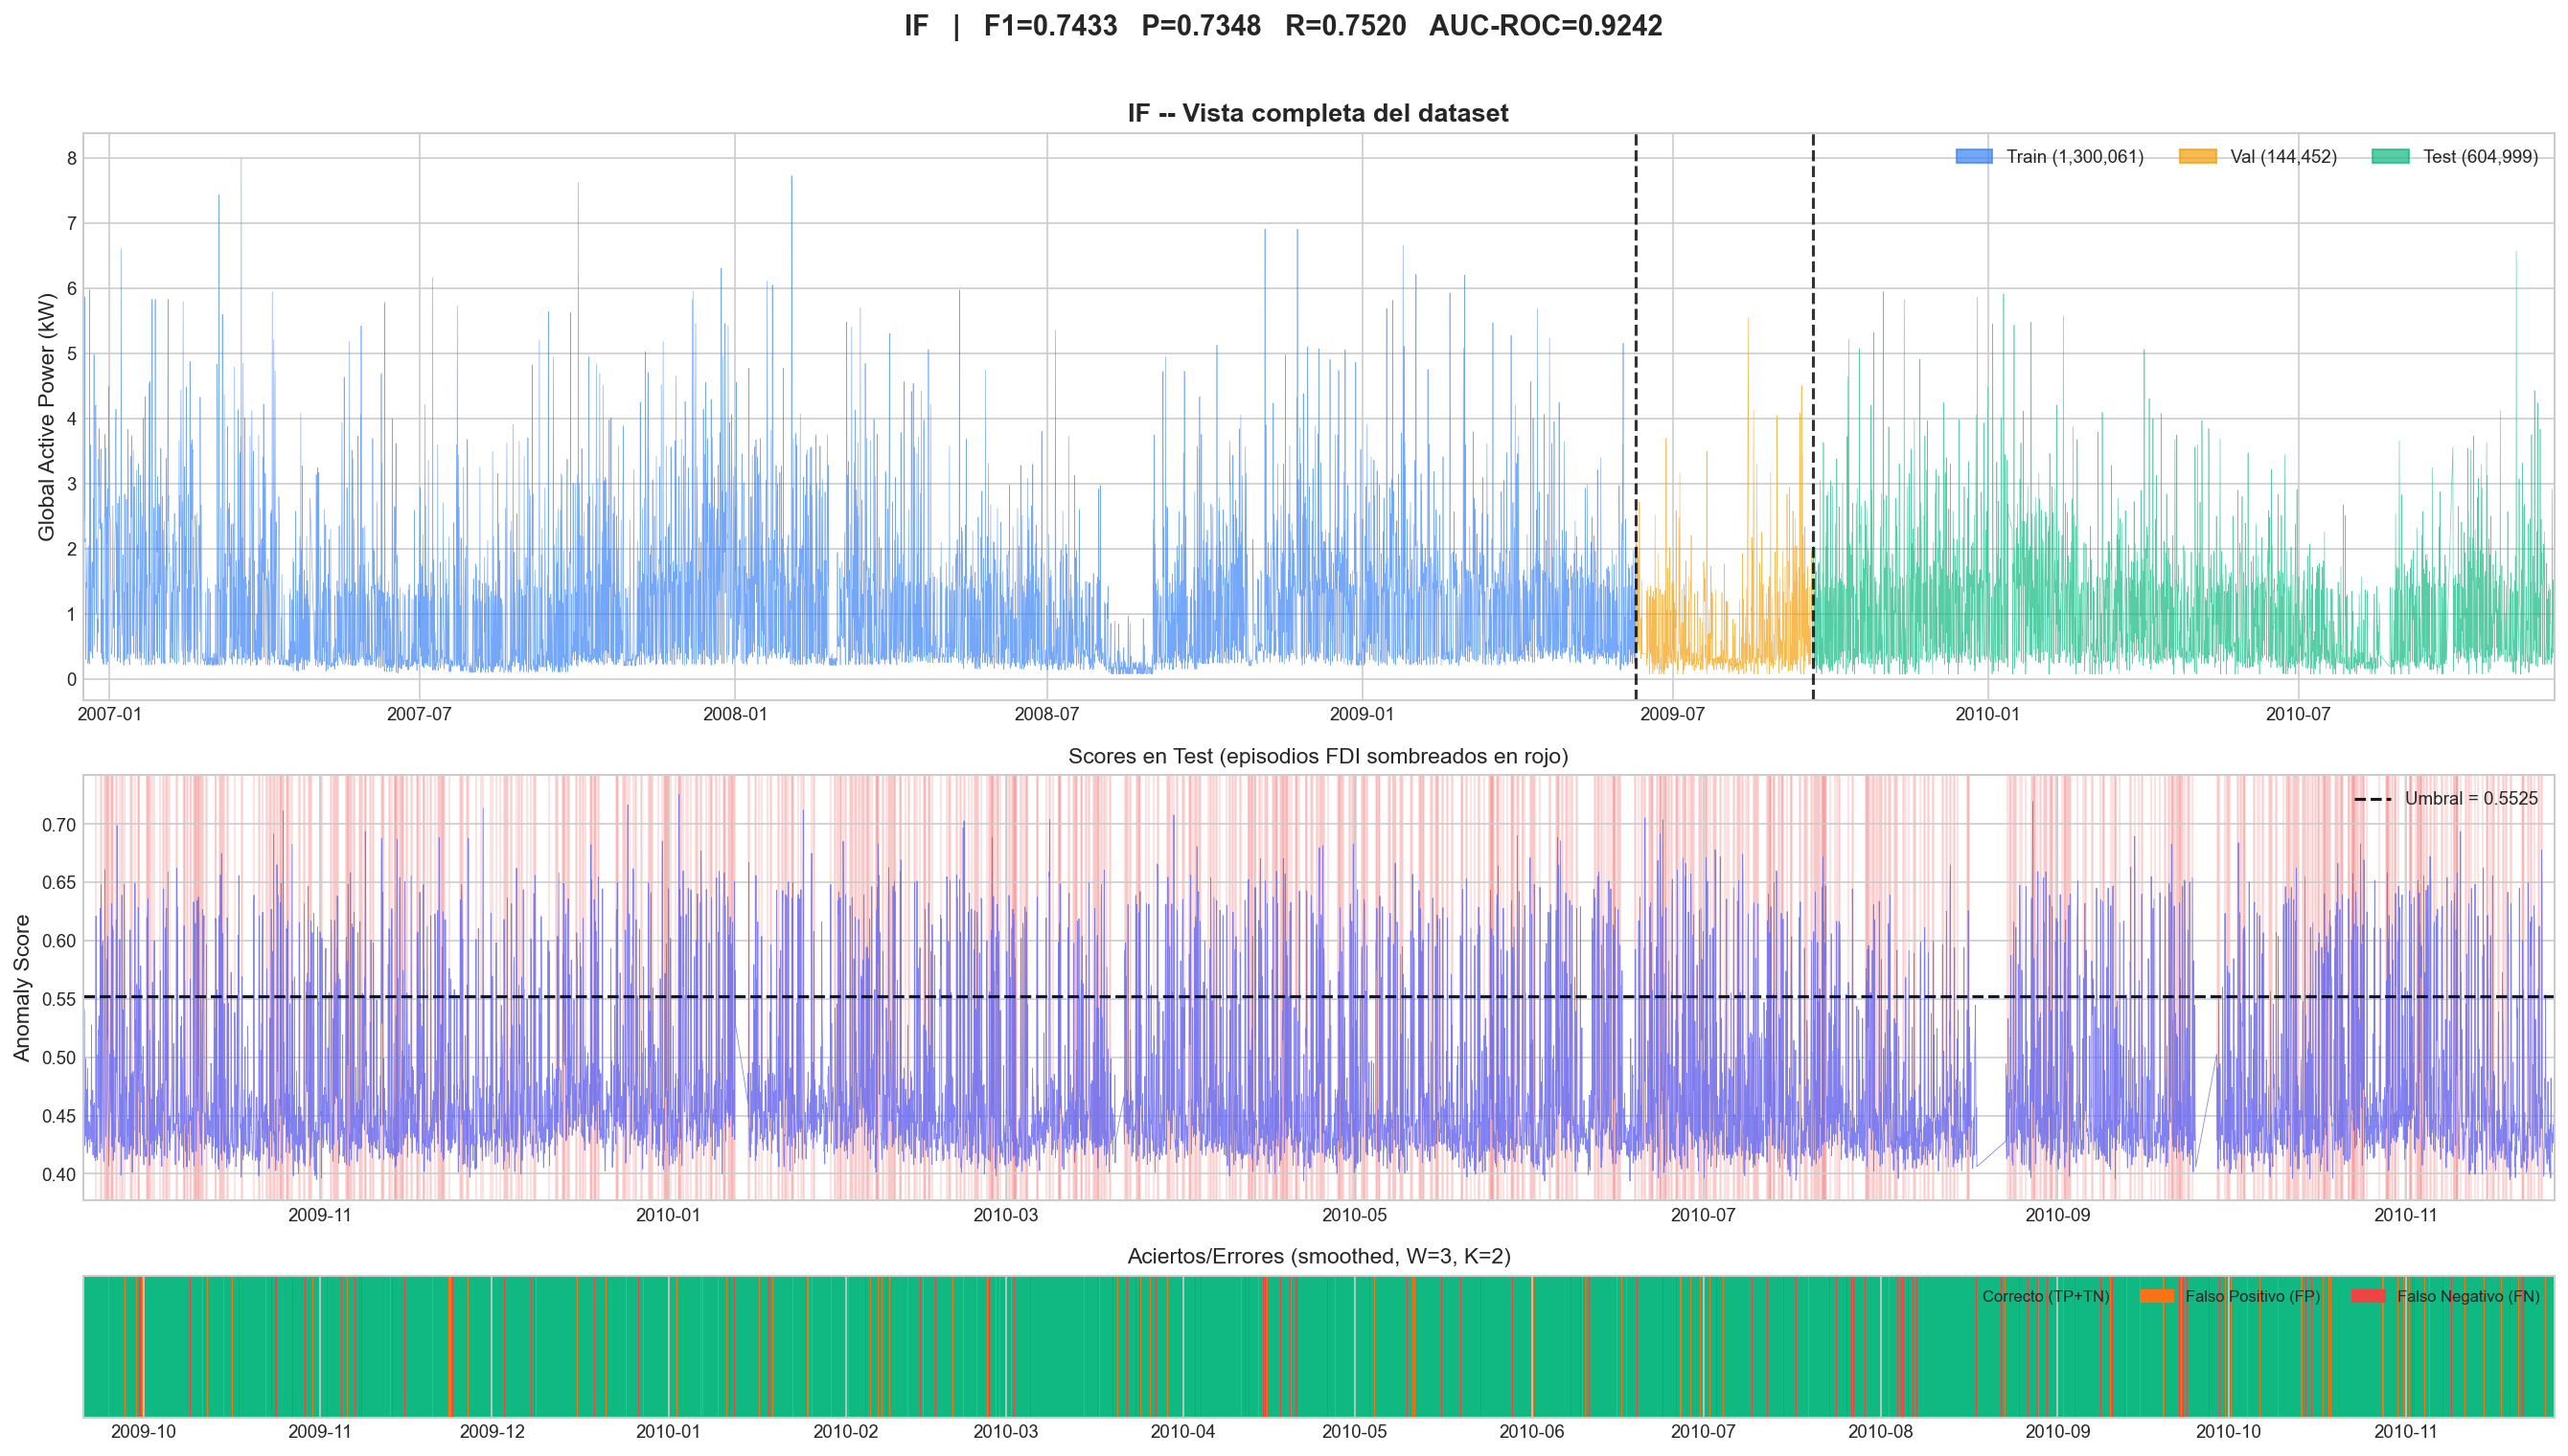


  K-Means+IF
  Guardado: figures/timeline_k-means_if.png


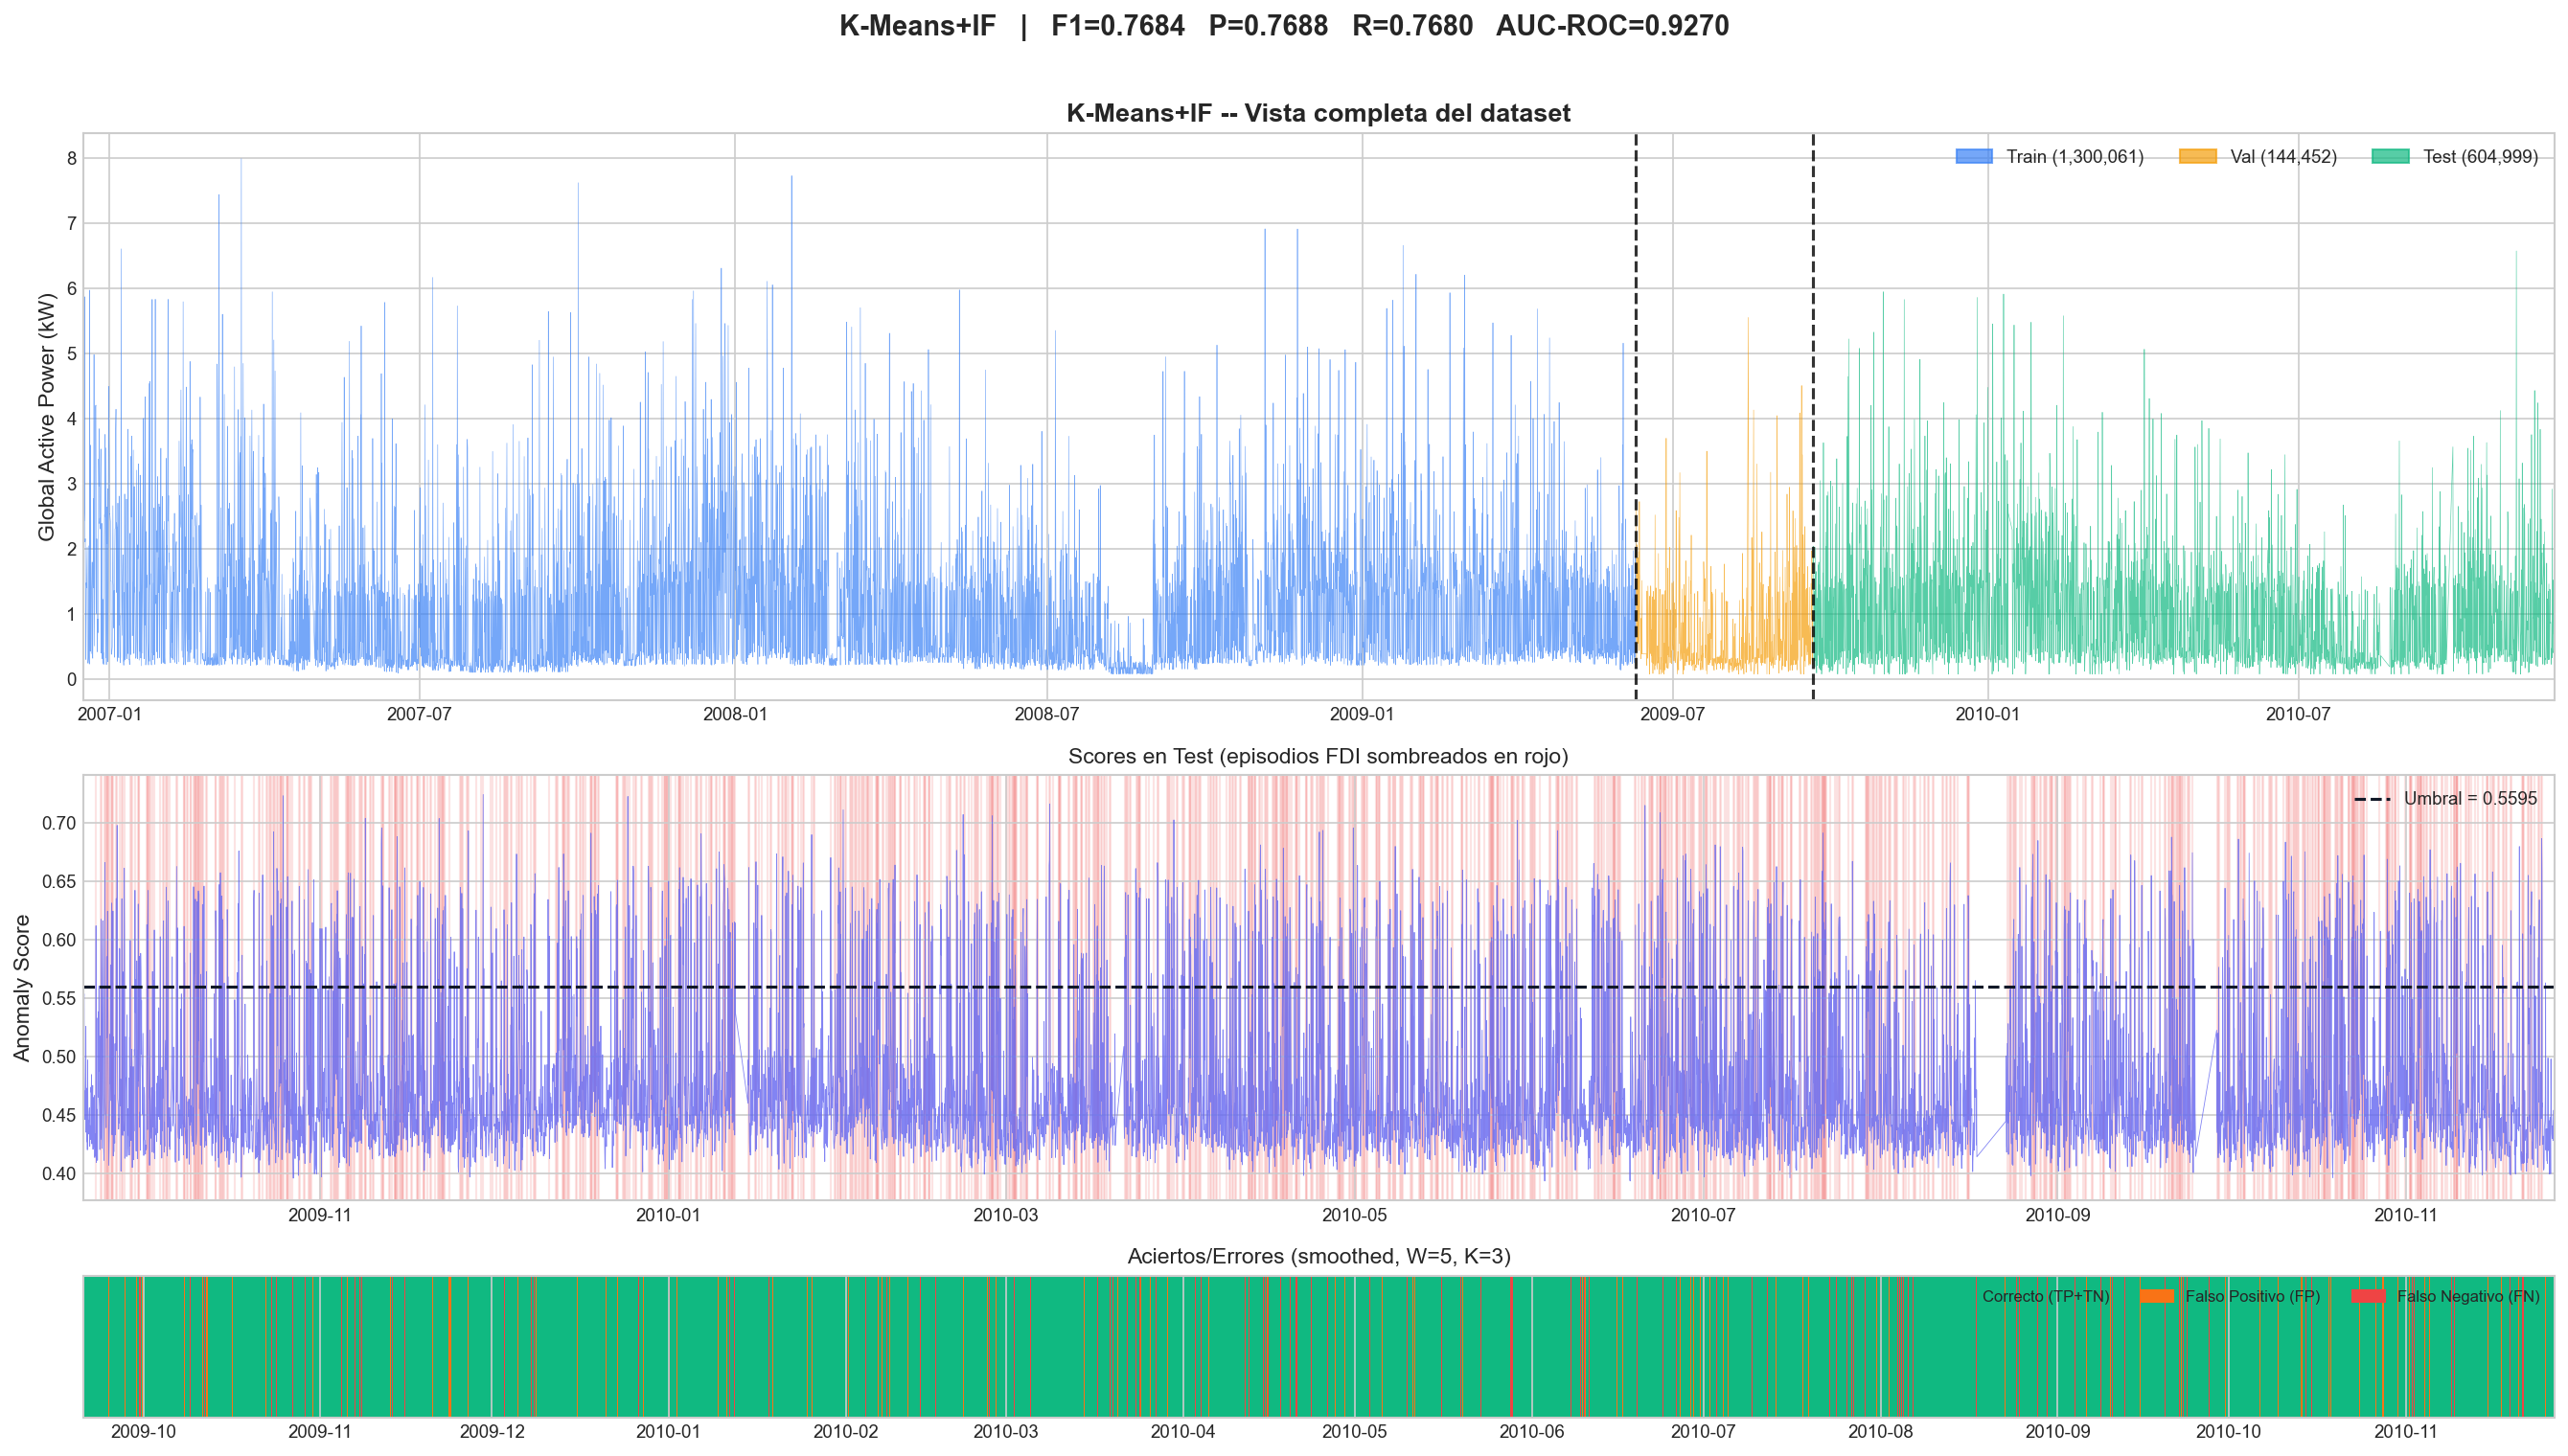


  Dense AE
  Guardado: figures/timeline_dense_ae.png


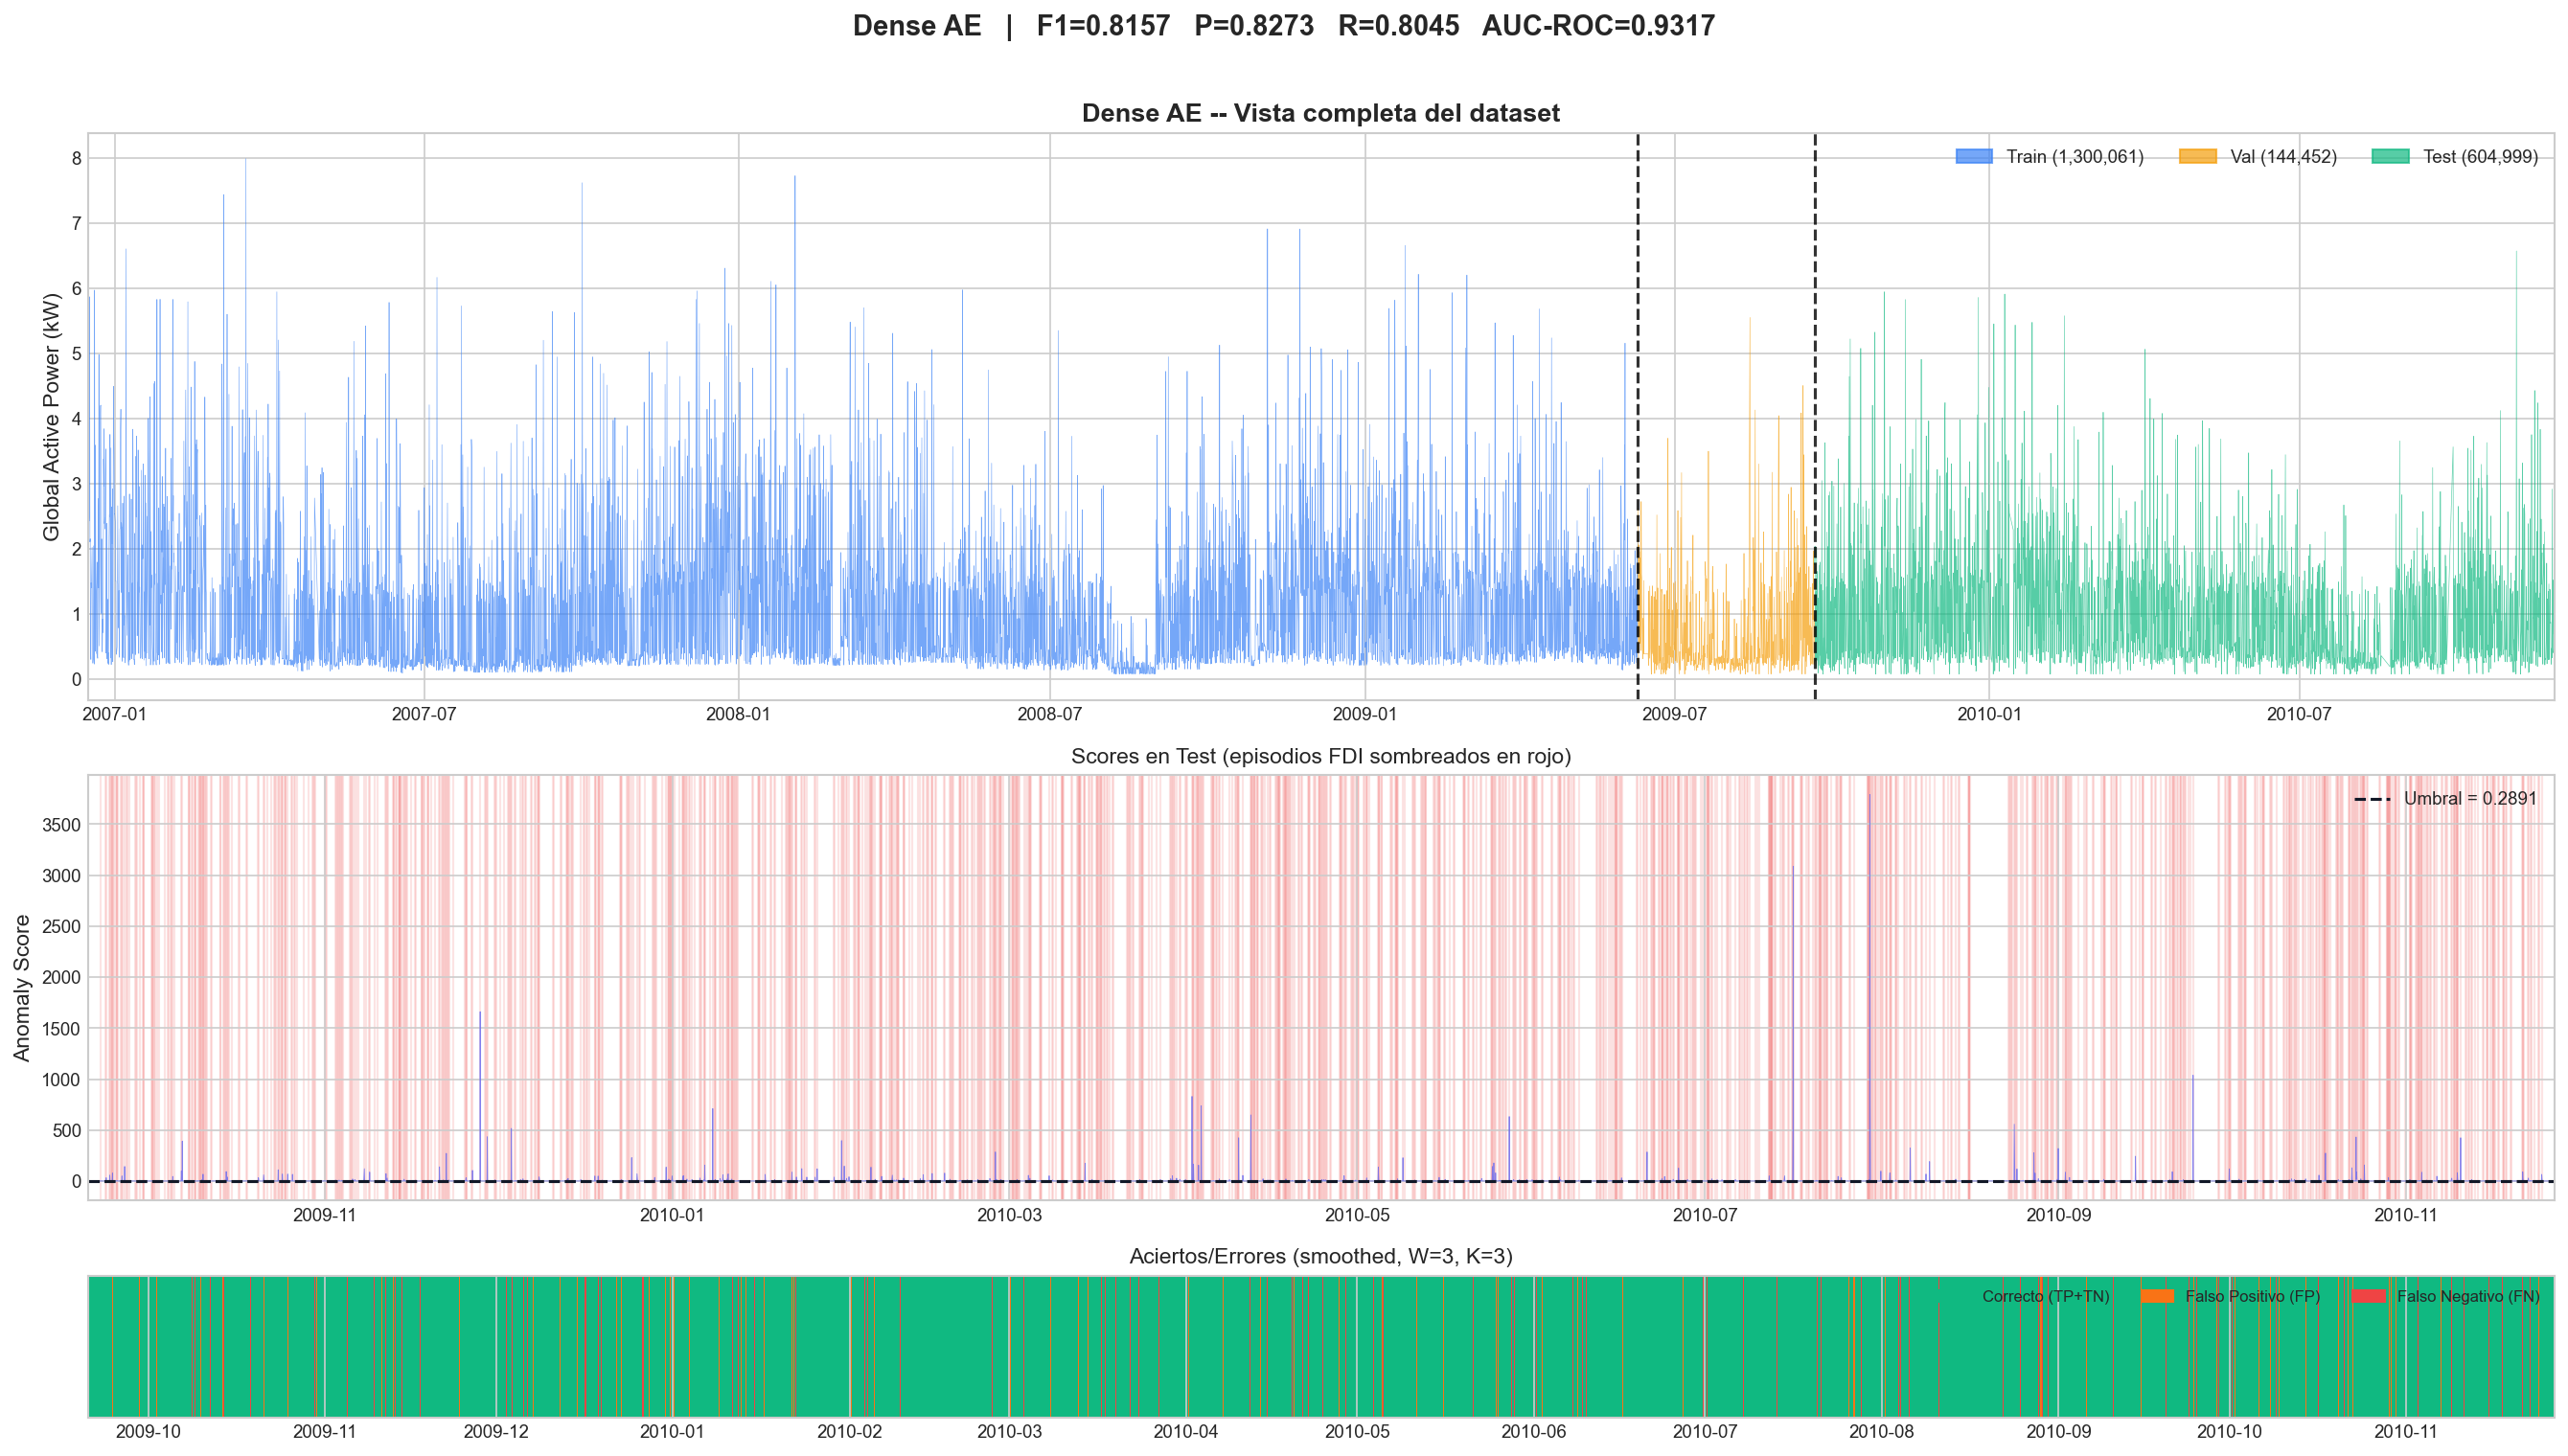


  LSTM AE
  Guardado: figures/timeline_lstm_ae.png


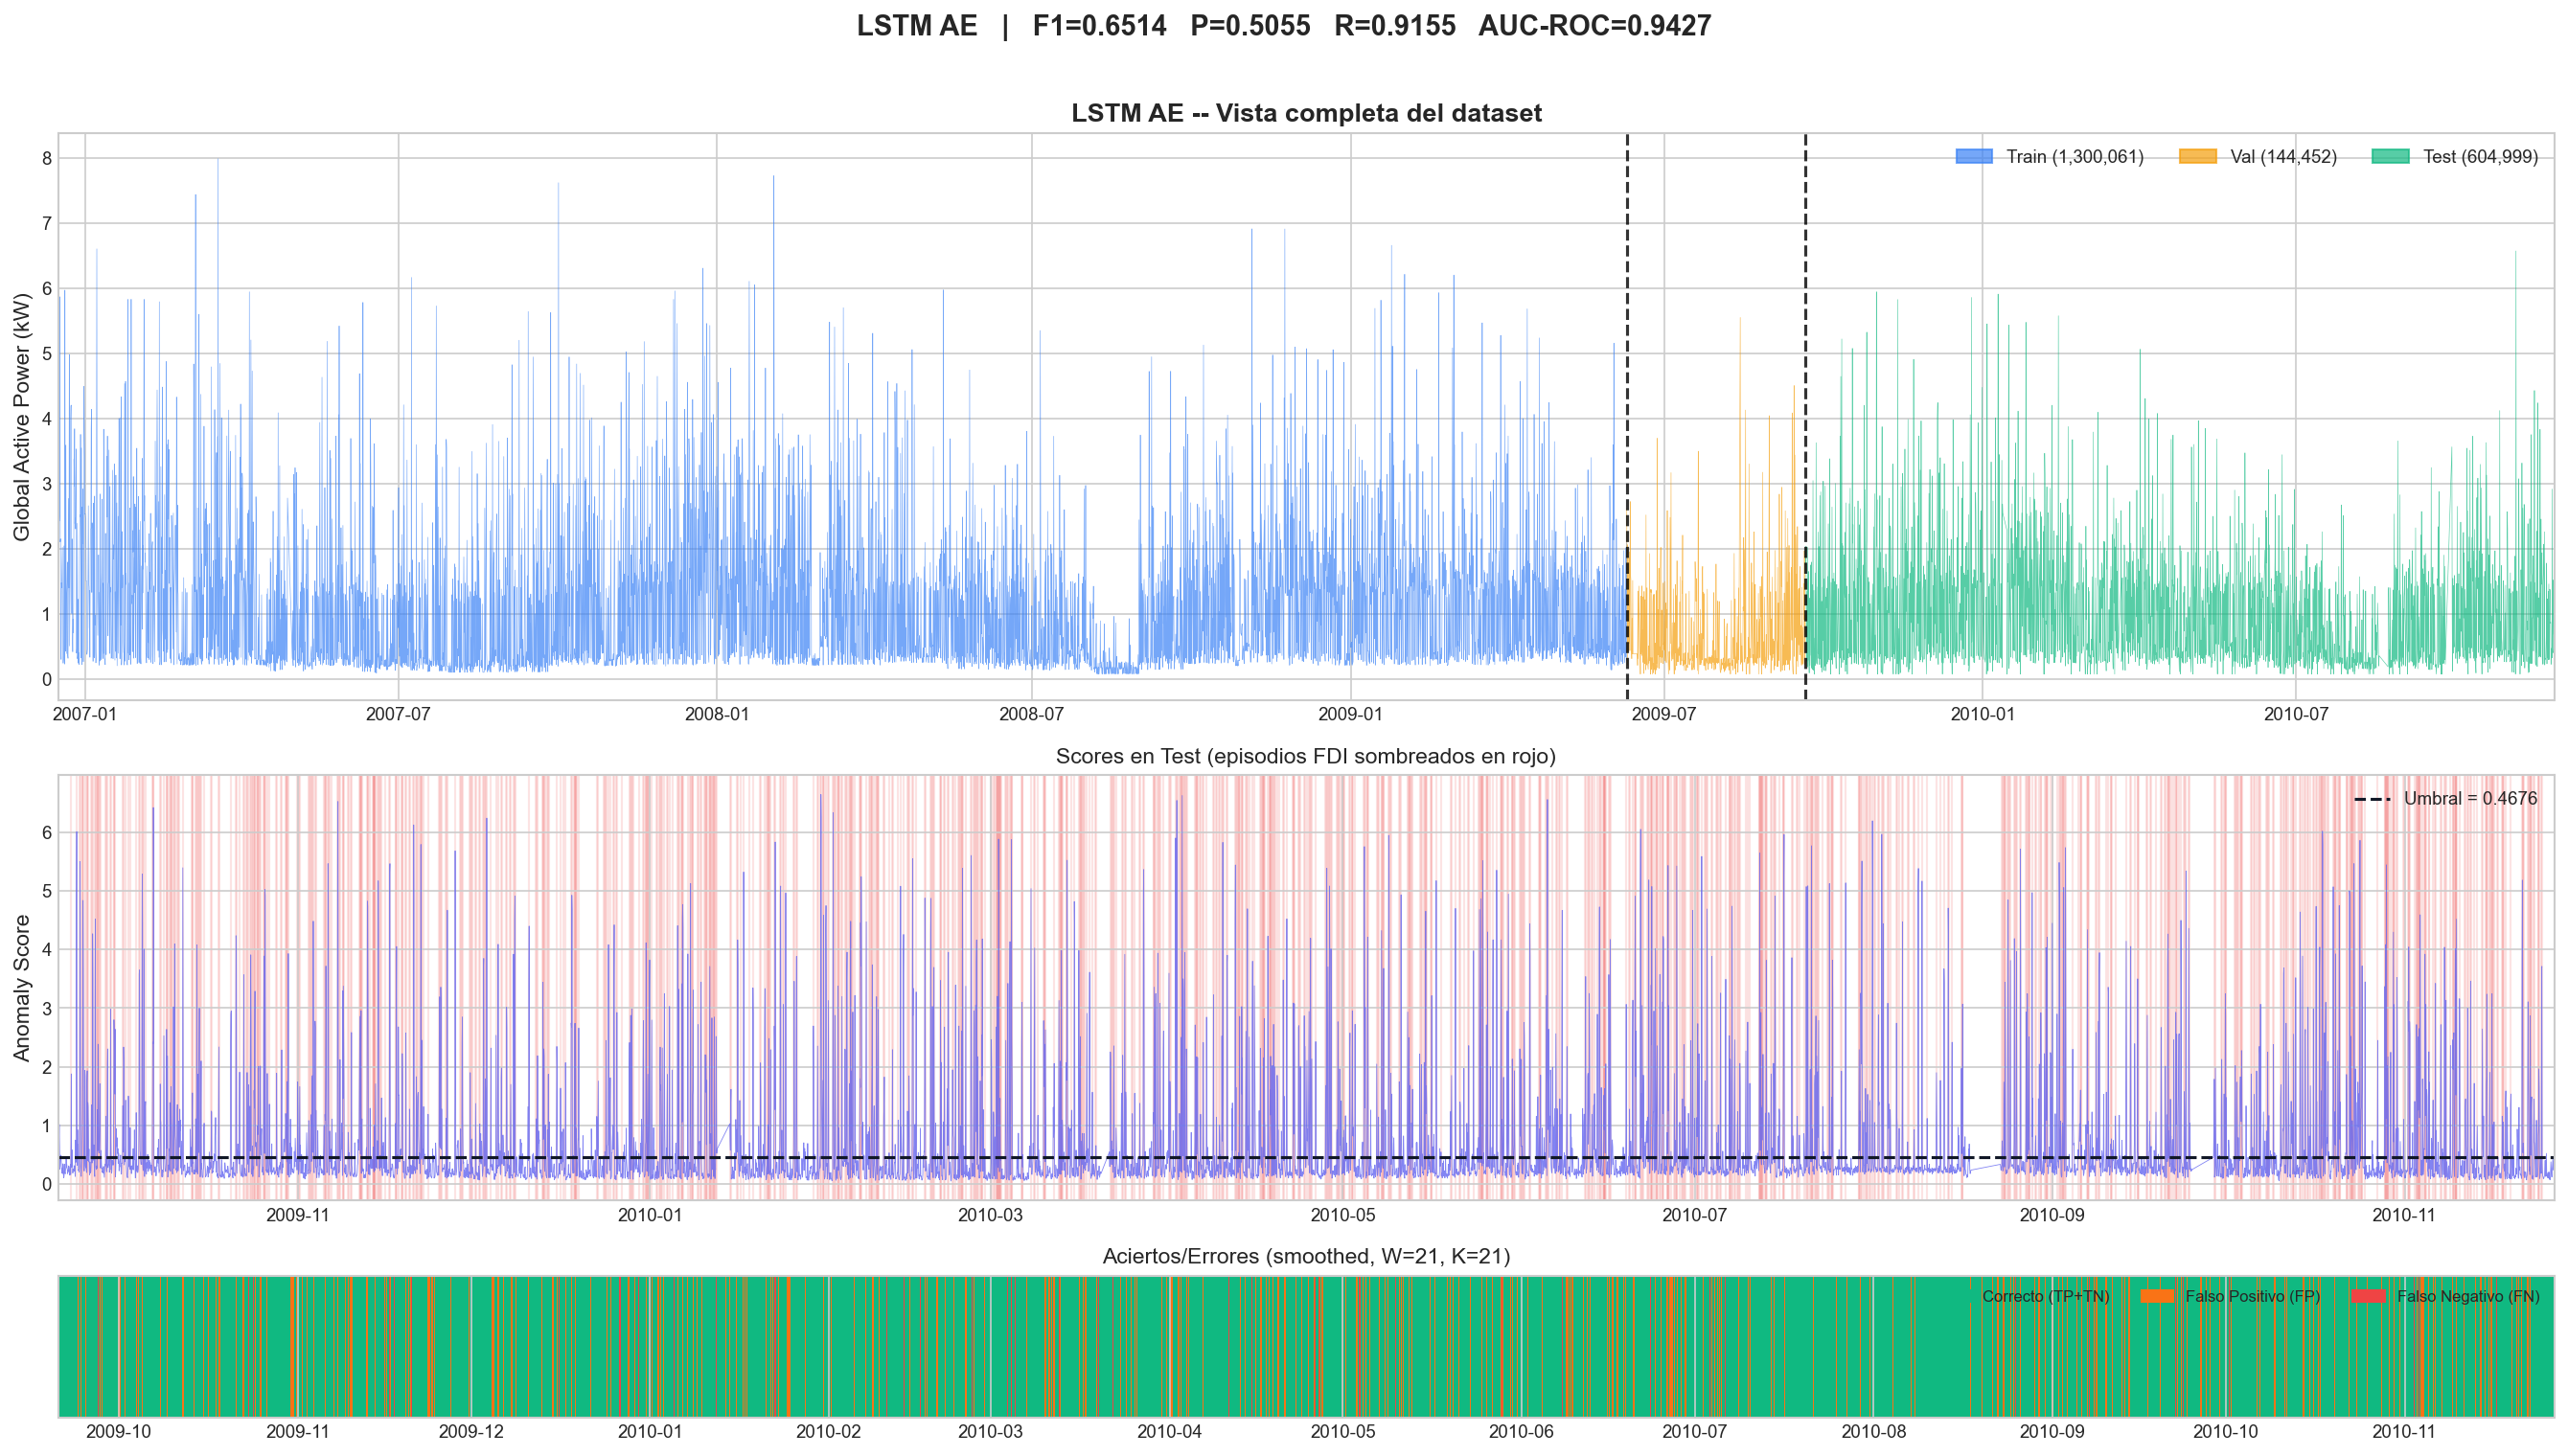

In [4]:
for name, info in MODELS.items():

    print(f'\n{"="*70}')

    print(f'  {name}')

    print(f'{"="*70}')

    

    safe_name = name.lower().replace(' ', '_').replace('+', '_')

    save_path = os.path.join(FIGURES_DIR, f'timeline_{safe_name}.png')

    

    plot_timeline(

        model_name=name,

        df_train=df_train,

        df_val=df_val,

        df_test=df_test,

        df_preds=info['preds'],

        score_col=info['score_col'],

        smooth_col=info['smooth_col'],

        threshold=info['threshold'],

        metrics=info['metrics'],

        save_path=save_path,

    )

## 4. Timeline Zoom -- Una Semana Representativa


Vista ampliada de una semana con episodios visibles, para que la tutora

pueda ver el detalle del proceso de deteccion.

Semana seleccionada: 2009-09-20 (13 episodios)

  Guardado: figures/timeline_zoom_if.png


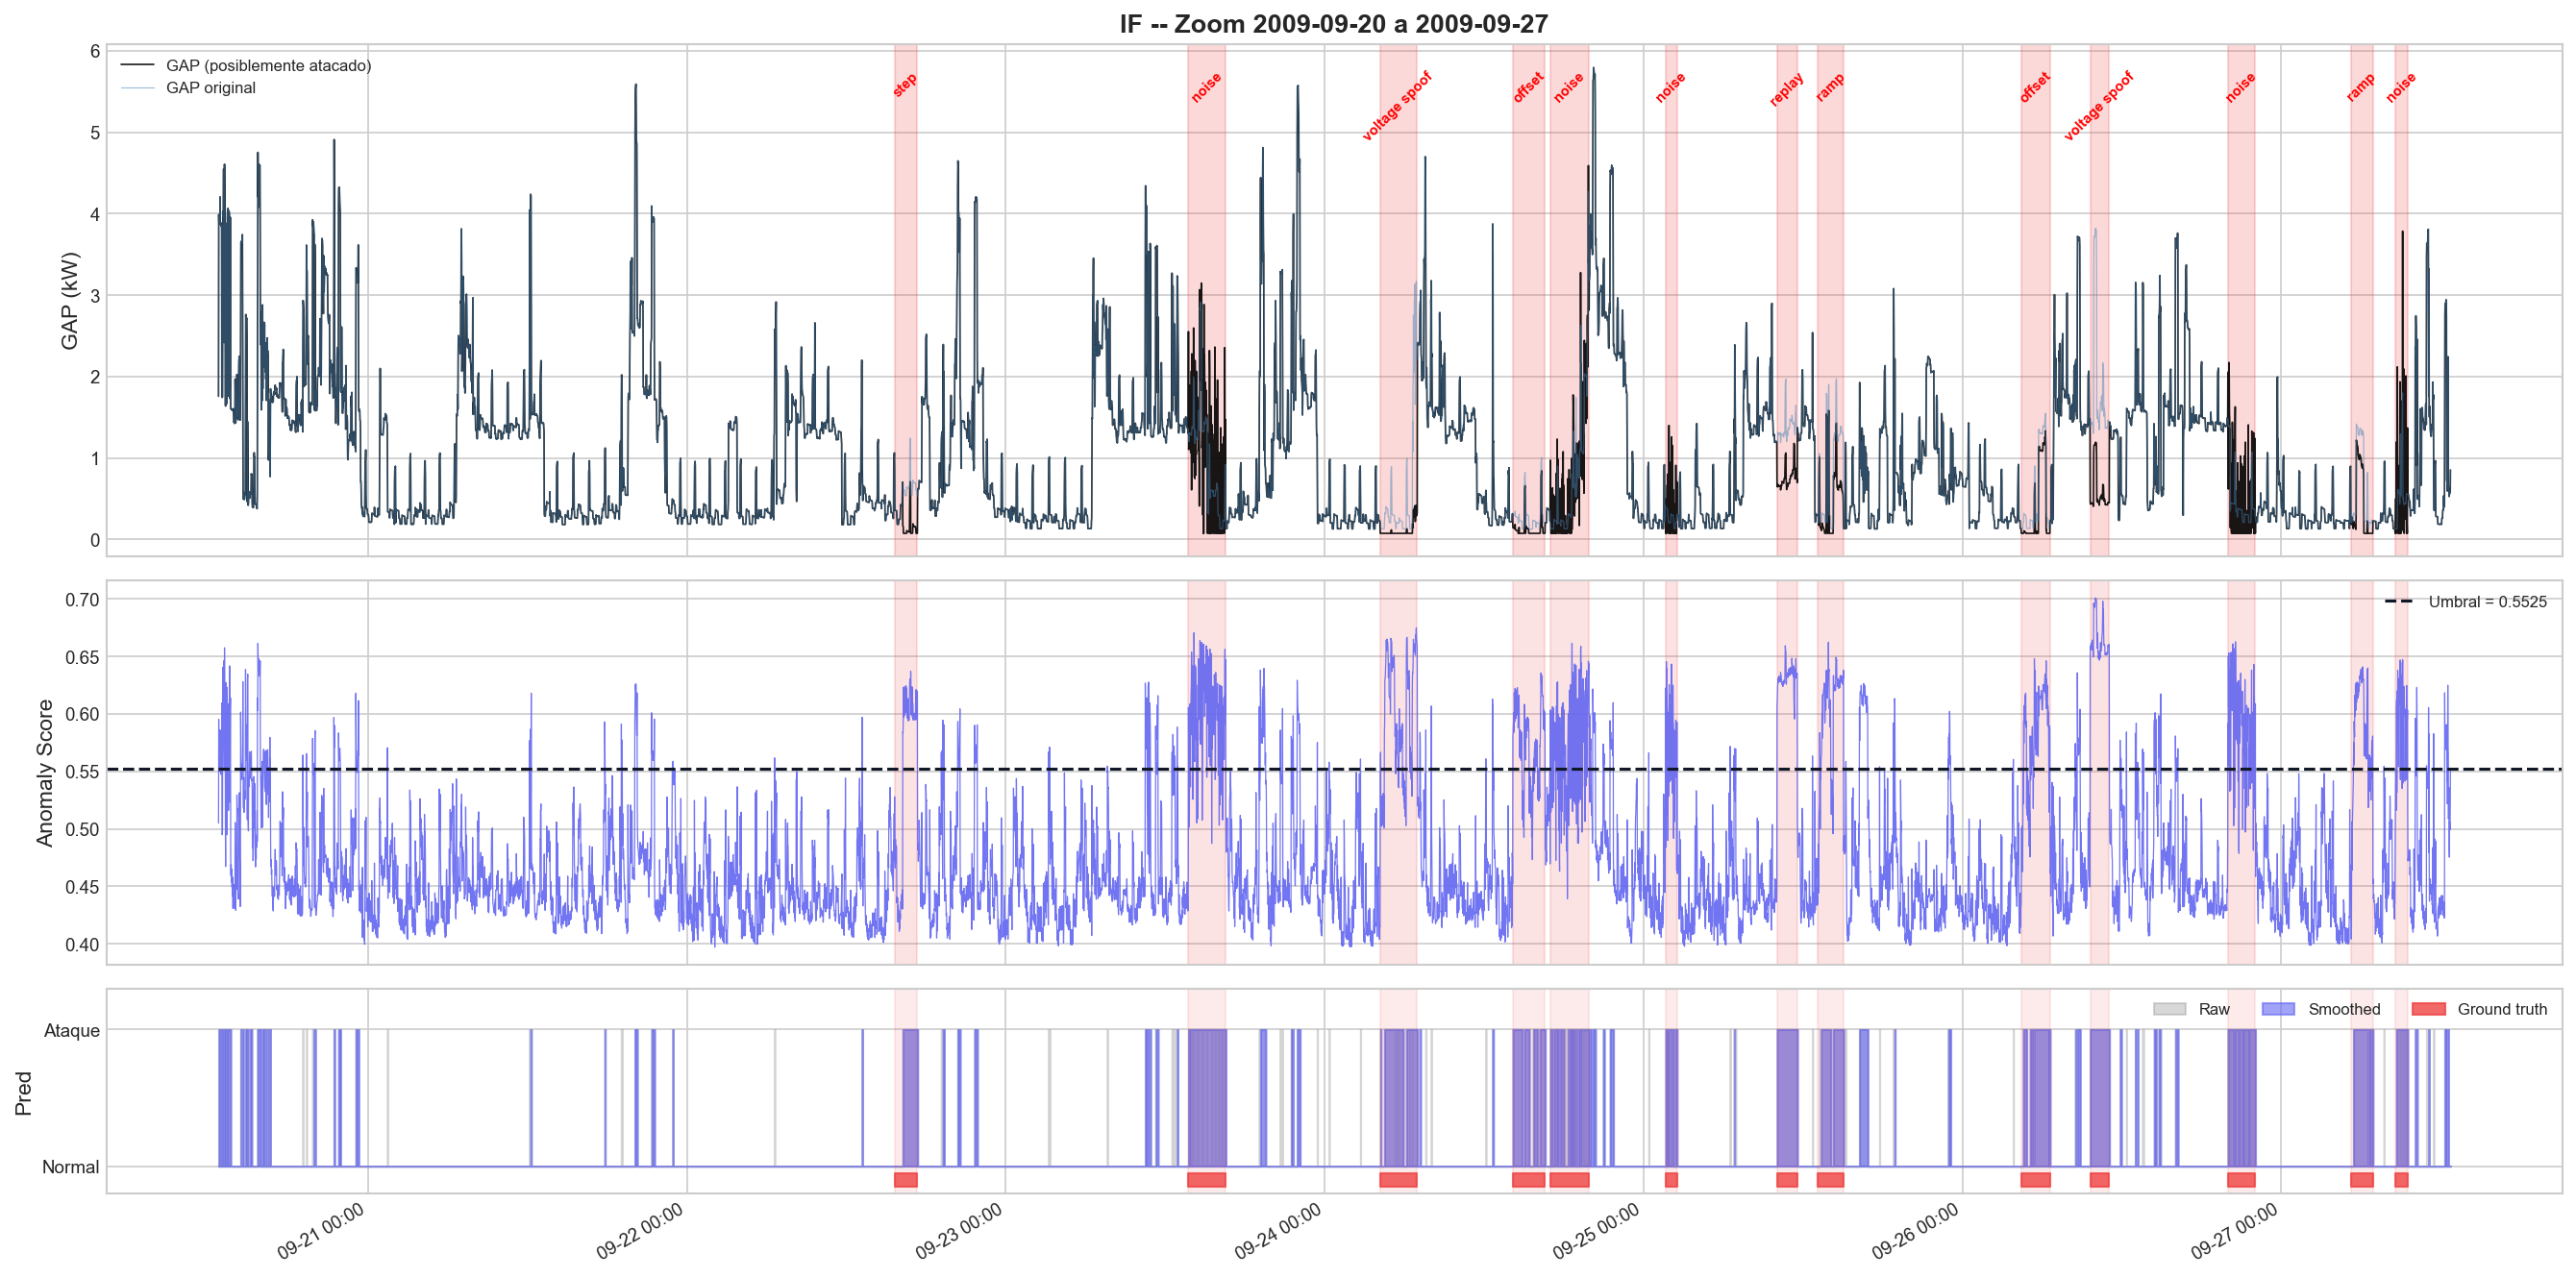

  Guardado: figures/timeline_zoom_k-means_if.png


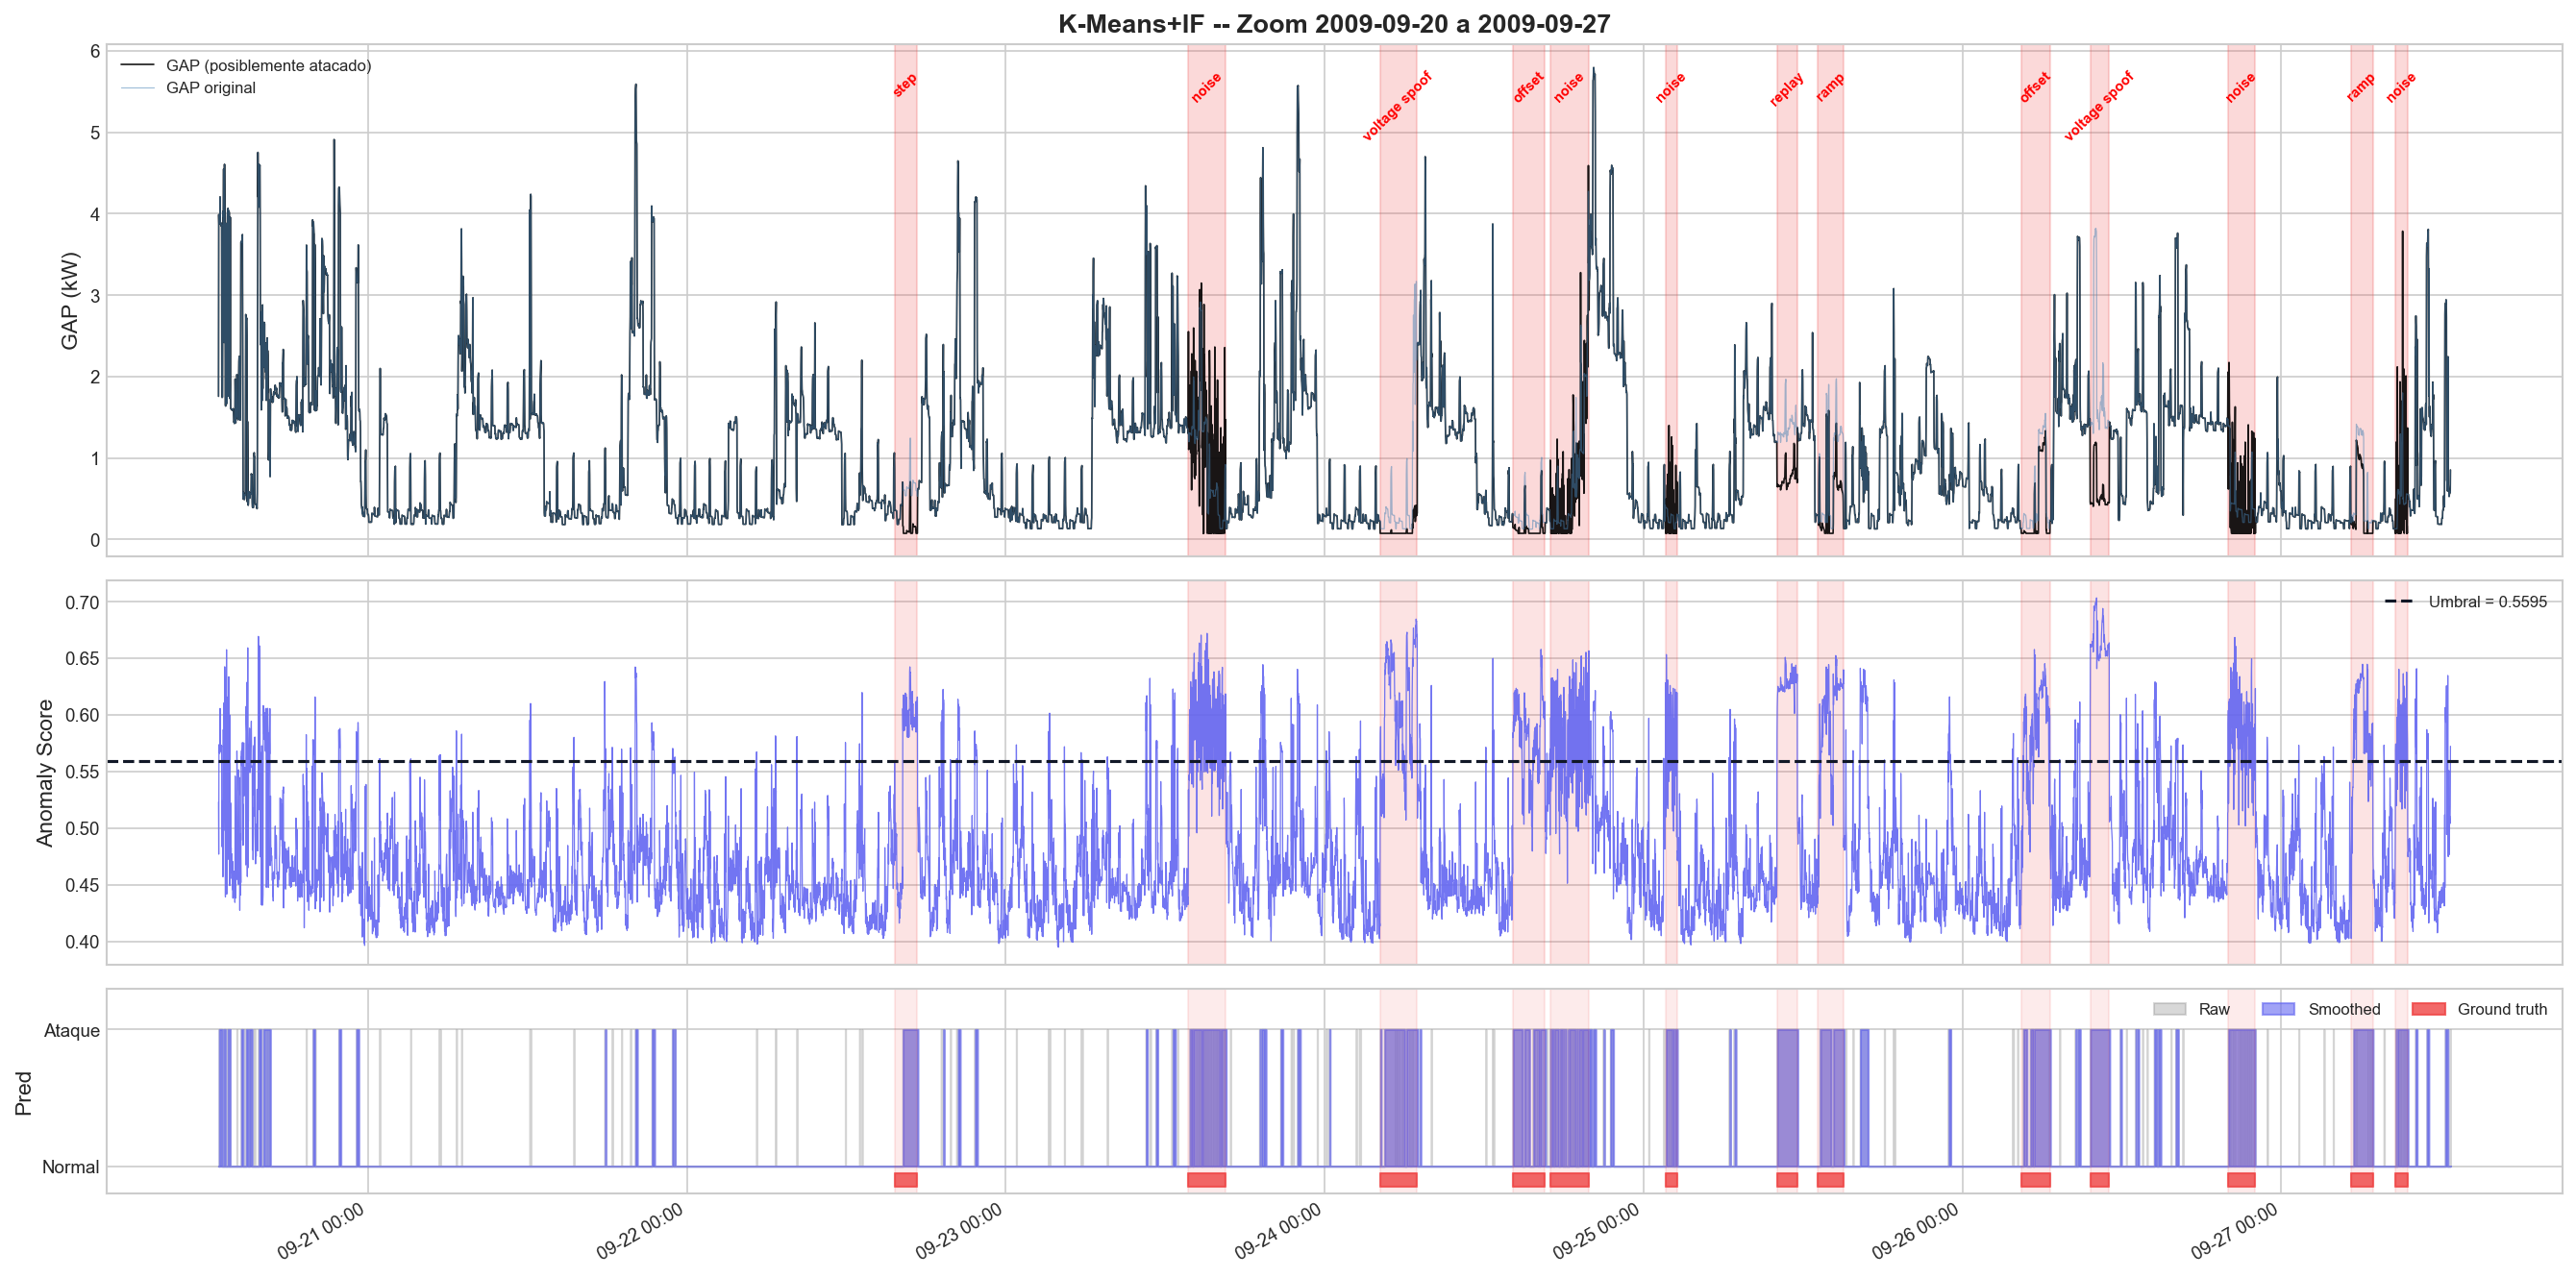

  Guardado: figures/timeline_zoom_dense_ae.png


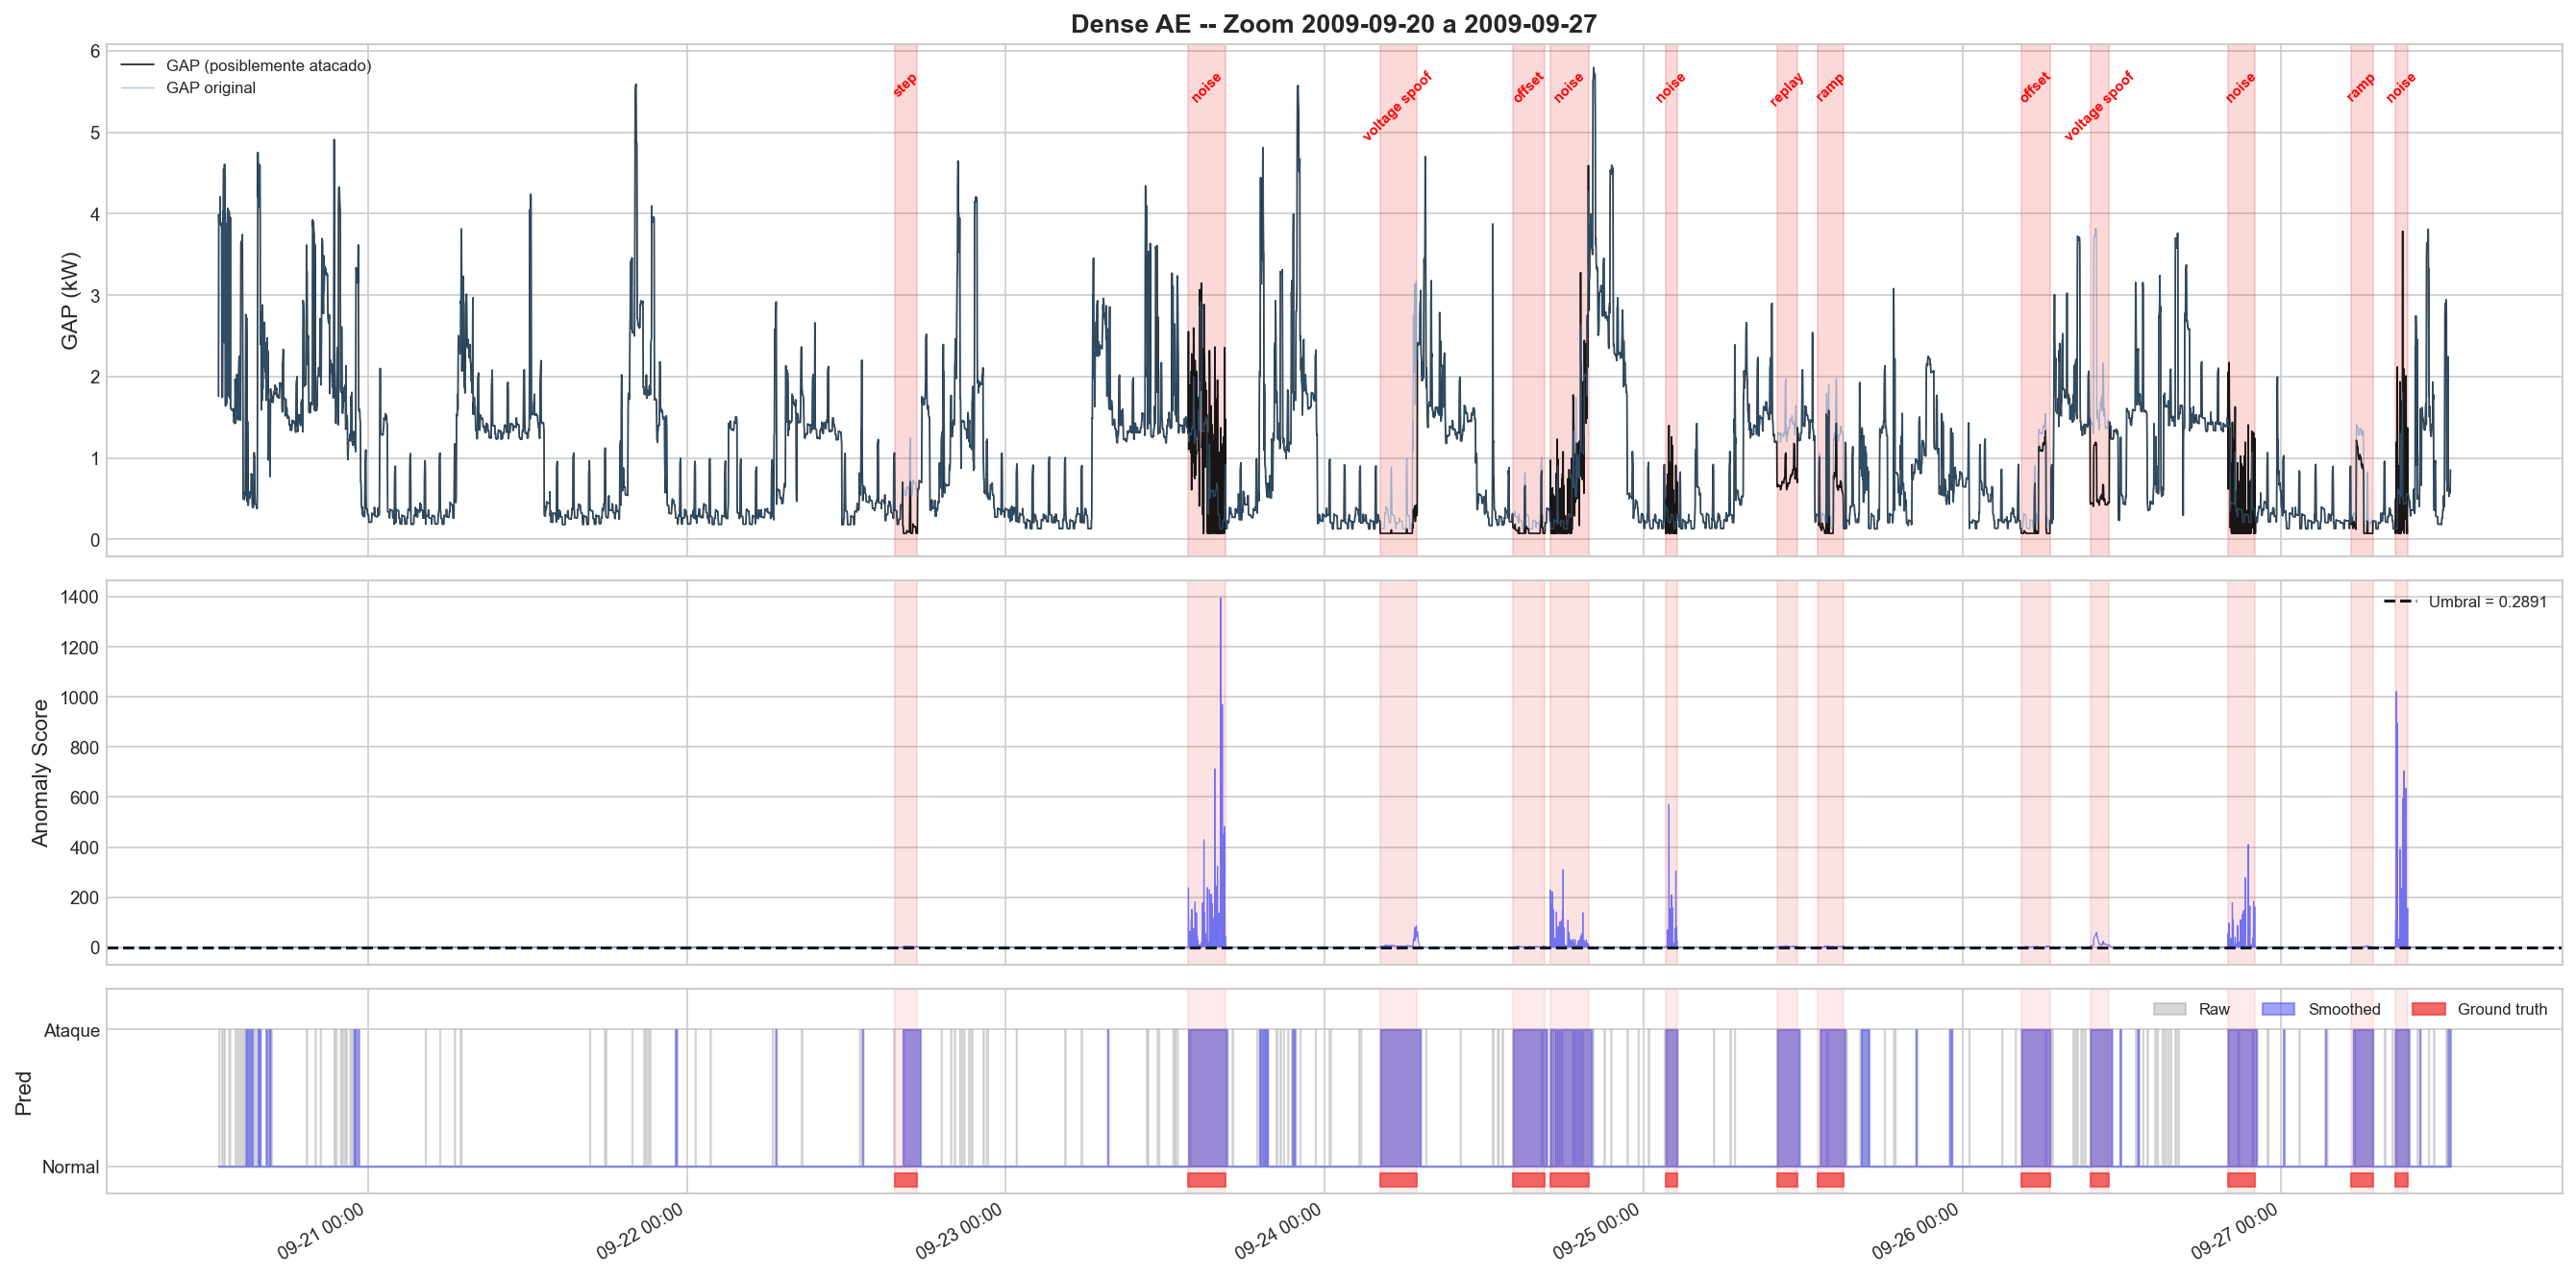

  Guardado: figures/timeline_zoom_lstm_ae.png


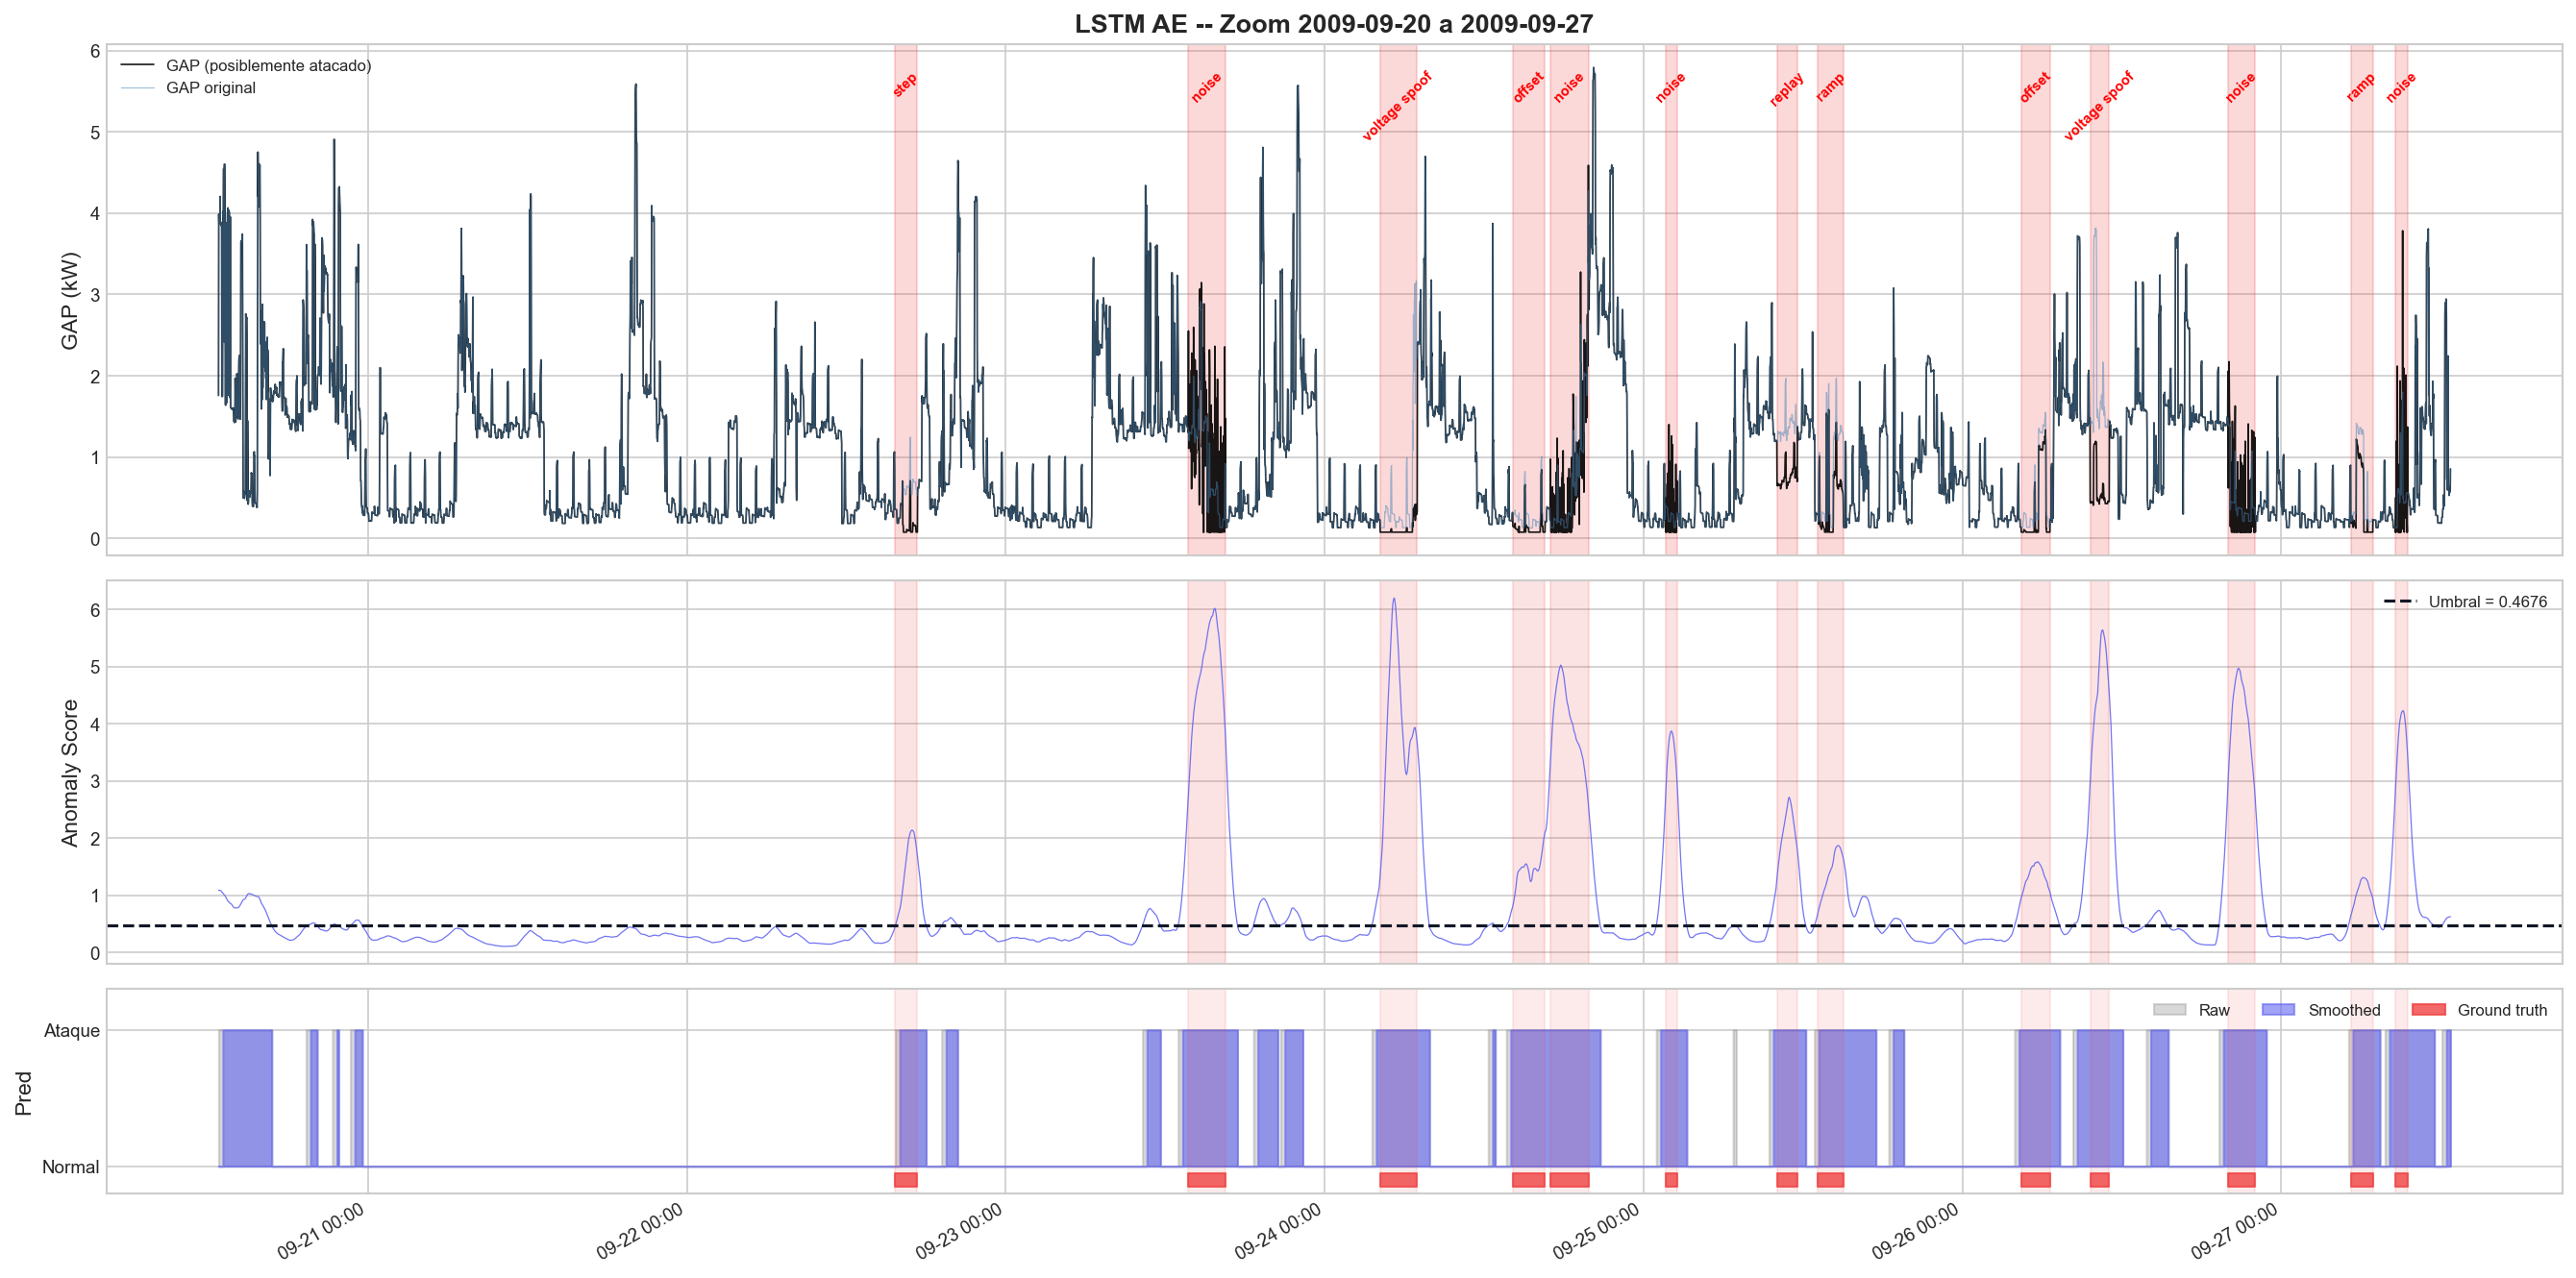

In [5]:
def plot_timeline_zoom(model_name, df_preds, score_col, smooth_col,

                      threshold, metrics, start_date, n_days=7,

                      save_path=None, figsize=(18, 9)):

    '''

    Zoom de timeline sobre un periodo de n_days dias.

    Muestra la senal GAP, scores, y predicciones con suficiente detalle

    para ver episodios individuales.

    '''

    end_date = start_date + pd.Timedelta(days=n_days)

    mask = (df_preds.index >= start_date) & (df_preds.index < end_date)

    df_z = df_preds[mask]

    

    if len(df_z) == 0:

        print(f'  Sin datos entre {start_date} y {end_date}')

        return

    

    fig, axes = plt.subplots(3, 1, figsize=figsize,

                              gridspec_kw={'height_ratios': [2, 1.5, 0.8]},

                              sharex=True)

    

    y_true = df_z['label'].values.astype(int)

    scores = df_z[score_col].values

    y_pred = df_z[smooth_col].values.astype(int)

    

    # Panel 1: GAP original vs atacado

    ax = axes[0]

    ax.plot(df_z.index, df_z['Global_active_power'], 'k-', lw=0.8,

            label='GAP (posiblemente atacado)', alpha=0.9)

    if 'GAP_original' in df_z.columns:

        ax.plot(df_z.index, df_z['GAP_original'], color='steelblue',

                lw=0.6, alpha=0.5, label='GAP original')

    

    # Sombrear episodios

    episodes_in_range = df_z[df_z['episode_id'] >= 0]

    if len(episodes_in_range) > 0:

        for ep_id in episodes_in_range['episode_id'].unique():

            ep = df_z[df_z['episode_id'] == ep_id]

            ax.axvspan(ep.index[0], ep.index[-1], alpha=0.2,

                       color=COLORS['attack'])

            # Etiqueta del tipo de ataque

            mid = ep.index[len(ep)//2]

            atype = ep['attack_type'].iloc[0]

            ax.text(mid, ax.get_ylim()[1]*0.95, atype.replace('_', ' '),

                    ha='center', va='top', fontsize=7, color='red',

                    fontweight='bold', rotation=45)

    

    ax.set_ylabel('GAP (kW)')

    ax.set_title(f'{model_name} -- Zoom {start_date.date()} a {end_date.date()}',

                 fontweight='bold')

    ax.legend(loc='upper left', fontsize=8)

    

    # Panel 2: Scores

    ax = axes[1]

    ax.plot(df_z.index, scores, color=COLORS['score'], lw=0.6, alpha=0.9)

    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,

               label=f'Umbral = {threshold:.4f}')

    for ep_id in episodes_in_range['episode_id'].unique() if len(episodes_in_range) > 0 else []:

        ep = df_z[df_z['episode_id'] == ep_id]

        ax.axvspan(ep.index[0], ep.index[-1], alpha=0.15, color=COLORS['attack'])

    ax.set_ylabel('Anomaly Score')

    ax.legend(loc='upper right', fontsize=8)

    

    # Panel 3: Predicciones raw vs smoothed

    ax = axes[2]

    y_raw = df_z[smooth_col.replace('smooth', 'raw')].values.astype(int) if             smooth_col.replace('smooth', 'raw') in df_z.columns else y_pred

    

    ax.fill_between(df_z.index, 0, y_raw, alpha=0.3, color='gray',

                     step='mid', label='Raw')

    ax.fill_between(df_z.index, 0, y_pred, alpha=0.6, color=COLORS['score'],

                     step='mid', label='Smoothed')

    # Groundtruth

    ax.fill_between(df_z.index, -0.15, -0.05, where=(y_true==1),

                     color=COLORS['attack'], alpha=0.8, step='mid',

                     label='Ground truth')

    for ep_id in episodes_in_range['episode_id'].unique() if len(episodes_in_range) > 0 else []:

        ep = df_z[df_z['episode_id'] == ep_id]

        ax.axvspan(ep.index[0], ep.index[-1], alpha=0.1, color=COLORS['attack'])

    

    ax.set_ylabel('Pred')

    ax.set_yticks([0, 1])

    ax.set_yticklabels(['Normal', 'Ataque'])

    ax.set_ylim(-0.2, 1.3)

    ax.legend(loc='upper right', fontsize=8, ncol=3)

    

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

    ax.xaxis.set_major_locator(mdates.DayLocator())

    plt.xticks(rotation=30, ha='right')

    

    plt.tight_layout()

    if save_path:

        fig.savefig(save_path, dpi=300, bbox_inches='tight')

        print(f'  Guardado: {save_path}')

    plt.show()

    return fig


# ── Buscar una semana con varios episodios ──

# Tomar la primera semana que tenga al menos 3 episodios

test_start = df_test.index[0]

best_week_start = test_start

best_n_eps = 0


for offset_days in range(0, len(df_test) // 1440 - 7, 3):

    ws = test_start + pd.Timedelta(days=offset_days)

    we = ws + pd.Timedelta(days=7)

    mask = (df_test.index >= ws) & (df_test.index < we)

    n_ep = df_test.loc[mask & (df_test['episode_id'] >= 0), 'episode_id'].nunique()

    if n_ep > best_n_eps:

        best_n_eps = n_ep

        best_week_start = ws

    if best_n_eps >= 5:

        break


print(f'Semana seleccionada: {best_week_start.date()} ({best_n_eps} episodios)')

print()


# Ejecutar zoom para cada modelo

for name, info in MODELS.items():

    safe_name = name.lower().replace(' ', '_').replace('+', '_')

    save_path = os.path.join(FIGURES_DIR, f'timeline_zoom_{safe_name}.png')

    

    plot_timeline_zoom(

        model_name=name,

        df_preds=info['preds'],

        score_col=info['score_col'],

        smooth_col=info['smooth_col'],

        threshold=info['threshold'],

        metrics=info['metrics'],

        start_date=best_week_start,

        n_days=7,

        save_path=save_path,

    )

## 5. Grid de Episodios por Tipo de Ataque


Para el **mejor modelo** (mayor F1), generamos 1 figura por cada tipo de ataque

mostrando:


1. Senal original vs atacada (GAP_original vs Global_active_power)

2. Anomaly score con umbral

3. Prediccion (raw vs smoothed) vs ground truth

In [6]:
def plot_episode(df_preds, episode_id, score_col, raw_col, smooth_col,

                 threshold, model_name, context_min=60,

                 save_path=None, figsize=(16, 9)):

    '''

    Visualizacion detallada de un episodio de ataque FDI.

    

    3 subplots:

      1. Senal original vs atacada (GAP)

      2. Anomaly score con umbral

      3. Prediccion binaria (raw vs smoothed) + ground truth

    

    Args:

        df_preds:     DataFrame con scores, predicciones y metadatos

        episode_id:   ID del episodio a visualizar

        score_col:    columna de anomaly scores

        raw_col:      columna de predicciones raw

        smooth_col:   columna de predicciones smoothed

        threshold:    umbral calibrado

        model_name:   nombre del modelo (para titulo)

        context_min:  minutos de contexto antes y despues del episodio

    '''

    # Encontrar el episodio

    ep_mask = df_preds['episode_id'] == episode_id

    ep_data = df_preds[ep_mask]

    

    if len(ep_data) == 0:

        print(f'Episodio {episode_id} no encontrado')

        return None

    

    attack_type = ep_data['attack_type'].iloc[0]

    severity = ep_data['severity'].iloc[0]

    ep_start = ep_data.index[0]

    ep_end = ep_data.index[-1]

    duration = len(ep_data)

    

    # Contexto temporal

    ctx_start = ep_start - pd.Timedelta(minutes=context_min)

    ctx_end = ep_end + pd.Timedelta(minutes=context_min)

    ctx = df_preds.loc[ctx_start:ctx_end]

    

    if len(ctx) == 0:

        print(f'Sin datos de contexto para episodio {episode_id}')

        return None

    

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,

                              gridspec_kw={'height_ratios': [2, 1.5, 0.8]})

    

    # ── Panel 1: Senal original vs atacada ──

    ax = axes[0]

    ax.plot(ctx.index, ctx['Global_active_power'], 'k-', lw=1.2,

            label='GAP (atacado)', zorder=3)

    if 'GAP_original' in ctx.columns:

        ax.plot(ctx.index, ctx['GAP_original'], color='steelblue',

                lw=1, alpha=0.7, linestyle='--', label='GAP original', zorder=2)

    ax.axvspan(ep_start, ep_end, alpha=0.2, color=COLORS['attack'],

               label=f'Episodio FDI ({duration} min)')

    ax.set_ylabel('GAP (kW)')

    ax.legend(loc='upper left', fontsize=9)

    ax.set_title(f'{model_name} -- {attack_type.replace("_", " ").title()} '

                 f'({severity}), {duration} min',

                 fontweight='bold', fontsize=13)

    

    # ── Panel 2: Anomaly score ──

    ax = axes[1]

    ax.plot(ctx.index, ctx[score_col], color=COLORS['score'], lw=0.8)

    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,

               label=f'Umbral = {threshold:.4f}')

    ax.axvspan(ep_start, ep_end, alpha=0.15, color=COLORS['attack'])

    

    # Resaltar score dentro del episodio

    ep_ctx = ctx.loc[ep_start:ep_end]

    ax.fill_between(ep_ctx.index, threshold, ep_ctx[score_col],

                     where=(ep_ctx[score_col] > threshold),

                     color=COLORS['tp'], alpha=0.3, label='Score > umbral')

    ax.fill_between(ep_ctx.index, threshold, ep_ctx[score_col],

                     where=(ep_ctx[score_col] <= threshold),

                     color=COLORS['fn'], alpha=0.3, label='Score <= umbral')

    

    ax.set_ylabel('Anomaly Score')

    ax.legend(loc='upper right', fontsize=8)

    

    # ── Panel 3: Prediccion binaria ──

    ax = axes[2]

    

    if raw_col in ctx.columns:

        ax.fill_between(ctx.index, 0, ctx[raw_col].values,

                         alpha=0.25, color='gray', step='mid', label='Raw')

    ax.fill_between(ctx.index, 0, ctx[smooth_col].values,

                     alpha=0.6, color=COLORS['score'], step='mid',

                     label='Smoothed')

    

    # Ground truth como banda inferior

    y_true = ctx['label'].values

    ax.fill_between(ctx.index, -0.15, -0.05, where=(y_true == 1),

                     color=COLORS['attack'], alpha=0.8, step='mid',

                     label='Ground truth')

    

    ax.axvspan(ep_start, ep_end, alpha=0.1, color=COLORS['attack'])

    ax.set_ylabel('Pred')

    ax.set_yticks([0, 1])

    ax.set_yticklabels(['Normal', 'Ataque'])

    ax.set_ylim(-0.2, 1.3)

    ax.legend(loc='upper right', fontsize=8, ncol=4)

    

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.xticks(rotation=0)

    ax.set_xlabel(f'{ep_start.date()}')

    

    # ── Metricas del episodio ──

    ep_preds_smooth = ep_data[smooth_col].values.astype(int)

    ep_true = ep_data['label'].values.astype(int)

    recall_ep = ep_preds_smooth.sum() / max(ep_true.sum(), 1)

    

    # Latencia: primer minuto detectado

    detected_idx = np.where(ep_preds_smooth == 1)[0]

    latency = detected_idx[0] if len(detected_idx) > 0 else -1

    latency_str = f'{latency} min' if latency >= 0 else 'No detectado'

    

    fig.text(0.02, -0.02,

             f'Recall episodio: {recall_ep:.0%}  |  '

             f'Latencia: {latency_str}  |  '

             f'Duracion: {duration} min  |  '

             f'Severidad: {severity}',

             fontsize=10, ha='left', style='italic')

    

    plt.tight_layout()

    if save_path:

        fig.savefig(save_path, dpi=300, bbox_inches='tight')

        print(f'  Guardado: {save_path}')

    plt.show()

    return fig


print('plot_episode() definida')

plot_episode() definida


## 6. Episodios por Tipo de Ataque -- Mejor Modelo

Mejor modelo: Dense AE (F1=0.8157)


--- scaling ---
  Episodio 35: medium, 83 min
  Guardado: figures/episode_scaling.png


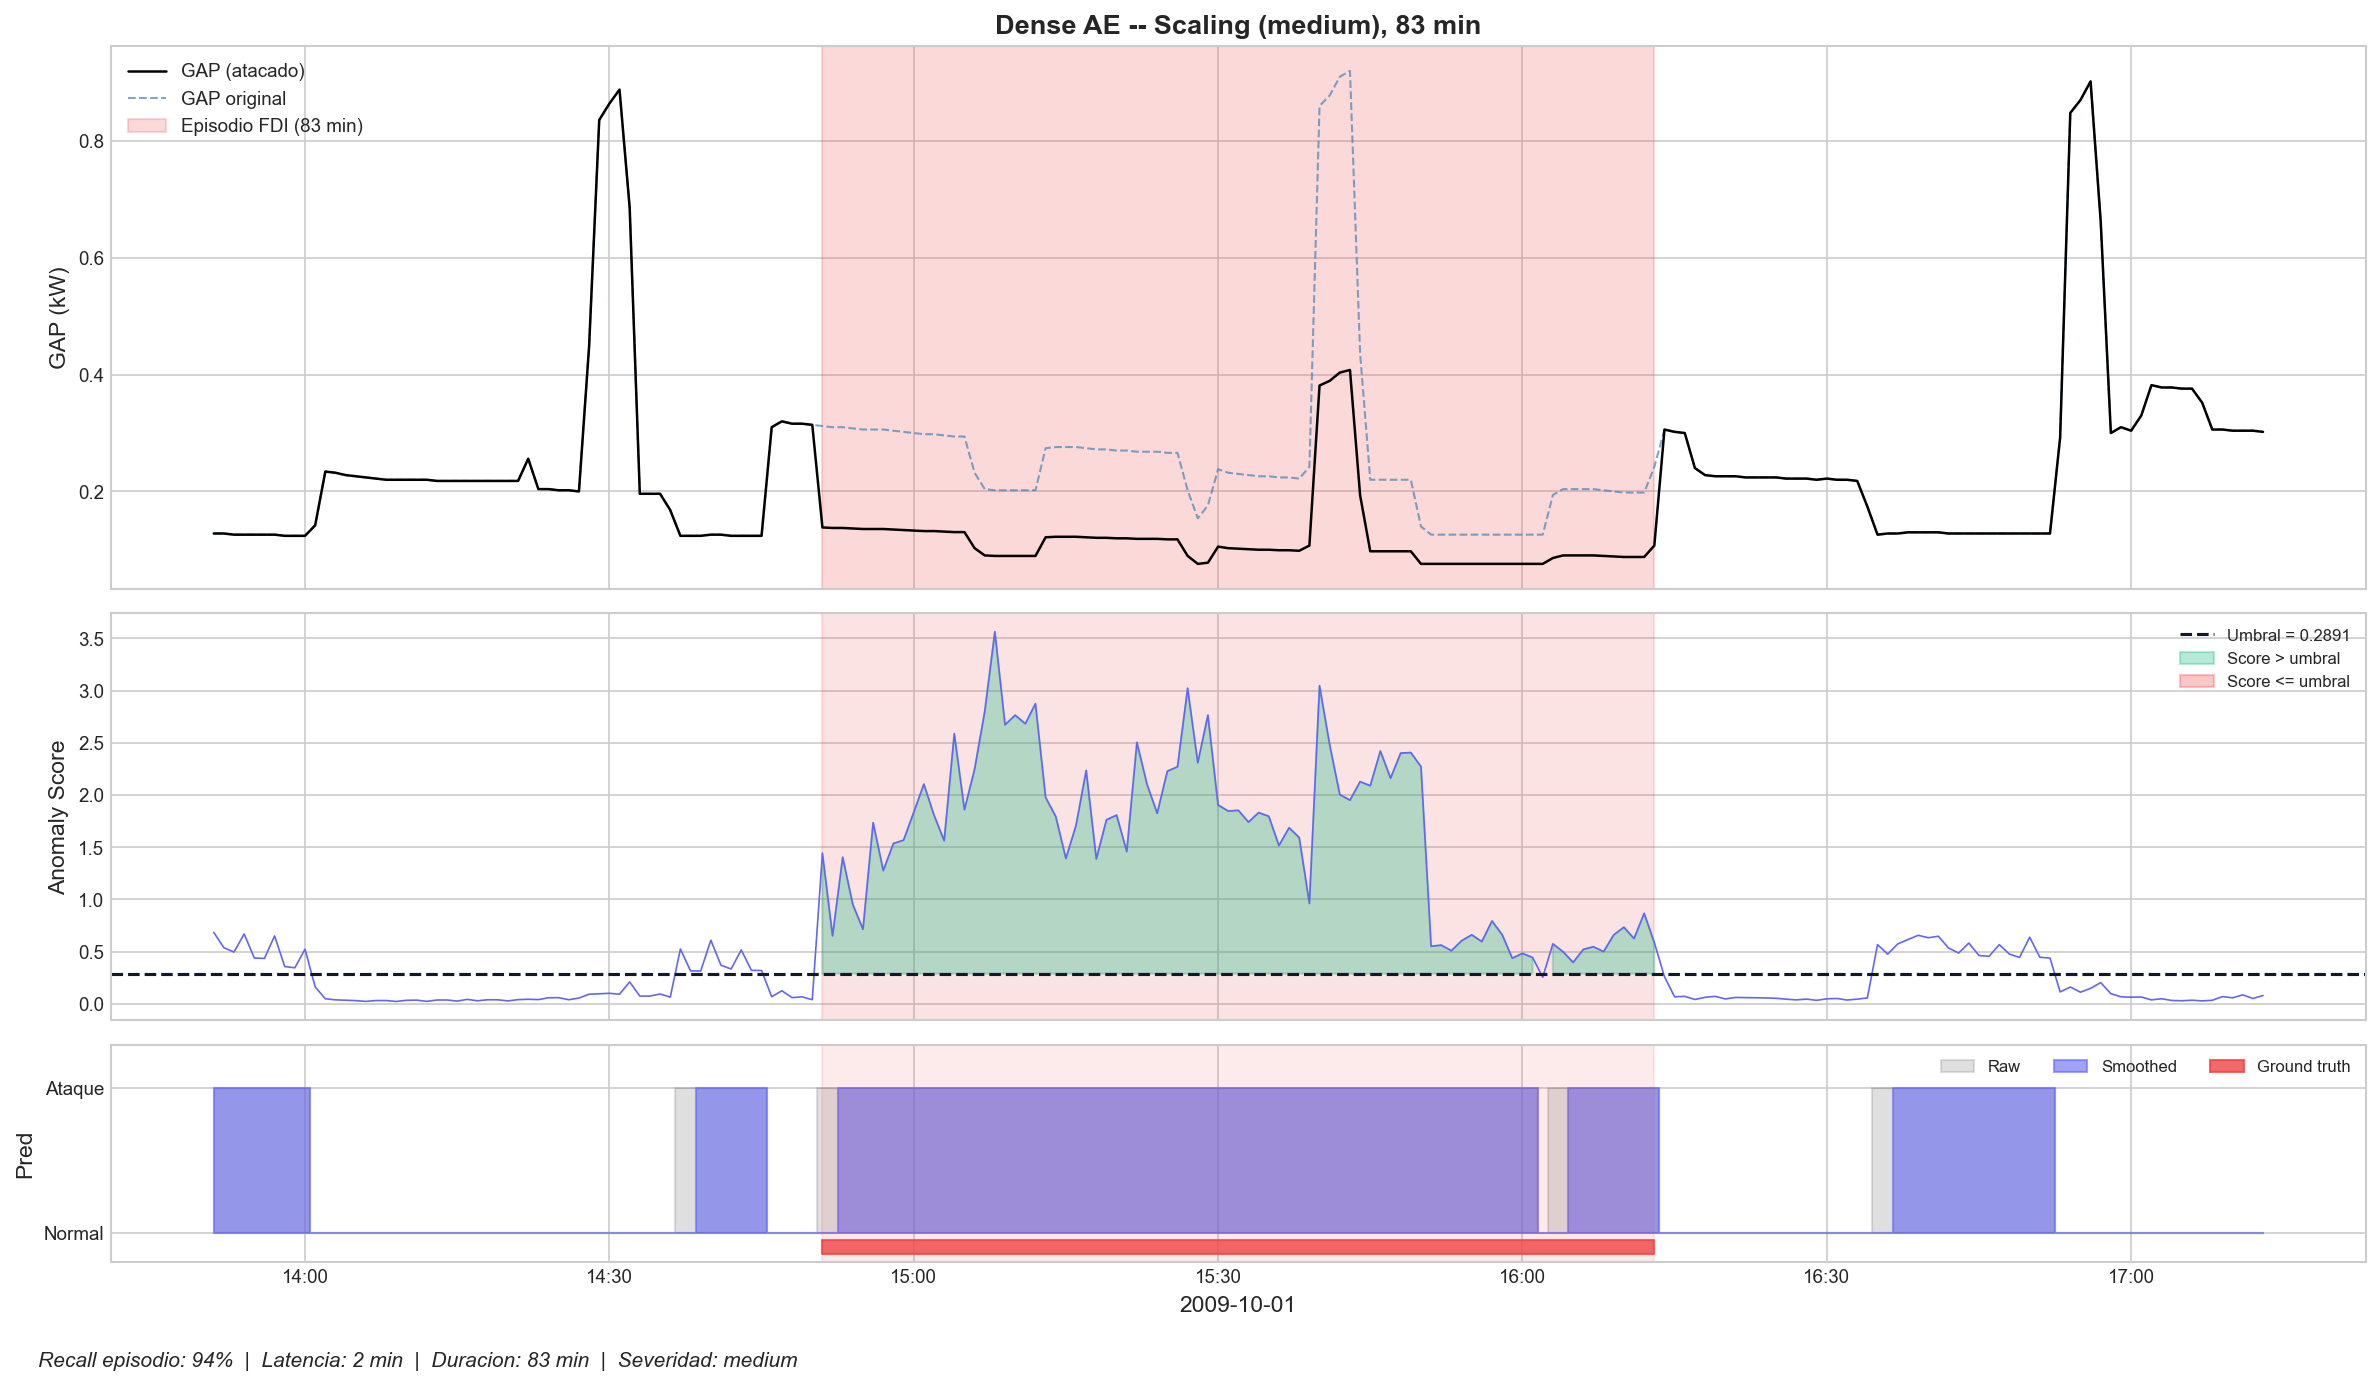


--- offset ---
  Episodio 209: medium, 130 min
  Guardado: figures/episode_offset.png


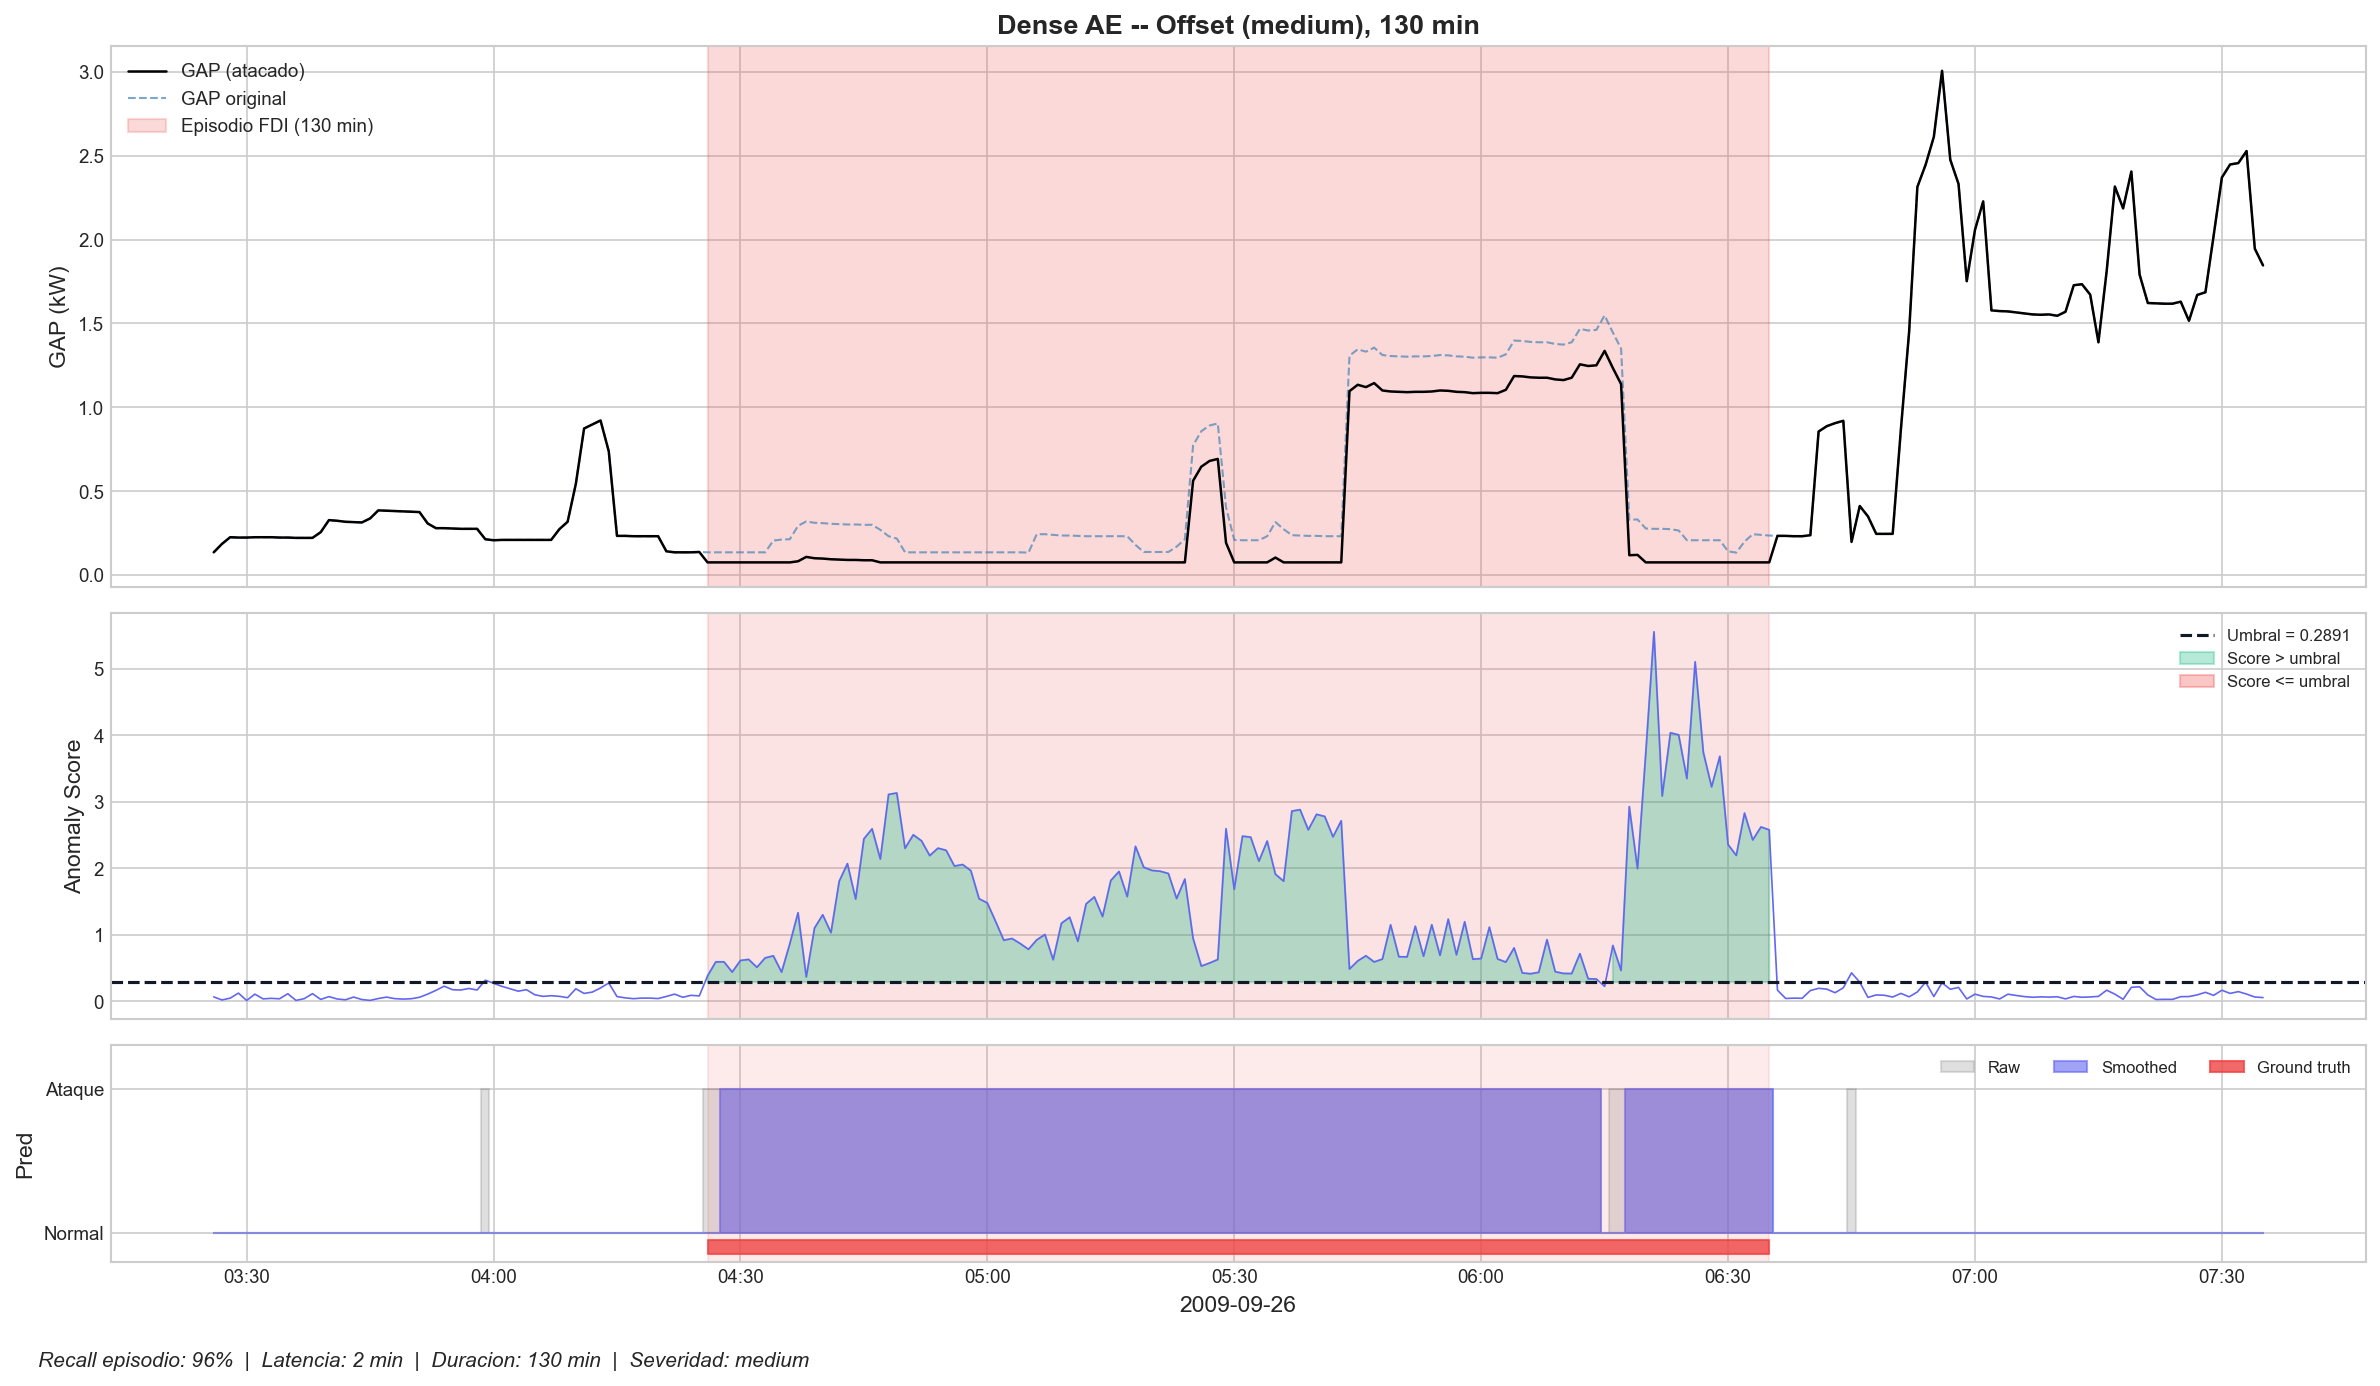


--- noise ---
  Episodio 351: medium, 169 min
  Guardado: figures/episode_noise.png


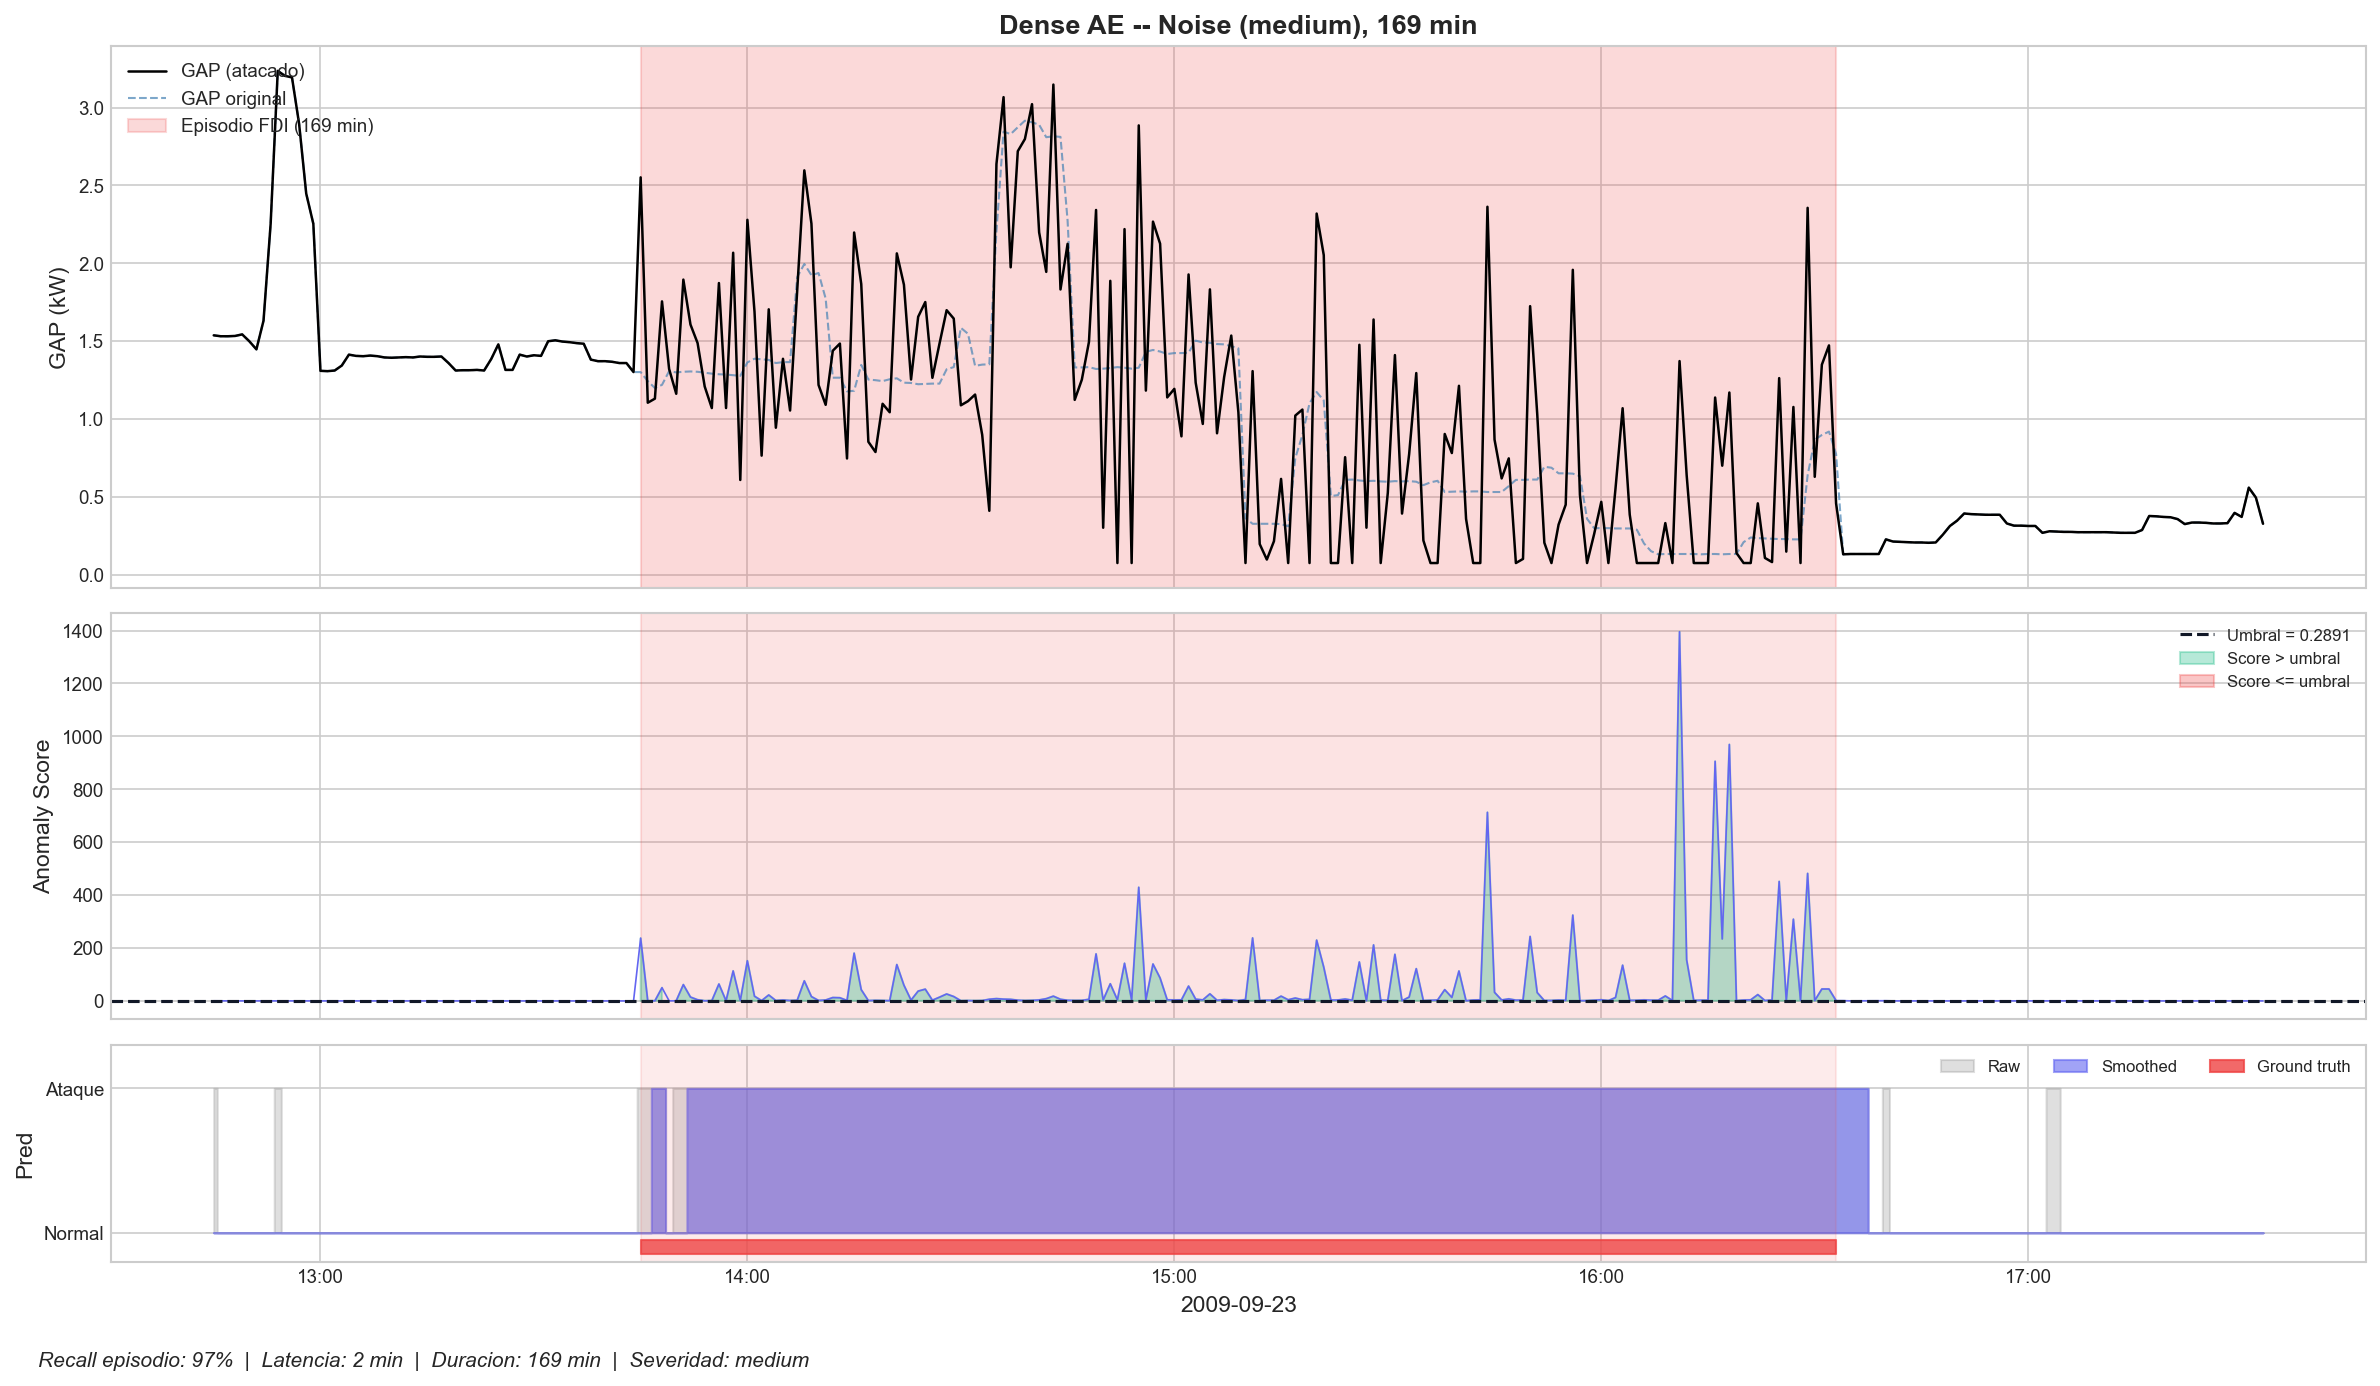


--- ramp ---
  Episodio 380: medium, 71 min
  Guardado: figures/episode_ramp.png


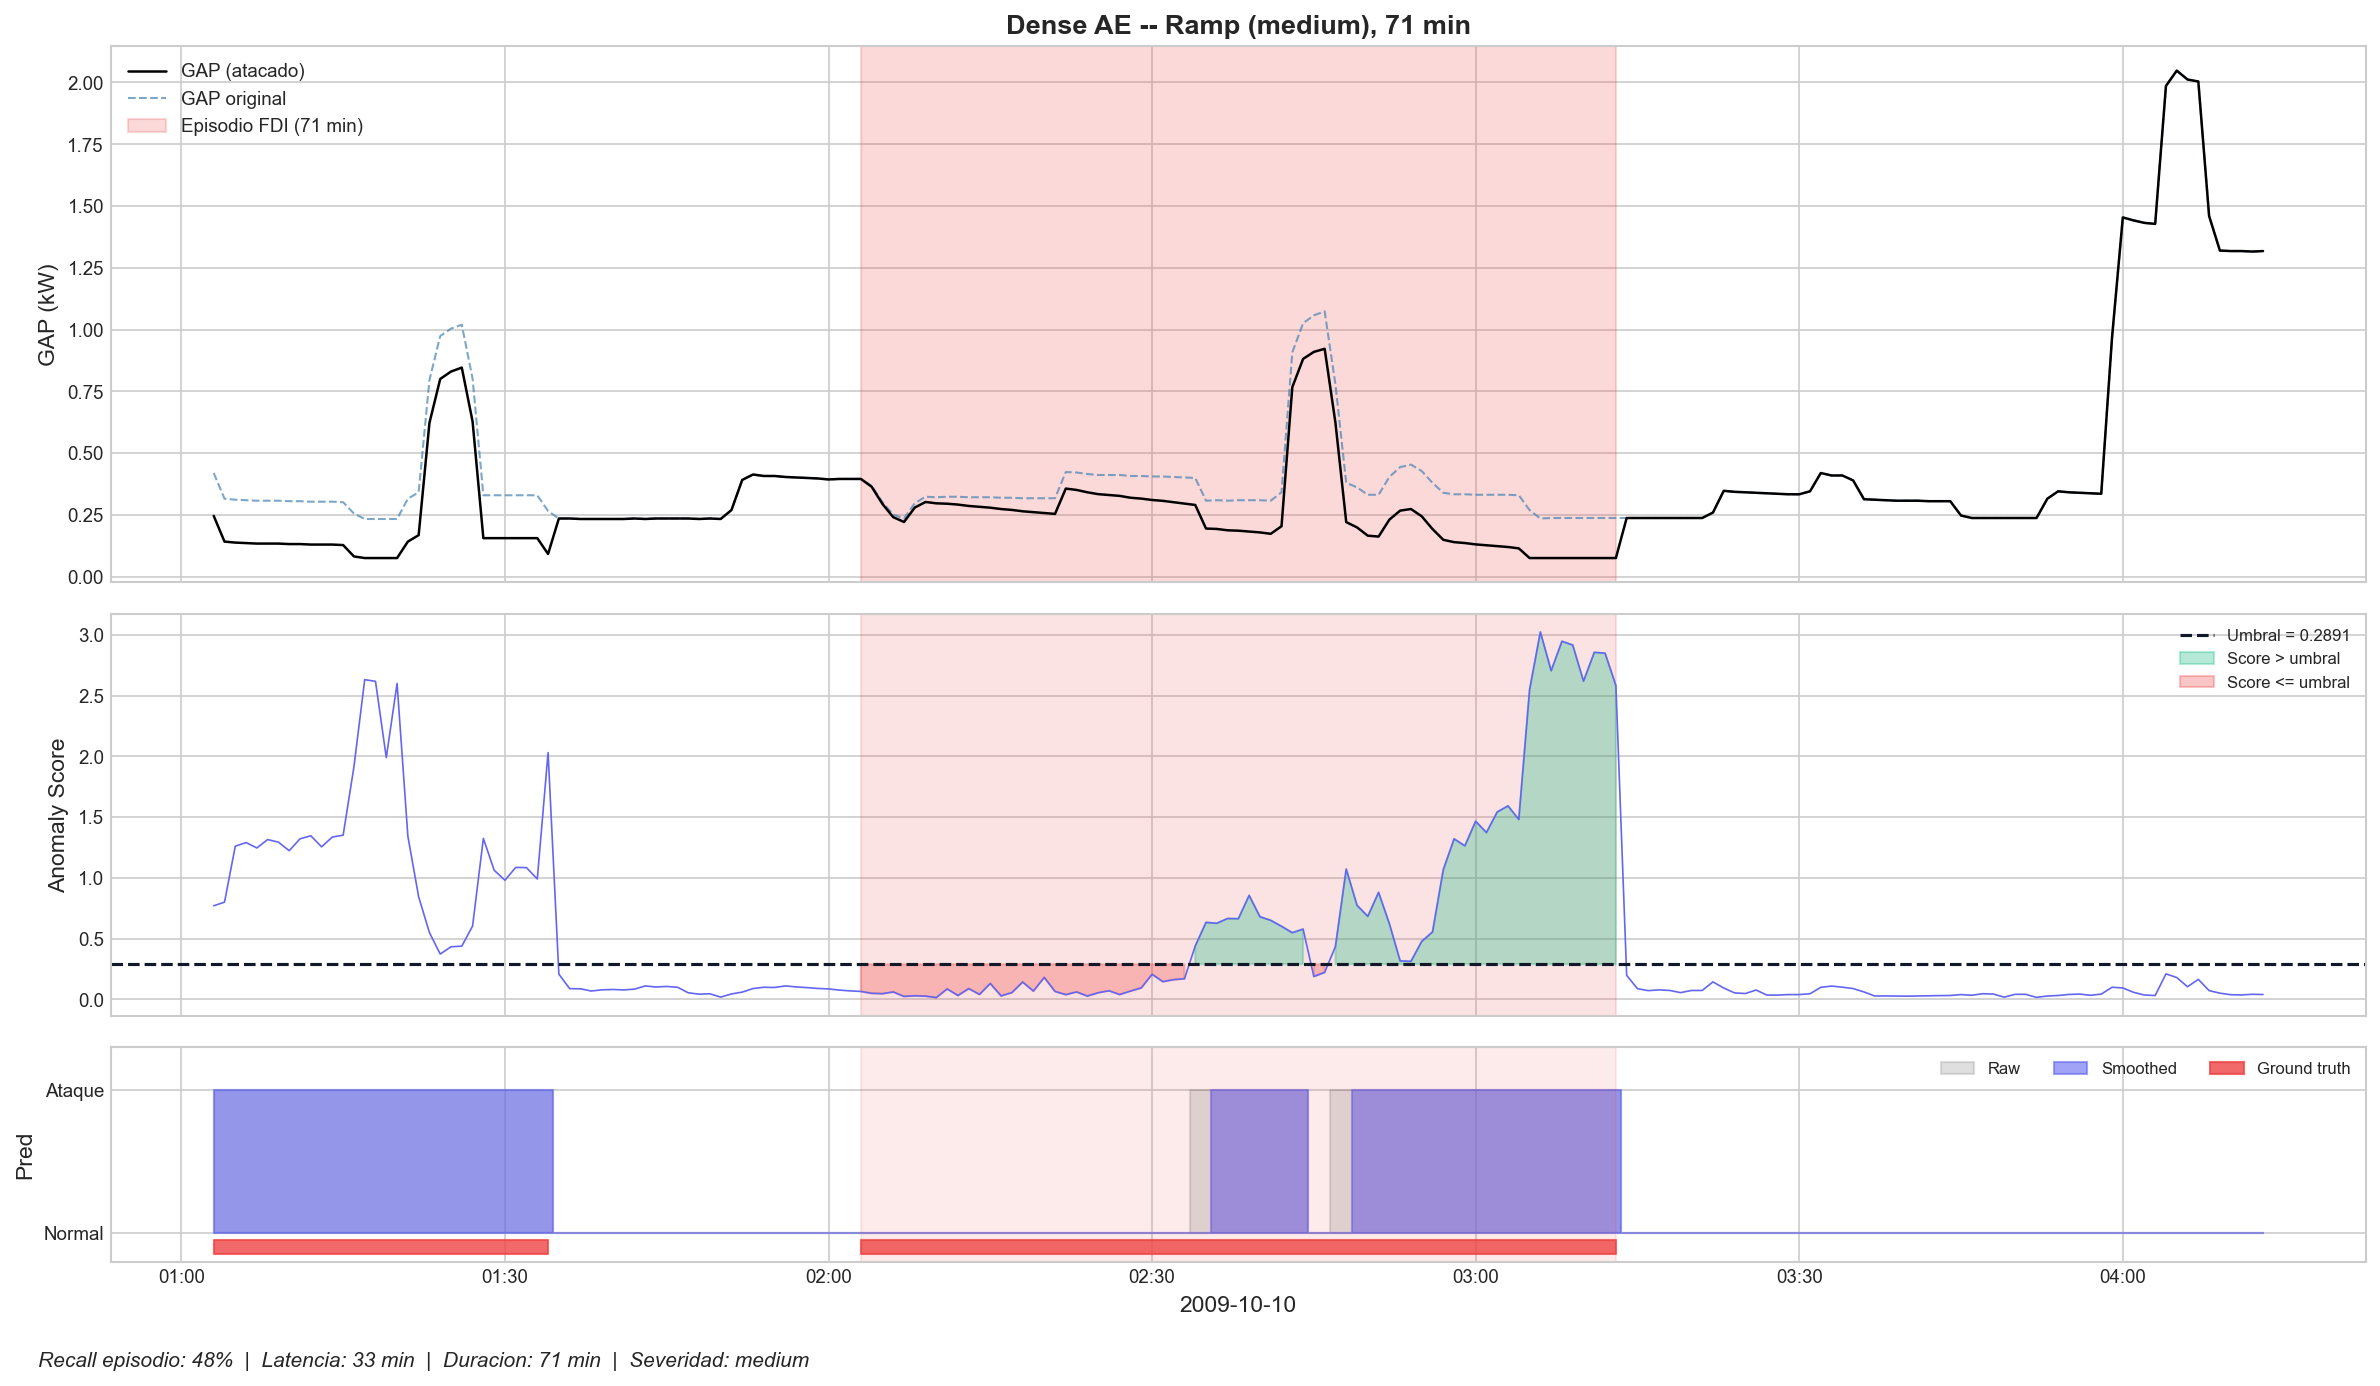


--- step ---
  Episodio 543: medium, 95 min
  Guardado: figures/episode_step.png


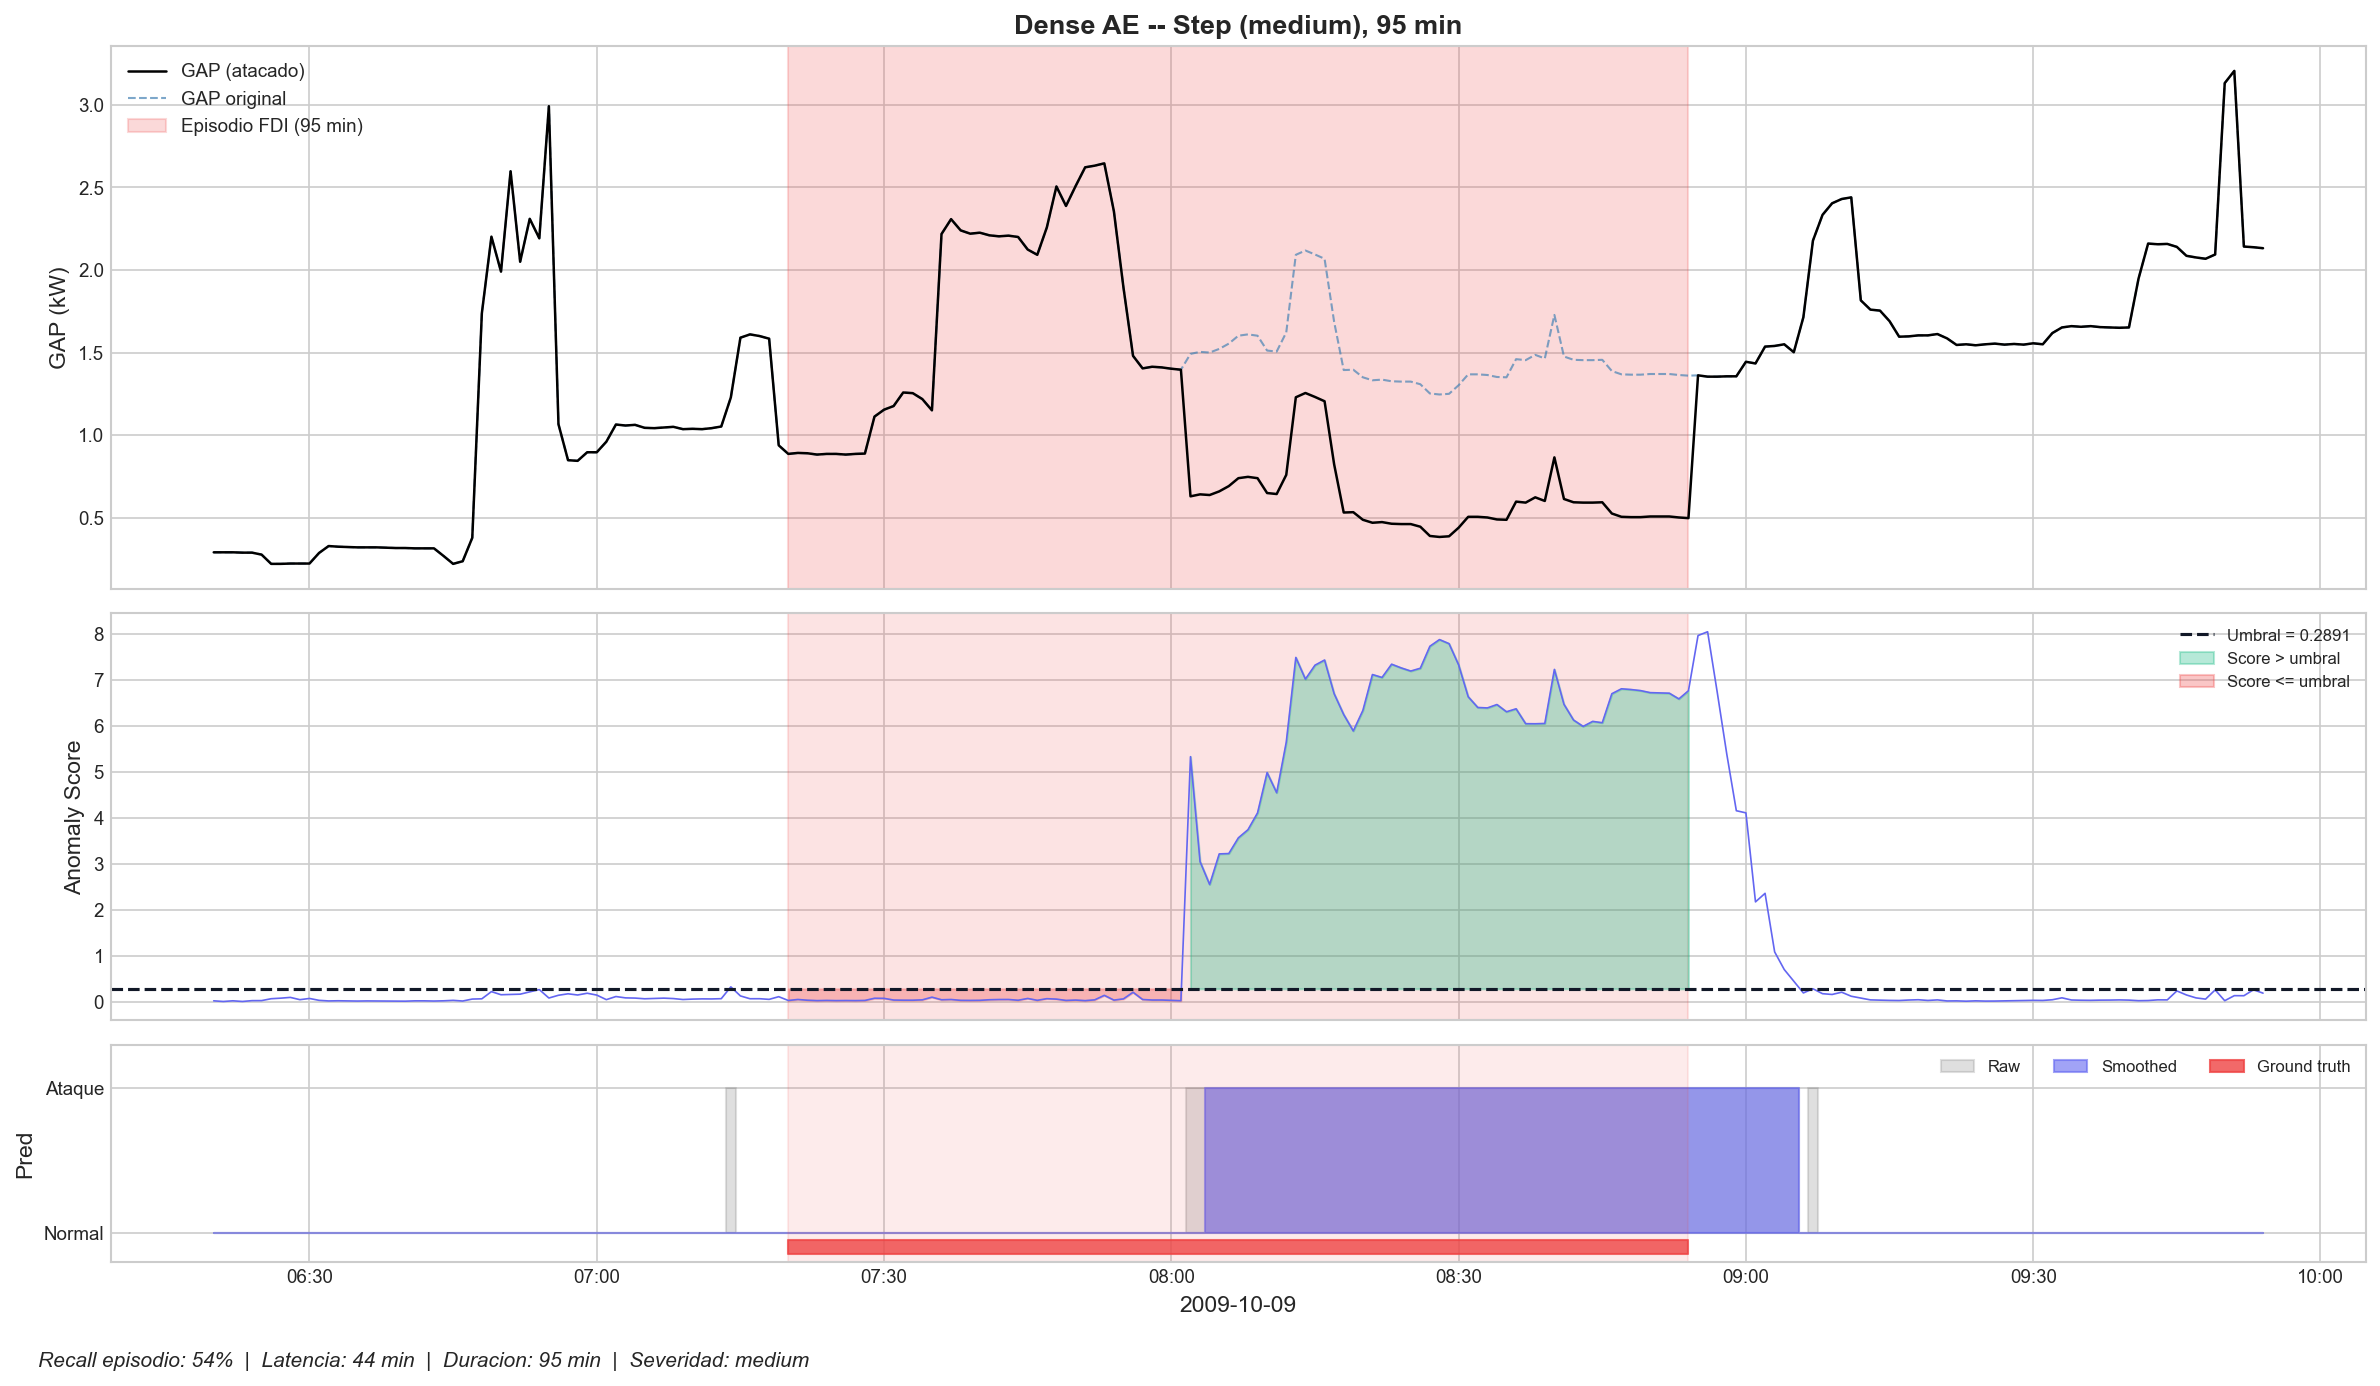


--- replay ---
  Episodio 604: medium, 92 min
  Guardado: figures/episode_replay.png


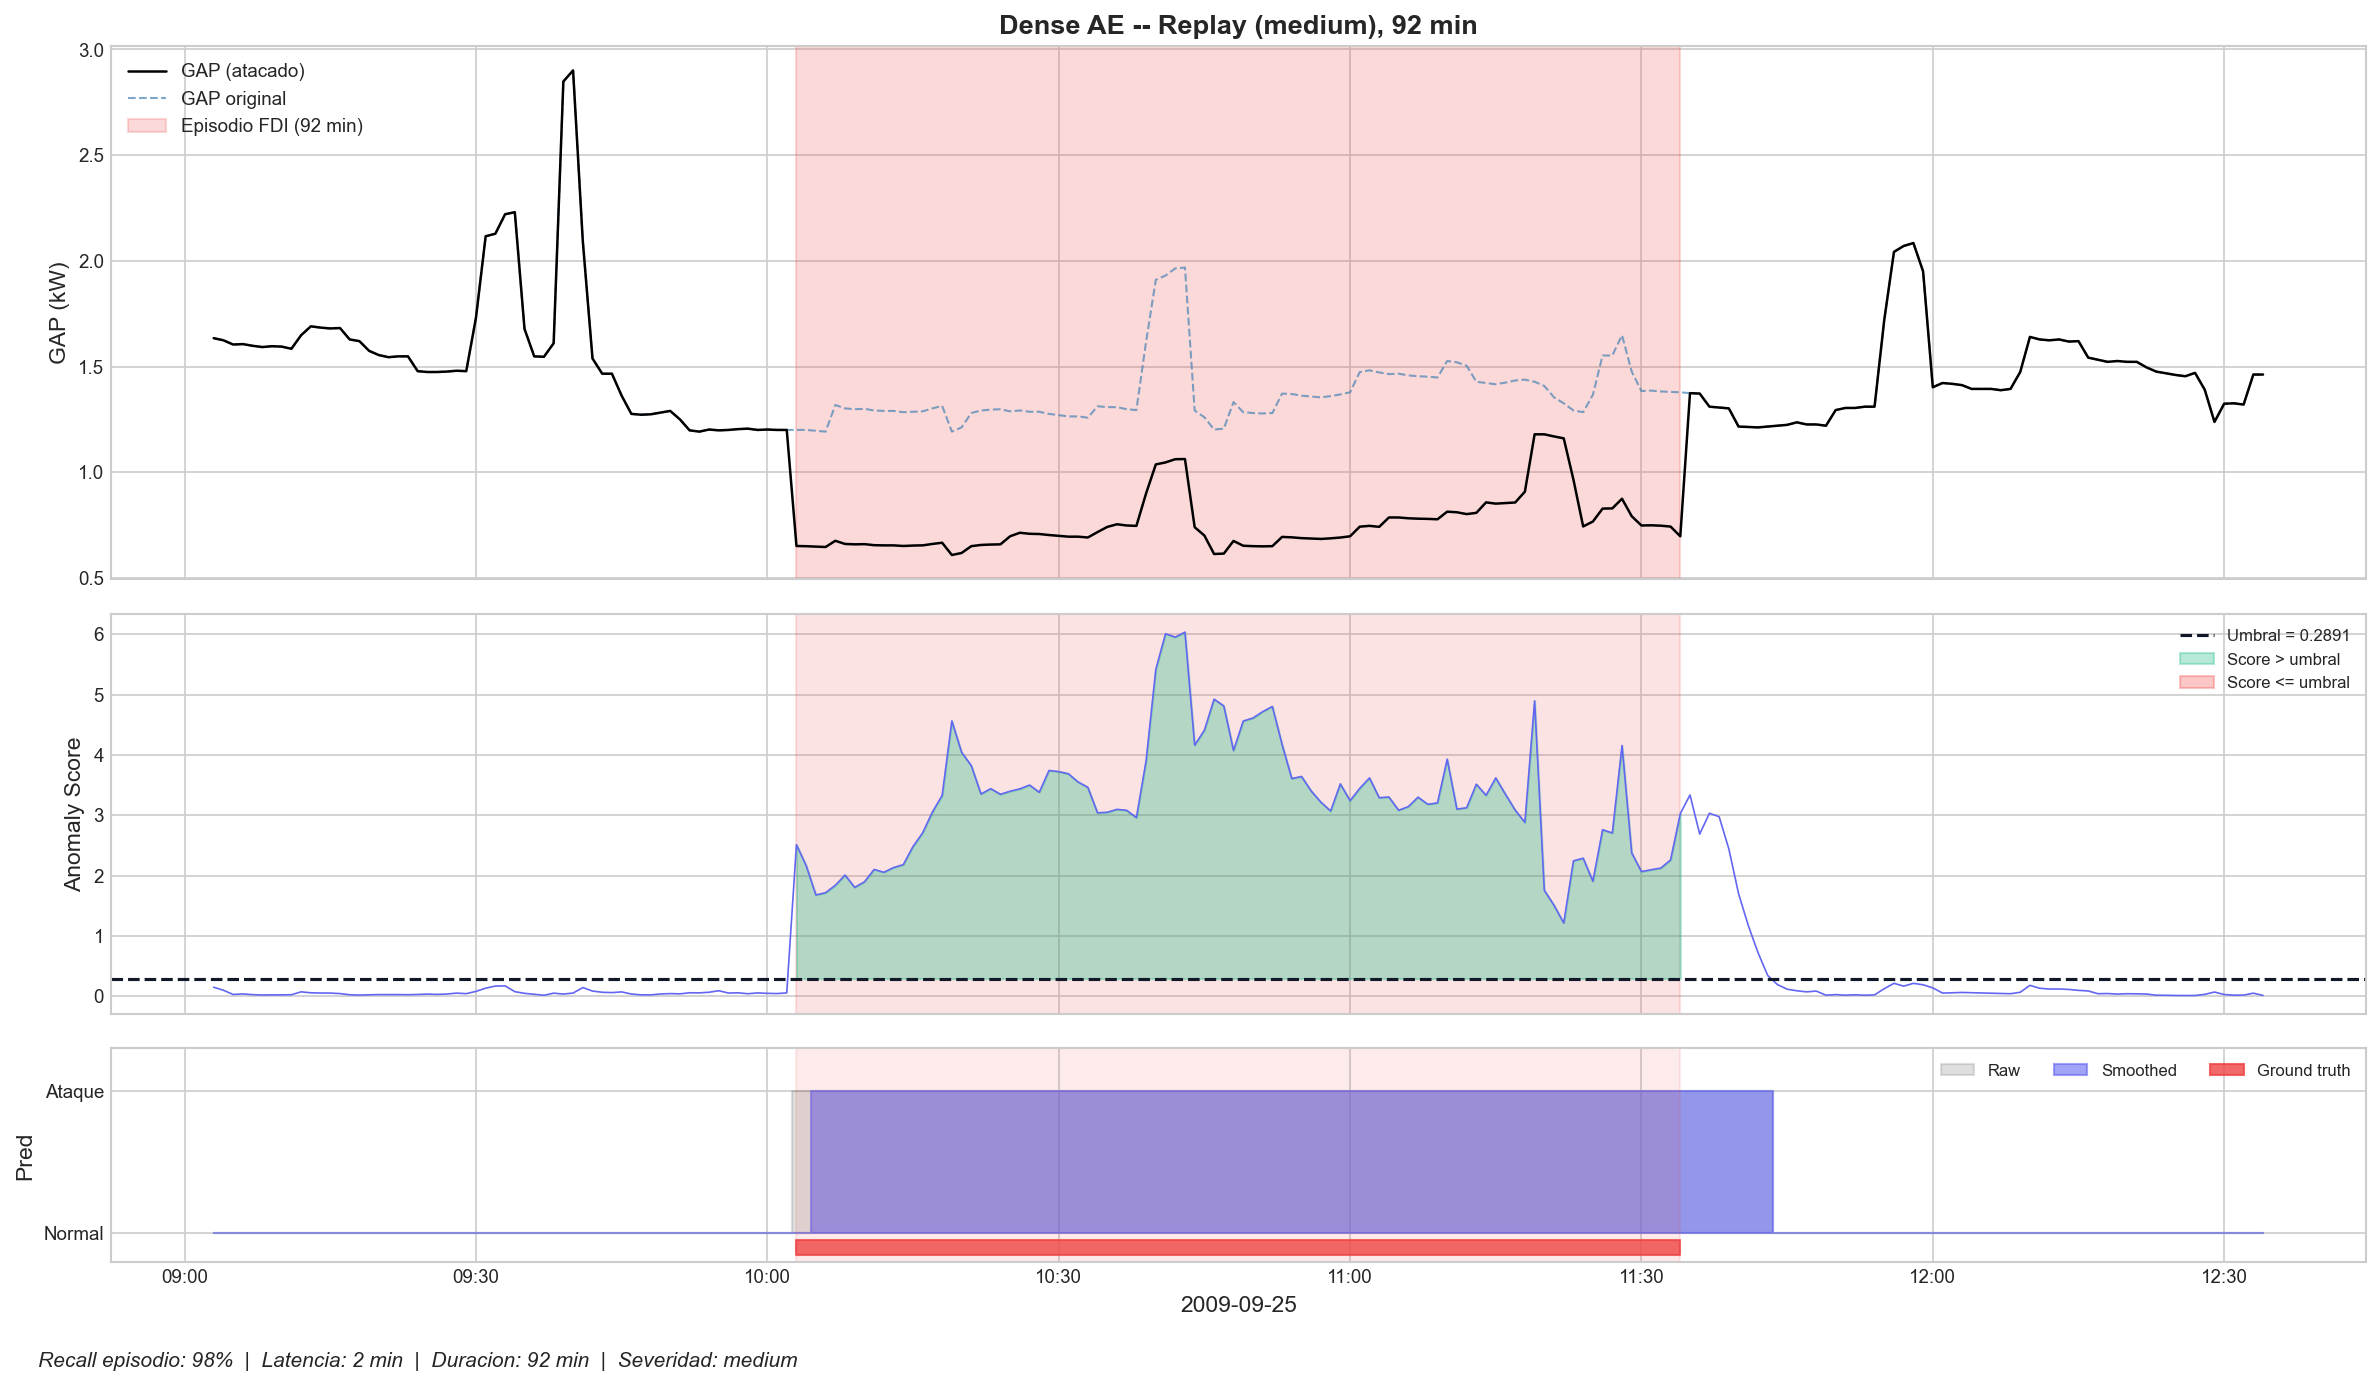


--- voltage_spoof ---
  Episodio 788: medium, 65 min
  Guardado: figures/episode_voltage_spoof.png


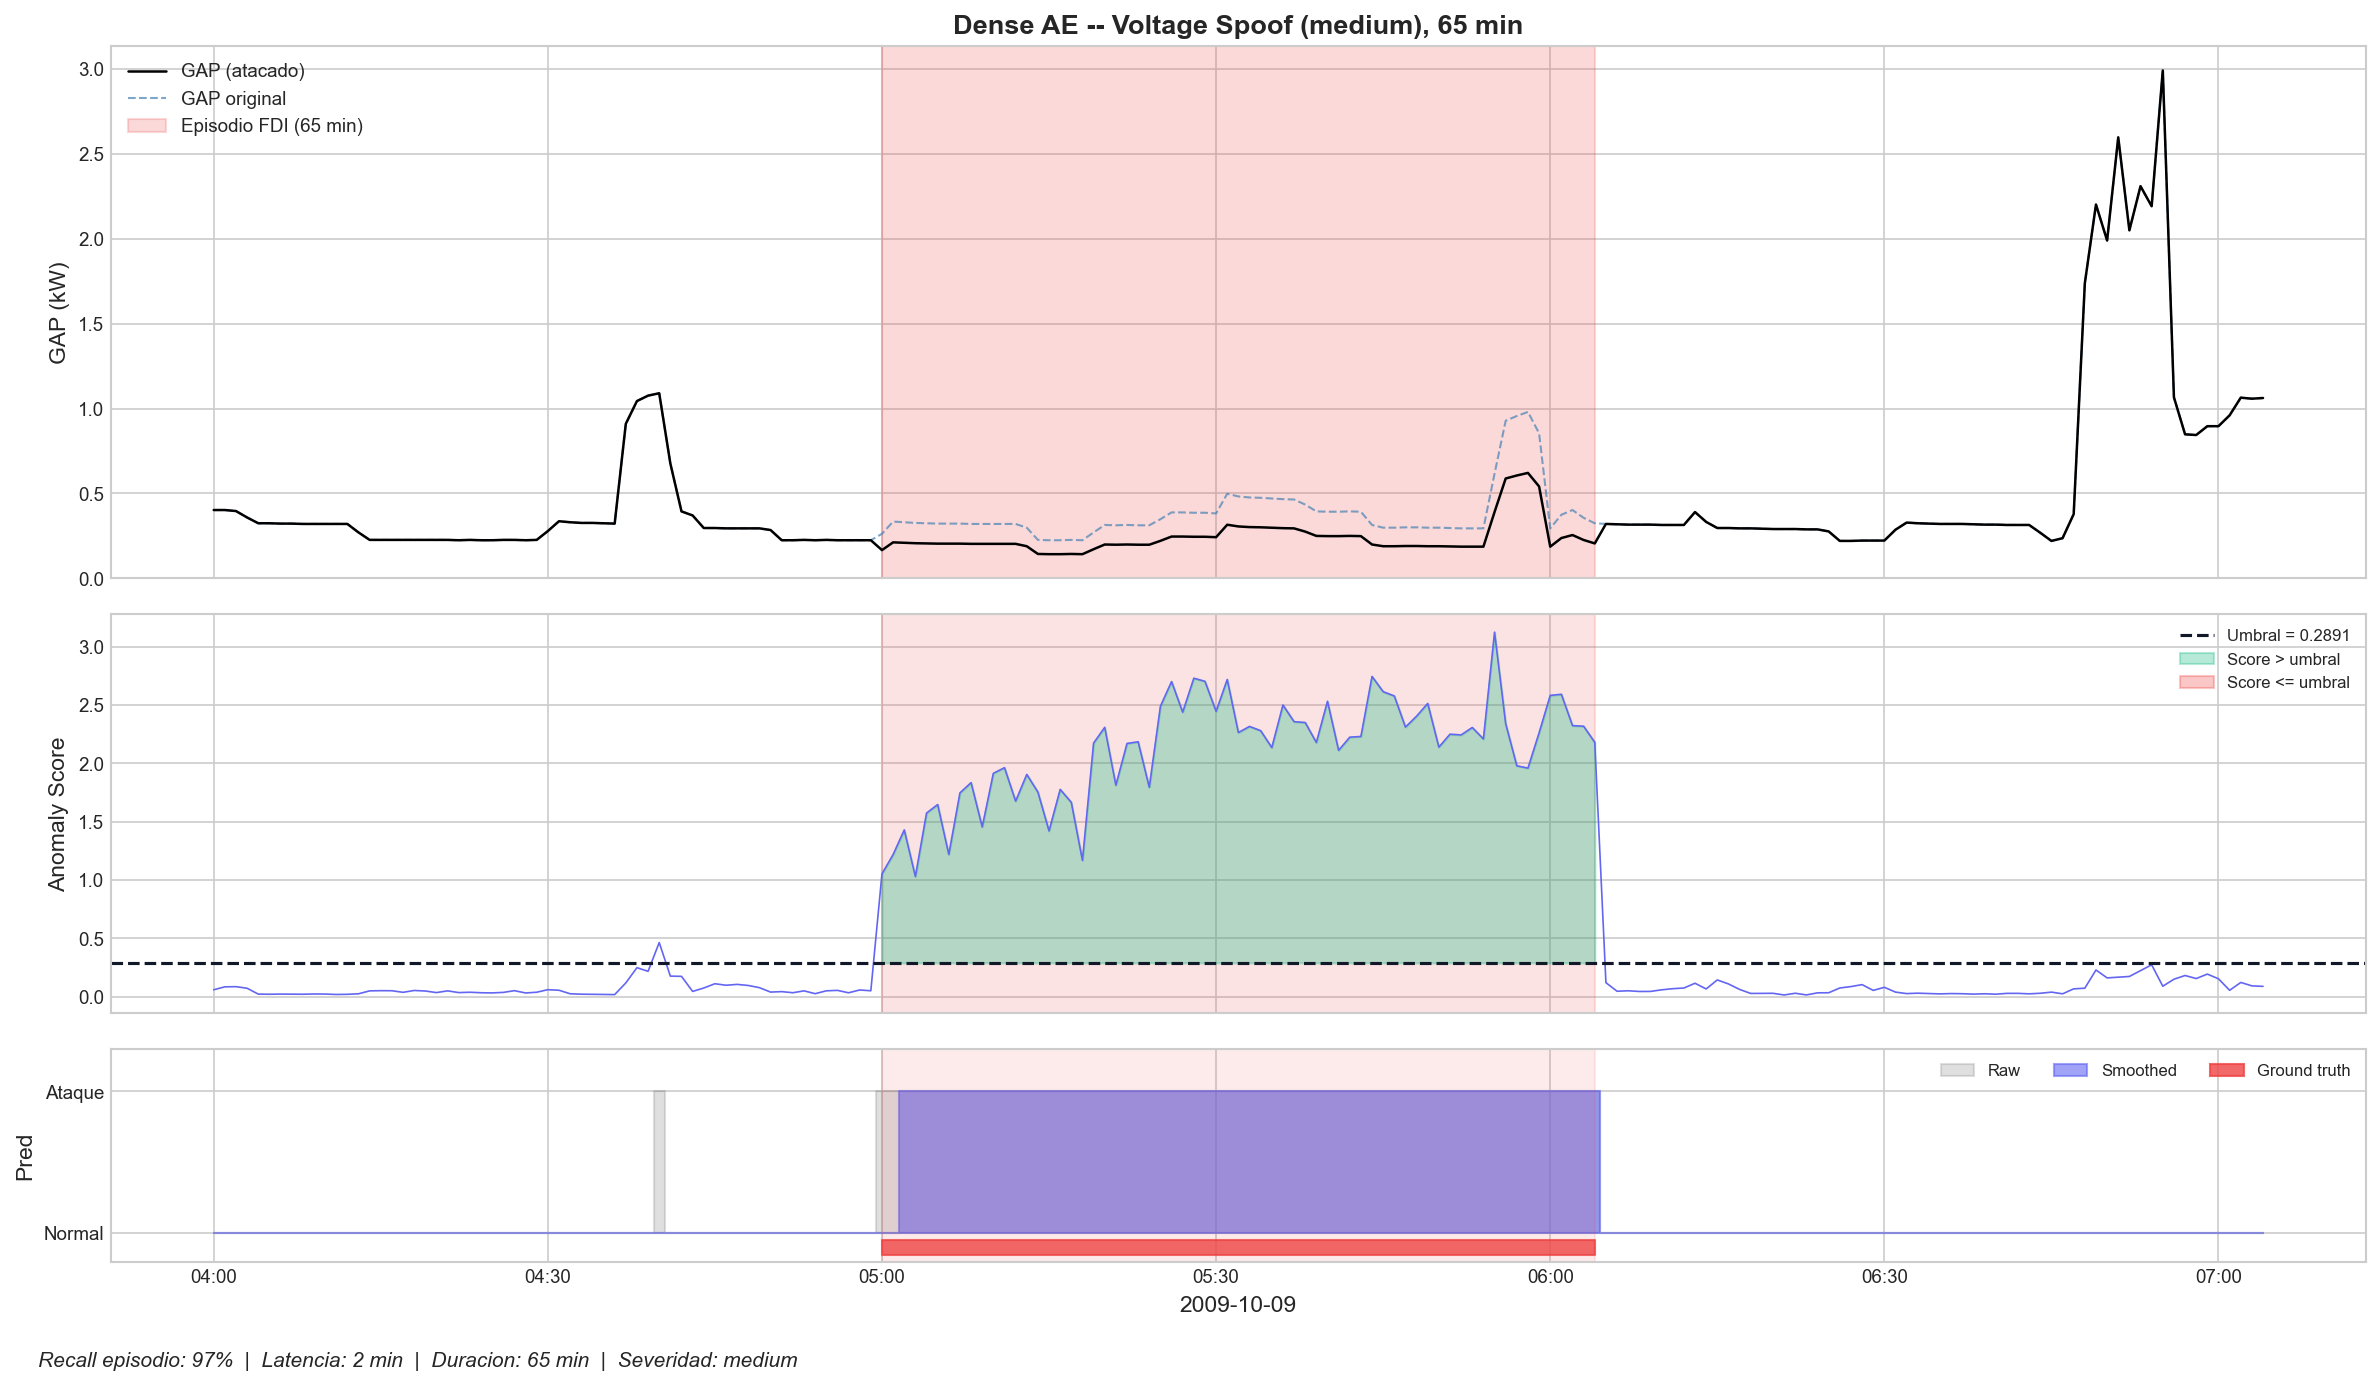

In [7]:
# ── Seleccionar mejor modelo por F1 ──

best_model_name = max(MODELS, key=lambda m: MODELS[m]['metrics']['f1'])

best = MODELS[best_model_name]

print(f'Mejor modelo: {best_model_name} (F1={best["metrics"]["f1"]:.4f})')

print()


# ── Para cada tipo de ataque, buscar un episodio representativo ──

# Preferimos: (1) severity=medium, (2) detectado por el modelo, (3) duracion media

df_best = best['preds']


for attack_type in ATTACK_TYPES:

    print(f'\n--- {attack_type} ---')

    

    # Filtrar episodios de este tipo

    ep_mask = (df_best['attack_type'] == attack_type) & (df_best['episode_id'] >= 0)

    if not ep_mask.any():

        print(f'  Sin episodios de tipo {attack_type}')

        continue

    

    ep_ids = df_best.loc[ep_mask, 'episode_id'].unique()

    

    # Buscar uno medium detectado

    selected_ep = None

    for ep_id in ep_ids:

        ep = df_best[df_best['episode_id'] == ep_id]

        sev = ep['severity'].iloc[0]

        detected = ep[best['smooth_col']].values.astype(int).any()

        

        if sev == 'medium' and detected:

            selected_ep = ep_id

            break

    

    # Fallback: cualquier episodio detectado

    if selected_ep is None:

        for ep_id in ep_ids:

            ep = df_best[df_best['episode_id'] == ep_id]

            if ep[best['smooth_col']].values.astype(int).any():

                selected_ep = ep_id

                break

    

    # Fallback: primer episodio

    if selected_ep is None:

        selected_ep = ep_ids[0]

    

    ep = df_best[df_best['episode_id'] == selected_ep]

    print(f'  Episodio {selected_ep}: {ep["severity"].iloc[0]}, {len(ep)} min')

    

    safe_type = attack_type.lower().replace(' ', '_')

    save_path = os.path.join(FIGURES_DIR, f'episode_{safe_type}.png')

    

    plot_episode(

        df_preds=df_best,

        episode_id=selected_ep,

        score_col=best['score_col'],

        raw_col=best['raw_col'],

        smooth_col=best['smooth_col'],

        threshold=best['threshold'],

        model_name=best_model_name,

        save_path=save_path,

    )

## 7. Grid Compacto -- 7 Tipos de Ataque en Una Figura


Una unica figura con 7 subplots (uno por tipo de ataque) mostrando

senal original vs atacada + score. Ideal para una sola pagina del TFG.

Episodios seleccionados: 7 tipos
Guardado: figures/episode_grid_7_types.png


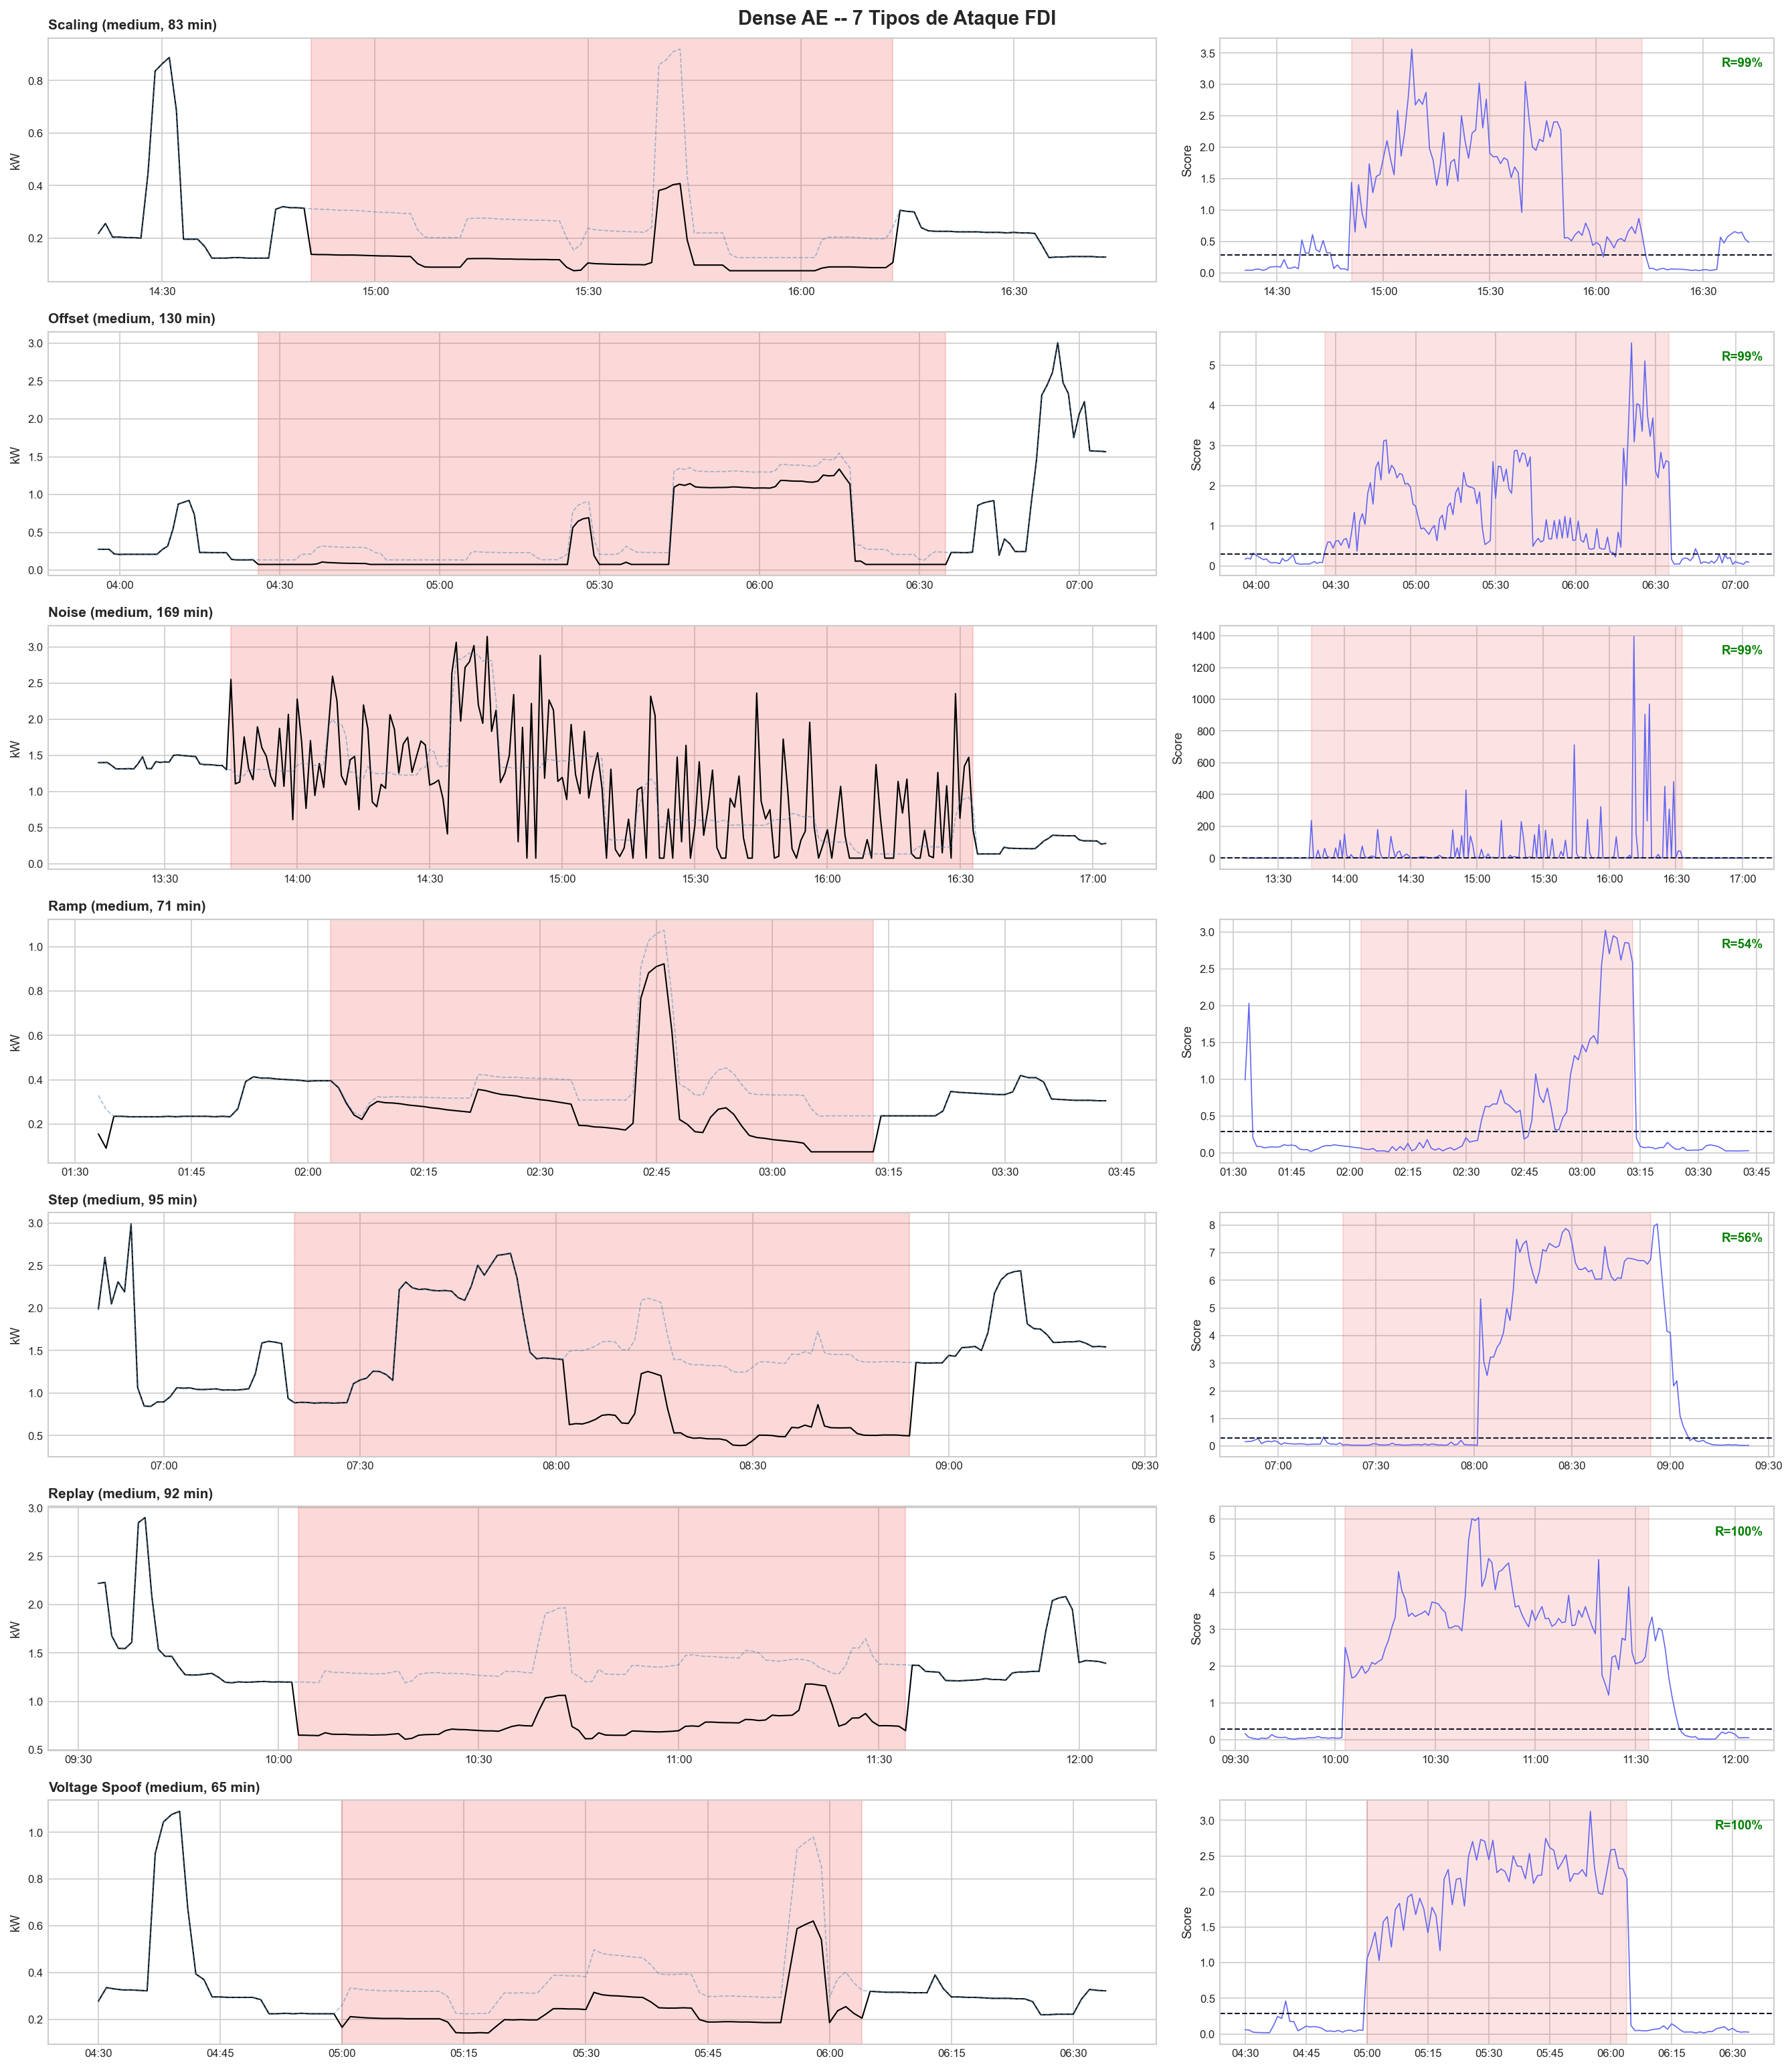

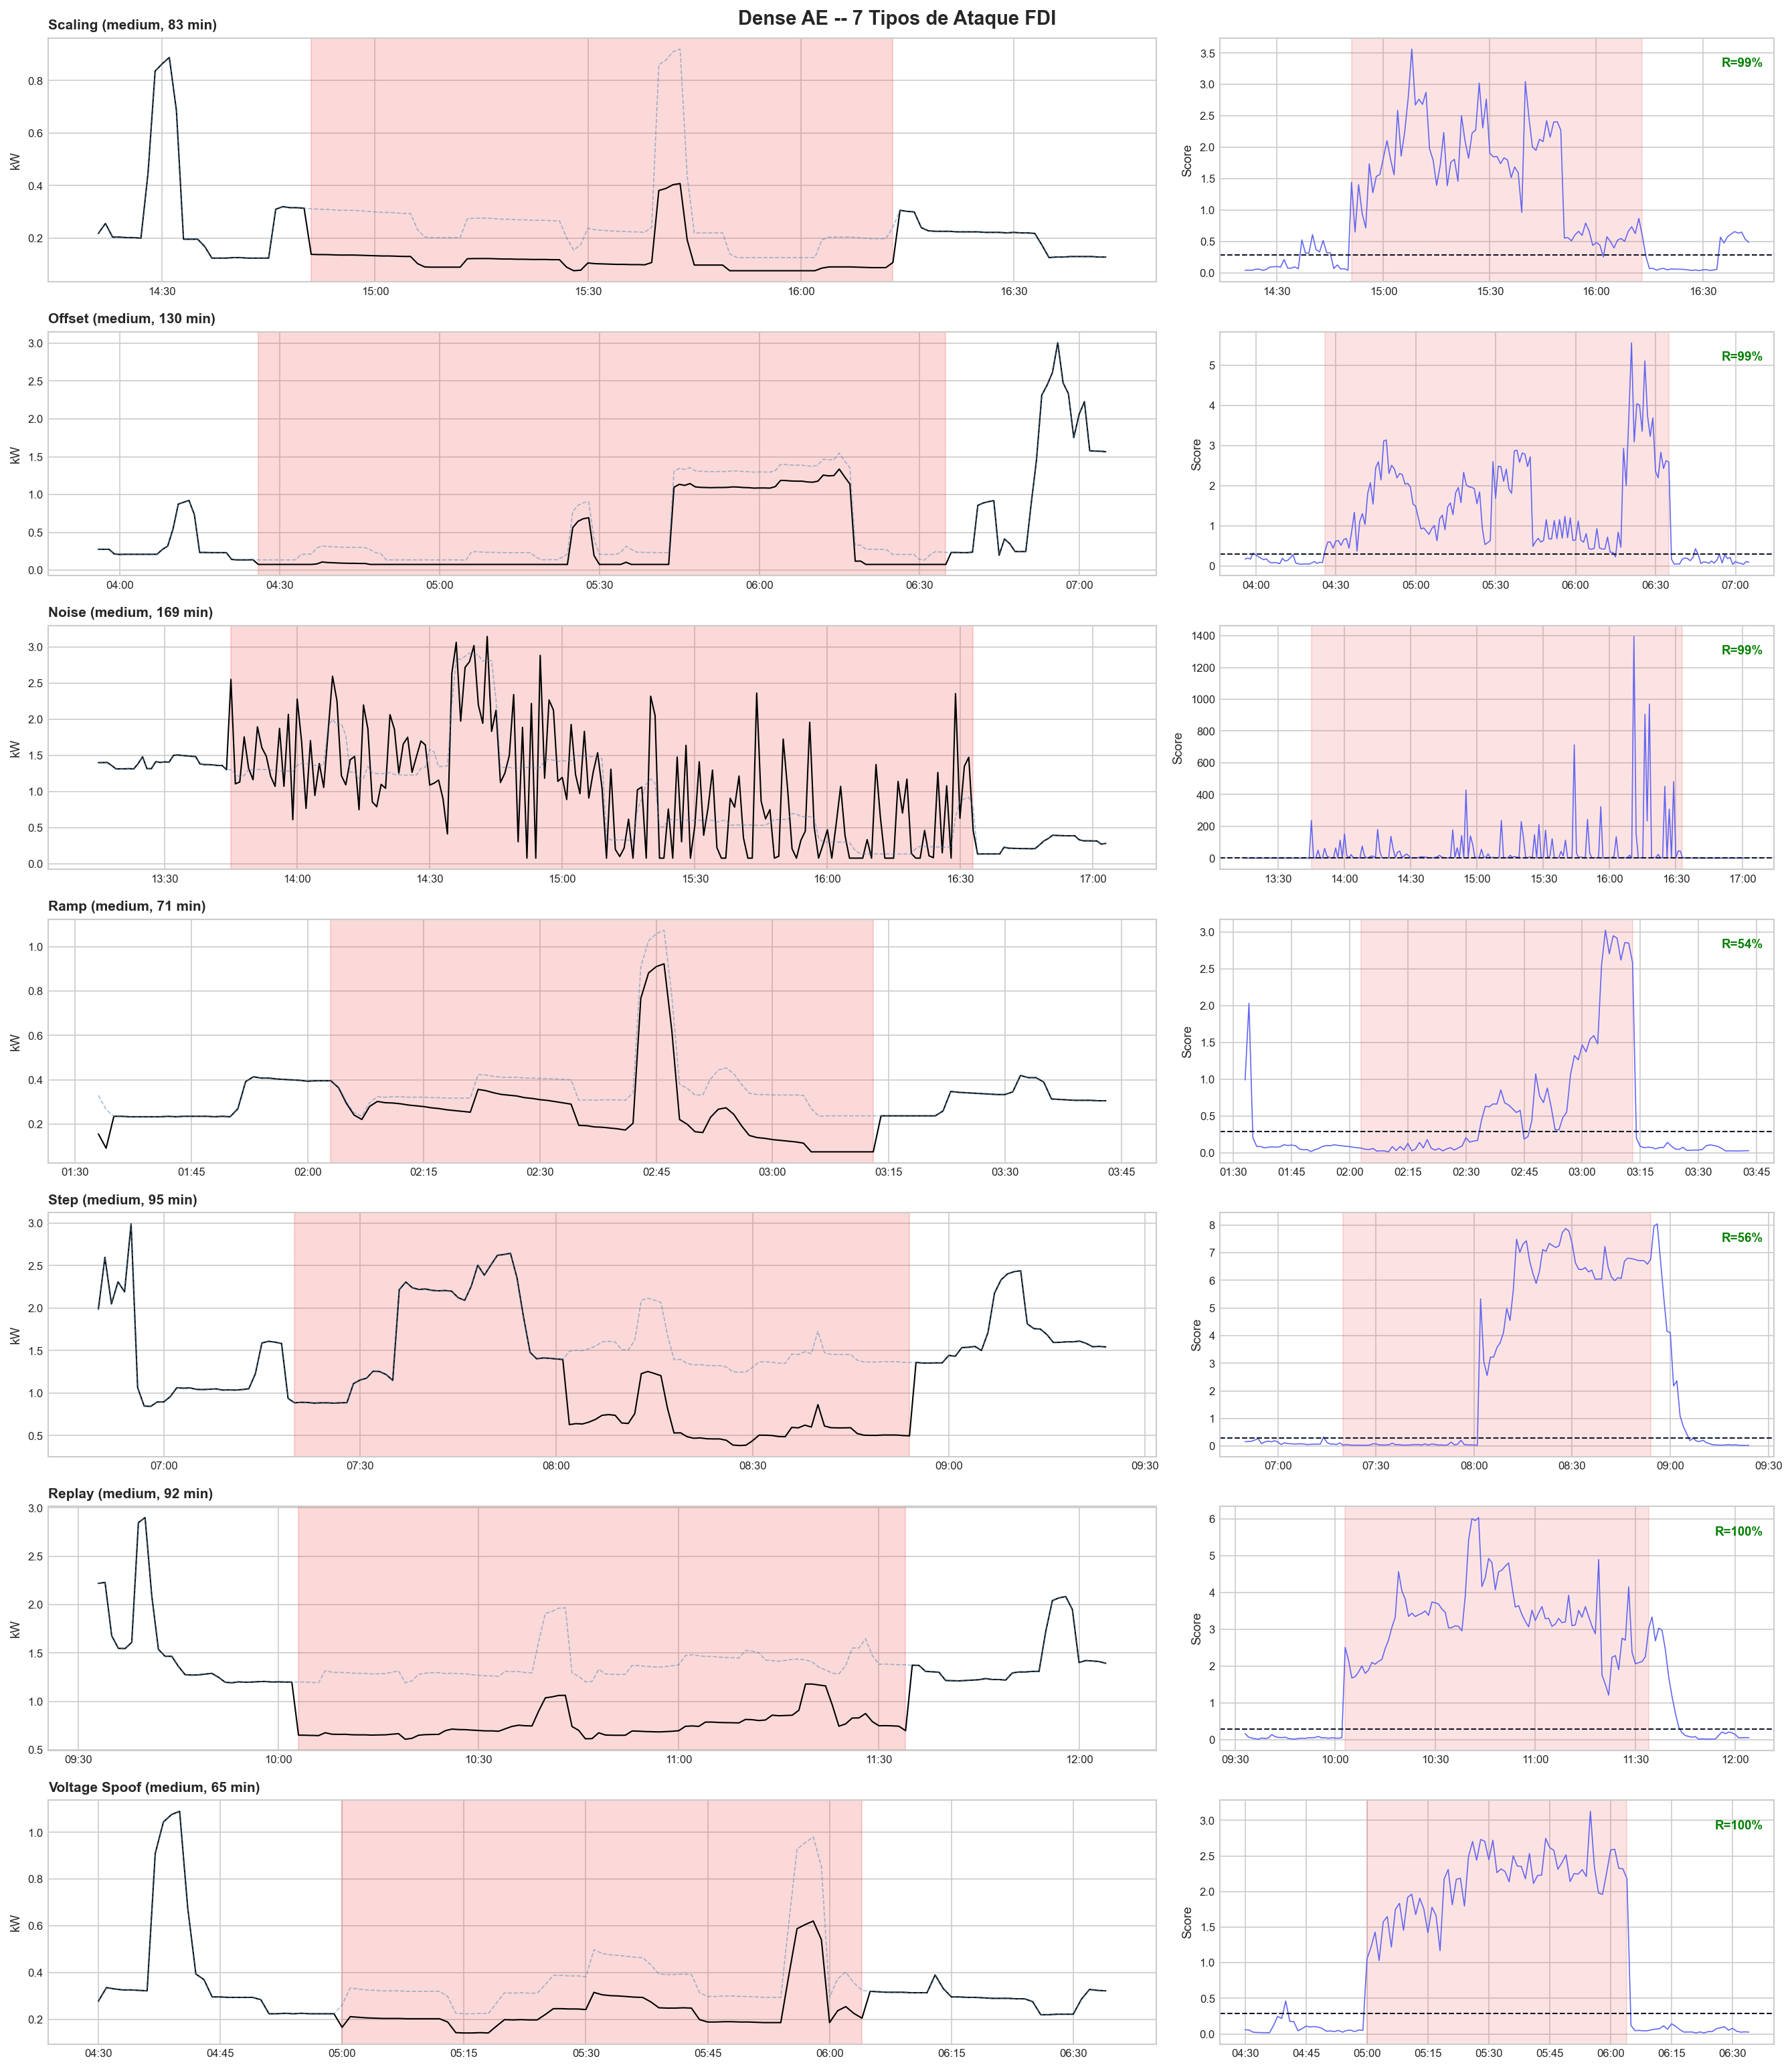

In [8]:
def plot_episode_grid(df_preds, episode_ids, score_col, threshold,

                     model_name, attack_types, save_path=None):

    '''

    Grid compacto: 7 tipos de ataque, 2 filas por tipo (senal + score).

    '''

    n_types = len(episode_ids)

    fig, axes = plt.subplots(n_types, 2, figsize=(18, 3 * n_types),

                              gridspec_kw={'width_ratios': [2, 1]})

    

    if n_types == 1:

        axes = axes.reshape(1, -1)

    

    for row, (attack_type, ep_id) in enumerate(episode_ids.items()):

        ep_mask = df_preds['episode_id'] == ep_id

        ep_data = df_preds[ep_mask]

        

        if len(ep_data) == 0:

            continue

        

        severity = ep_data['severity'].iloc[0]

        ep_start = ep_data.index[0]

        ep_end = ep_data.index[-1]

        duration = len(ep_data)

        

        # Contexto 30 min

        ctx_start = ep_start - pd.Timedelta(minutes=30)

        ctx_end = ep_end + pd.Timedelta(minutes=30)

        ctx = df_preds.loc[ctx_start:ctx_end]

        

        # ── Izquierda: senal ──

        ax = axes[row, 0]

        ax.plot(ctx.index, ctx['Global_active_power'], 'k-', lw=1)

        if 'GAP_original' in ctx.columns:

            ax.plot(ctx.index, ctx['GAP_original'], color='steelblue',

                    lw=0.8, alpha=0.5, linestyle='--')

        ax.axvspan(ep_start, ep_end, alpha=0.2, color=COLORS['attack'])

        ax.set_ylabel('kW', fontsize=9)

        type_label = attack_type.replace('_', ' ').title()

        ax.set_title(f'{type_label} ({severity}, {duration} min)',

                     fontsize=10, fontweight='bold', loc='left')

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        ax.tick_params(labelsize=8)

        

        # ── Derecha: score ──

        ax = axes[row, 1]

        ep_ctx_scores = ctx[score_col].values

        ax.plot(ctx.index, ep_ctx_scores, color=COLORS['score'], lw=0.8)

        ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1)

        ax.axvspan(ep_start, ep_end, alpha=0.15, color=COLORS['attack'])

        

        # Recall del episodio

        ep_smooth = ep_data[score_col].values > threshold

        recall_ep = ep_smooth.sum() / max(len(ep_smooth), 1)

        ax.text(0.98, 0.92, f'R={recall_ep:.0%}',

                transform=ax.transAxes, fontsize=9, ha='right', va='top',

                fontweight='bold',

                color='green' if recall_ep > 0.5 else 'red')

        

        ax.set_ylabel('Score', fontsize=9)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        ax.tick_params(labelsize=8)

    

    fig.suptitle(f'{model_name} -- 7 Tipos de Ataque FDI',

                 fontsize=14, fontweight='bold')

    plt.tight_layout()

    if save_path:

        fig.savefig(save_path, dpi=300, bbox_inches='tight')

        print(f'Guardado: {save_path}')

    plt.show()

    return fig


# ── Seleccionar 1 episodio por tipo ──

episode_ids = {}

df_best = MODELS[best_model_name]['preds']


for attack_type in ATTACK_TYPES:

    ep_mask = (df_best['attack_type'] == attack_type) & (df_best['episode_id'] >= 0)

    if not ep_mask.any():

        continue

    

    ep_ids = df_best.loc[ep_mask, 'episode_id'].unique()

    

    # Buscar medium detectado

    selected = ep_ids[0]

    for ep_id in ep_ids:

        ep = df_best[df_best['episode_id'] == ep_id]

        if ep['severity'].iloc[0] == 'medium':

            selected = ep_id

            break

    

    episode_ids[attack_type] = selected


print(f'Episodios seleccionados: {len(episode_ids)} tipos')


plot_episode_grid(

    df_preds=df_best,

    episode_ids=episode_ids,

    score_col=MODELS[best_model_name]['score_col'],

    threshold=MODELS[best_model_name]['threshold'],

    model_name=best_model_name,

    attack_types=ATTACK_TYPES,

    save_path=os.path.join(FIGURES_DIR, 'episode_grid_7_types.png'),

)

## 8. Tabla Comparativa Consolidada


Resumen final de los 4 modelos para incluir directamente en la memoria.

TABLA COMPARATIVA -- 4 MODELOS DE DETECCION DE ANOMALIAS

  Modelo              F1     F2   Prec    Rec  AUC-ROC  AUC-PR     KB      ms   W,K
  ------------------------------------------------------------------------------------------
  IF              0.7433 0.7485 0.7348 0.7520   0.9242  0.7586 3493.5   0.005 3,  2
  K-Means+IF      0.7684 0.7682 0.7688 0.7680   0.9270  0.7644 17425.4  0.0082 5,  3
  Dense AE        0.8157 0.8090 0.8273 0.8045   0.9317  0.8553  134.0  0.0009 3,  3 *
  LSTM AE         0.6514 0.7877 0.5055 0.9155   0.9427  0.8968  736.8  0.0032 21, 21

  * = mejor F1

Guardado: figures/comparison_4_models.png


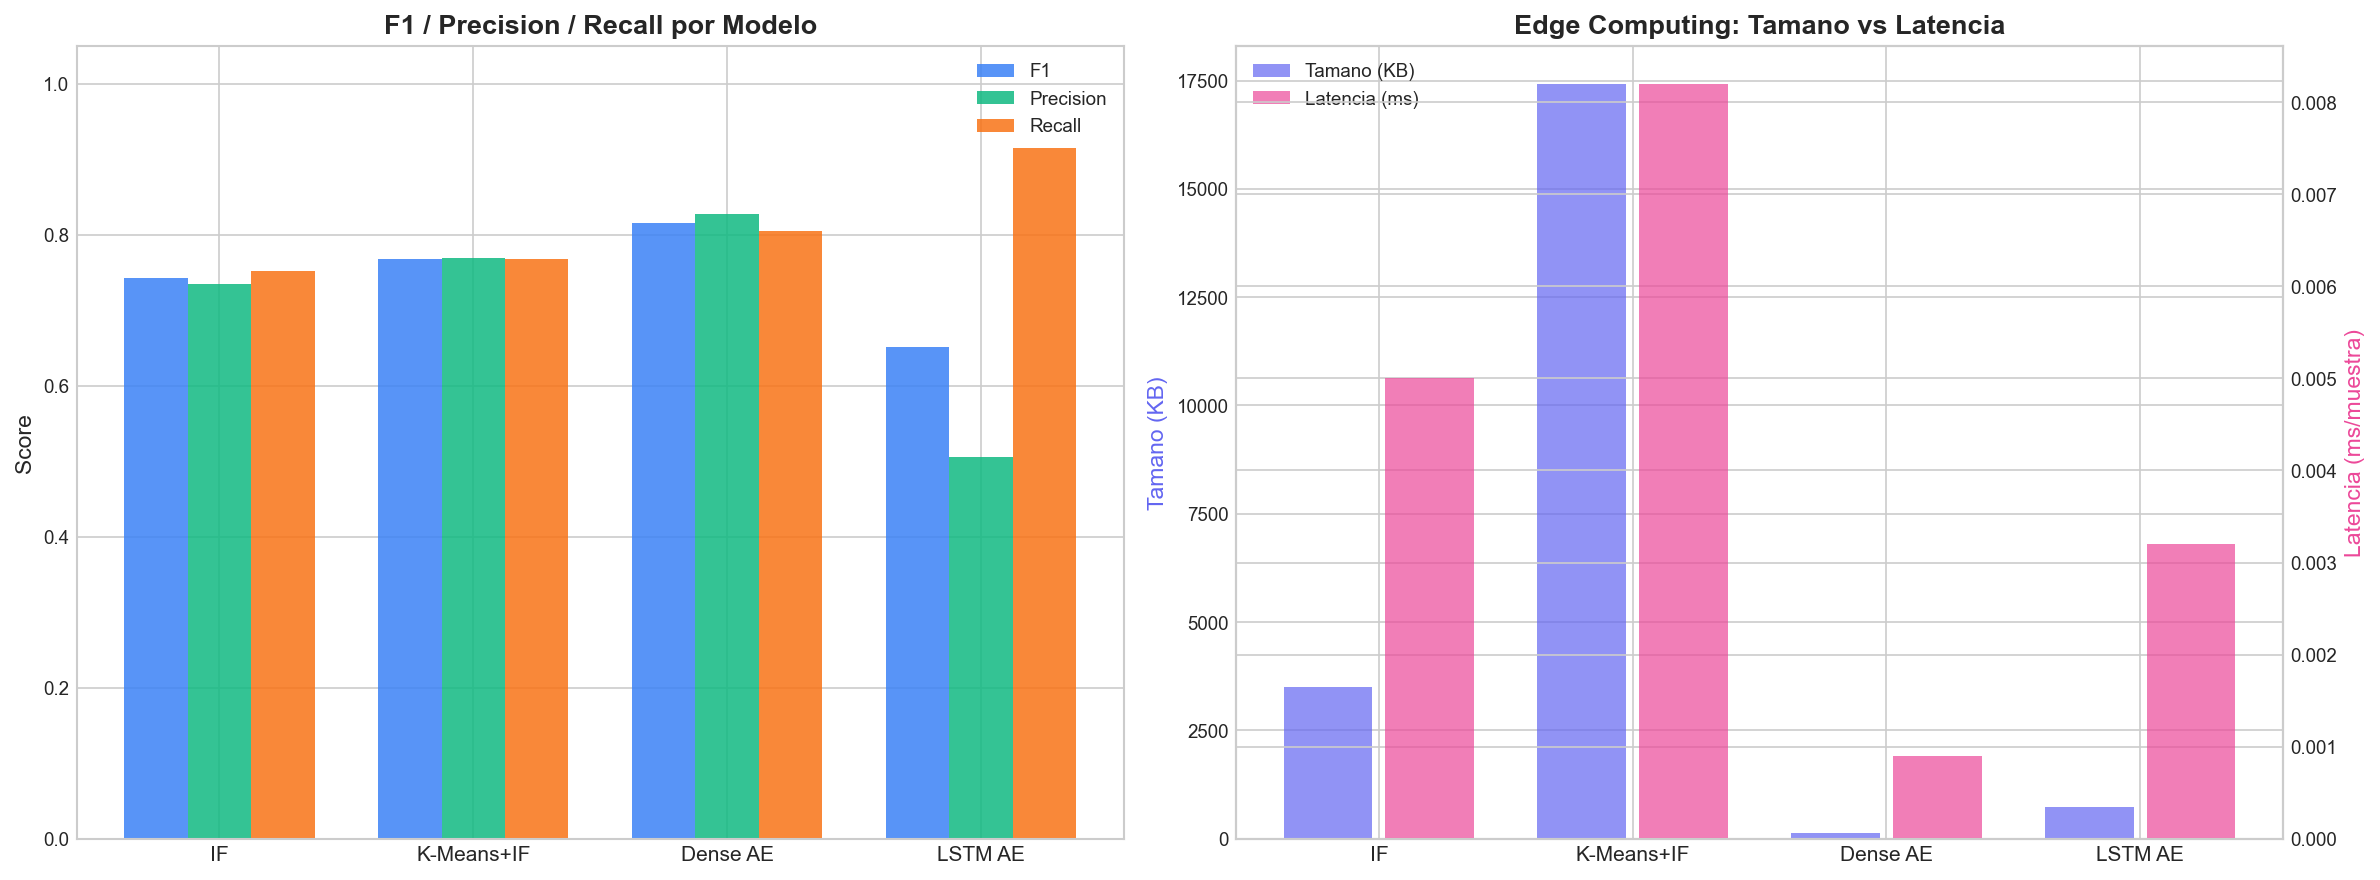

In [9]:
# ── Tabla comparativa ──

print('=' * 95)

print('TABLA COMPARATIVA -- 4 MODELOS DE DETECCION DE ANOMALIAS')

print('=' * 95)

print()

header = (f'  {"Modelo":15s} {"F1":>6s} {"F2":>6s} {"Prec":>6s} {"Rec":>6s} '

          f'{"AUC-ROC":>8s} {"AUC-PR":>7s} {"KB":>6s} {"ms":>7s} {"W,K":>5s}')

print(header)

print('  ' + '-' * 90)


rows = []

for name in ['IF', 'K-Means+IF', 'Dense AE', 'LSTM AE']:

    if name not in MODELS:

        continue

    m = MODELS[name]['metrics']

    row = {

        'Model': name,

        'F1': m['f1'], 'F2': m['f2'],

        'Precision': m['precision'], 'Recall': m['recall'],

        'AUC-ROC': m['auc_roc'], 'AUC-PR': m['auc_pr'],

        'Size_KB': m.get('model_size_kb', '?'),

        'ms': m.get('ms_per_sample', '?'),

        'W': m.get('temporal_W', '?'),

        'K': m.get('temporal_K', '?'),

    }

    rows.append(row)

    

    is_best = (m['f1'] == max(MODELS[n]['metrics']['f1'] for n in MODELS))

    marker = ' *' if is_best else ''

    

    print(f'  {name:15s} {m["f1"]:>6.4f} {m["f2"]:>6.4f} {m["precision"]:>6.4f} '

          f'{m["recall"]:>6.4f} {m["auc_roc"]:>8.4f} {m["auc_pr"]:>7.4f} '

          f'{m.get("model_size_kb", "?"):>6} {m.get("ms_per_sample", "?"):>7} '

          f'{m.get("temporal_W","?")},{m.get("temporal_K","?"):>3}{marker}')


print()

print('  * = mejor F1')


# ── Visualizacion radar/bar chart ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Bar chart: F1, Precision, Recall por modelo

model_names = [r['Model'] for r in rows]

x = np.arange(len(model_names))

w = 0.25


for i, (metric, color) in enumerate([

    ('F1', '#3B82F6'), ('Precision', '#10B981'), ('Recall', '#F97316')

]):

    vals = [r[metric] for r in rows]

    axes[0].bar(x + i*w, vals, w, label=metric, color=color, alpha=0.85)


axes[0].set_xticks(x + w)

axes[0].set_xticklabels(model_names, fontsize=10)

axes[0].set_ylim(0, 1.05)

axes[0].set_ylabel('Score')

axes[0].set_title('F1 / Precision / Recall por Modelo', fontweight='bold')

axes[0].legend()


# Bar chart: Edge metrics (size KB + ms/sample)

sizes = [r['Size_KB'] if isinstance(r['Size_KB'], (int, float)) else 0 for r in rows]

latencies = [r['ms'] if isinstance(r['ms'], (int, float)) else 0 for r in rows]


ax1 = axes[1]

ax2 = ax1.twinx()


b1 = ax1.bar(x - 0.2, sizes, 0.35, color='#6366F1', alpha=0.7, label='Tamano (KB)')

b2 = ax2.bar(x + 0.2, latencies, 0.35, color='#EC4899', alpha=0.7, label='Latencia (ms)')


ax1.set_xticks(x)

ax1.set_xticklabels(model_names, fontsize=10)

ax1.set_ylabel('Tamano (KB)', color='#6366F1')

ax2.set_ylabel('Latencia (ms/muestra)', color='#EC4899')

ax1.set_title('Edge Computing: Tamano vs Latencia', fontweight='bold')


lines1, labels1 = ax1.get_legend_handles_labels()

lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'comparison_4_models.png')

fig.savefig(save_path, dpi=300, bbox_inches='tight')

print(f'\nGuardado: {save_path}')

plt.show()

## 9. Resumen de Figuras Generadas


| Archivo | Contenido | Seccion TFG |

|---|---|---|

| `timeline_if.png` | Timeline completo IF | Cap. 4.1 |

| `timeline_k_means_if.png` | Timeline completo K-Means+IF | Cap. 4.2 |

| `timeline_dense_ae.png` | Timeline completo Dense AE | Cap. 4.3 |

| `timeline_lstm_ae.png` | Timeline completo LSTM AE | Cap. 4.4 |

| `timeline_zoom_*.png` | Zoom de 1 semana por modelo | Cap. 4.x |

| `episode_scaling.png` ... `episode_voltage_spoof.png` | Episodios individuales (7) | Cap. 3.3 |

| `episode_grid_7_types.png` | Grid compacto 7 tipos | Cap. 3.3 |

| `comparison_4_models.png` | Barras comparativas | Cap. 4.5 |


### Para exportar a LaTeX


```latex

\begin{figure}[H]

  \ffigbox[\FBwidth]{

    \caption[Timeline IF]{Vista temporal completa del Isolation Forest}

  }{

    \includegraphics[width=\textwidth]{imagenes/timeline_if.png}

  }

\end{figure}

```

In [10]:
# Lista de figuras generadas

print('Figuras generadas en', FIGURES_DIR + '/:')

for f in sorted(os.listdir(FIGURES_DIR)):

    size_kb = os.path.getsize(os.path.join(FIGURES_DIR, f)) / 1024

    print(f'  {f:45s} {size_kb:>7.1f} KB')

Figuras generadas en figures/:
  comparison_4_models.png                         177.2 KB
  episode_grid_7_types.png                       1655.2 KB
  episode_noise.png                               646.9 KB
  episode_offset.png                              467.8 KB
  episode_ramp.png                                425.9 KB
  episode_replay.png                              432.3 KB
  episode_scaling.png                             459.5 KB
  episode_step.png                                419.9 KB
  episode_voltage_spoof.png                       401.9 KB
  timeline_dense_ae.png                          1114.1 KB
  timeline_if.png                                1777.5 KB
  timeline_k-means_if.png                        1800.4 KB
  timeline_lstm_ae.png                           1667.3 KB
  timeline_zoom_dense_ae.png                      763.0 KB
  timeline_zoom_if.png                           1162.6 KB
  timeline_zoom_k-means_if.png                   1165.7 KB
  timeline_zoom_lstm_ae.p